In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

## Loading the dataset

In [2]:
df = pd.read_csv('/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_fe.csv')

/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_37795/1617179408.py:1: DtypeWarning: Columns (0: MAIL_ZIP_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_fe.csv')


In [3]:
# ── Exact duplicates across ALL columns ──────────────────────────────
dup_mask = df.duplicated(keep=False)   # marks every copy, not just 2nd+
n_dup_rows  = dup_mask.sum()
n_groups    = df[dup_mask].groupby(df.columns.tolist()).ngroups

print(f"Total rows:              {len(df):,}")
print(f"Exact duplicate rows:    {n_dup_rows:,}  ({100*n_dup_rows/len(df):.2f}%)")
print(f"Unique duplicate groups: {n_groups:,}")
print(f"Rows to drop (1 per group kept): {n_dup_rows - n_groups:,}")

# View the duplicates
exact_dupes = df[dup_mask].sort_values(by=df.columns.tolist())
print("\nSample:")
print(exact_dupes.head(20).to_string())

# Drop — keep first occurrence of each duplicate group
df_clean = df.drop_duplicates(keep='first').reset_index(drop=True)
print(f"\nShape before: {df.shape}")
print(f"Shape after:  {df_clean.shape}")

Total rows:              167,731
Exact duplicate rows:    9,132  (5.44%)
Unique duplicate groups: 2,084
Rows to drop (1 per group kept): 7,048

Sample:
           CITY  LUC             BLDG_TYPE MAIL_CITY MAIL_ZIP_CODE  RES_FLOOR   LAND_SF  GROSS_AREA  LIVING_AREA  TOTAL_VALUE ROOF_STRUCTURE       ROOF_COVER            INT_WALL      EXT_FNISHED  INT_COND  EXT_COND  OVERALL_COND  BED_RMS  TT_RMS  BDRM_COND  BTHRM_STYLE1  BTHRM_STYLE2  BTHRM_STYLE3     KITCHEN_TYPE  KITCHEN_STYLE1  KITCHEN_STYLE2  KITCHEN_STYLE3           HEAT_TYPE         HEAT_SYSTEM         AC_TYPE  FIREPLACES        ORIENTATION  NUM_PARKING  PROP_VIEW        CORNER_UNIT  IS_RES  YEARS_SINCE_REMODEL                ST_ZIP
153200  ALLSTON   13  112 - APT 7-30 UNITS   ALLSTON         02134       -1.0  8.156223    9.317040     9.317040      1059914      O - Other        O - Other  NA - Not Available       01 - Brick         2         2             5      0.0     0.0          2             1             1             1     

In [4]:
before = len(df)
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} exact duplicate rows")
print(f"Remaining rows: {len(df)}")

Dropped 7048 exact duplicate rows
Remaining rows: 160683


## Feature distribution visualization

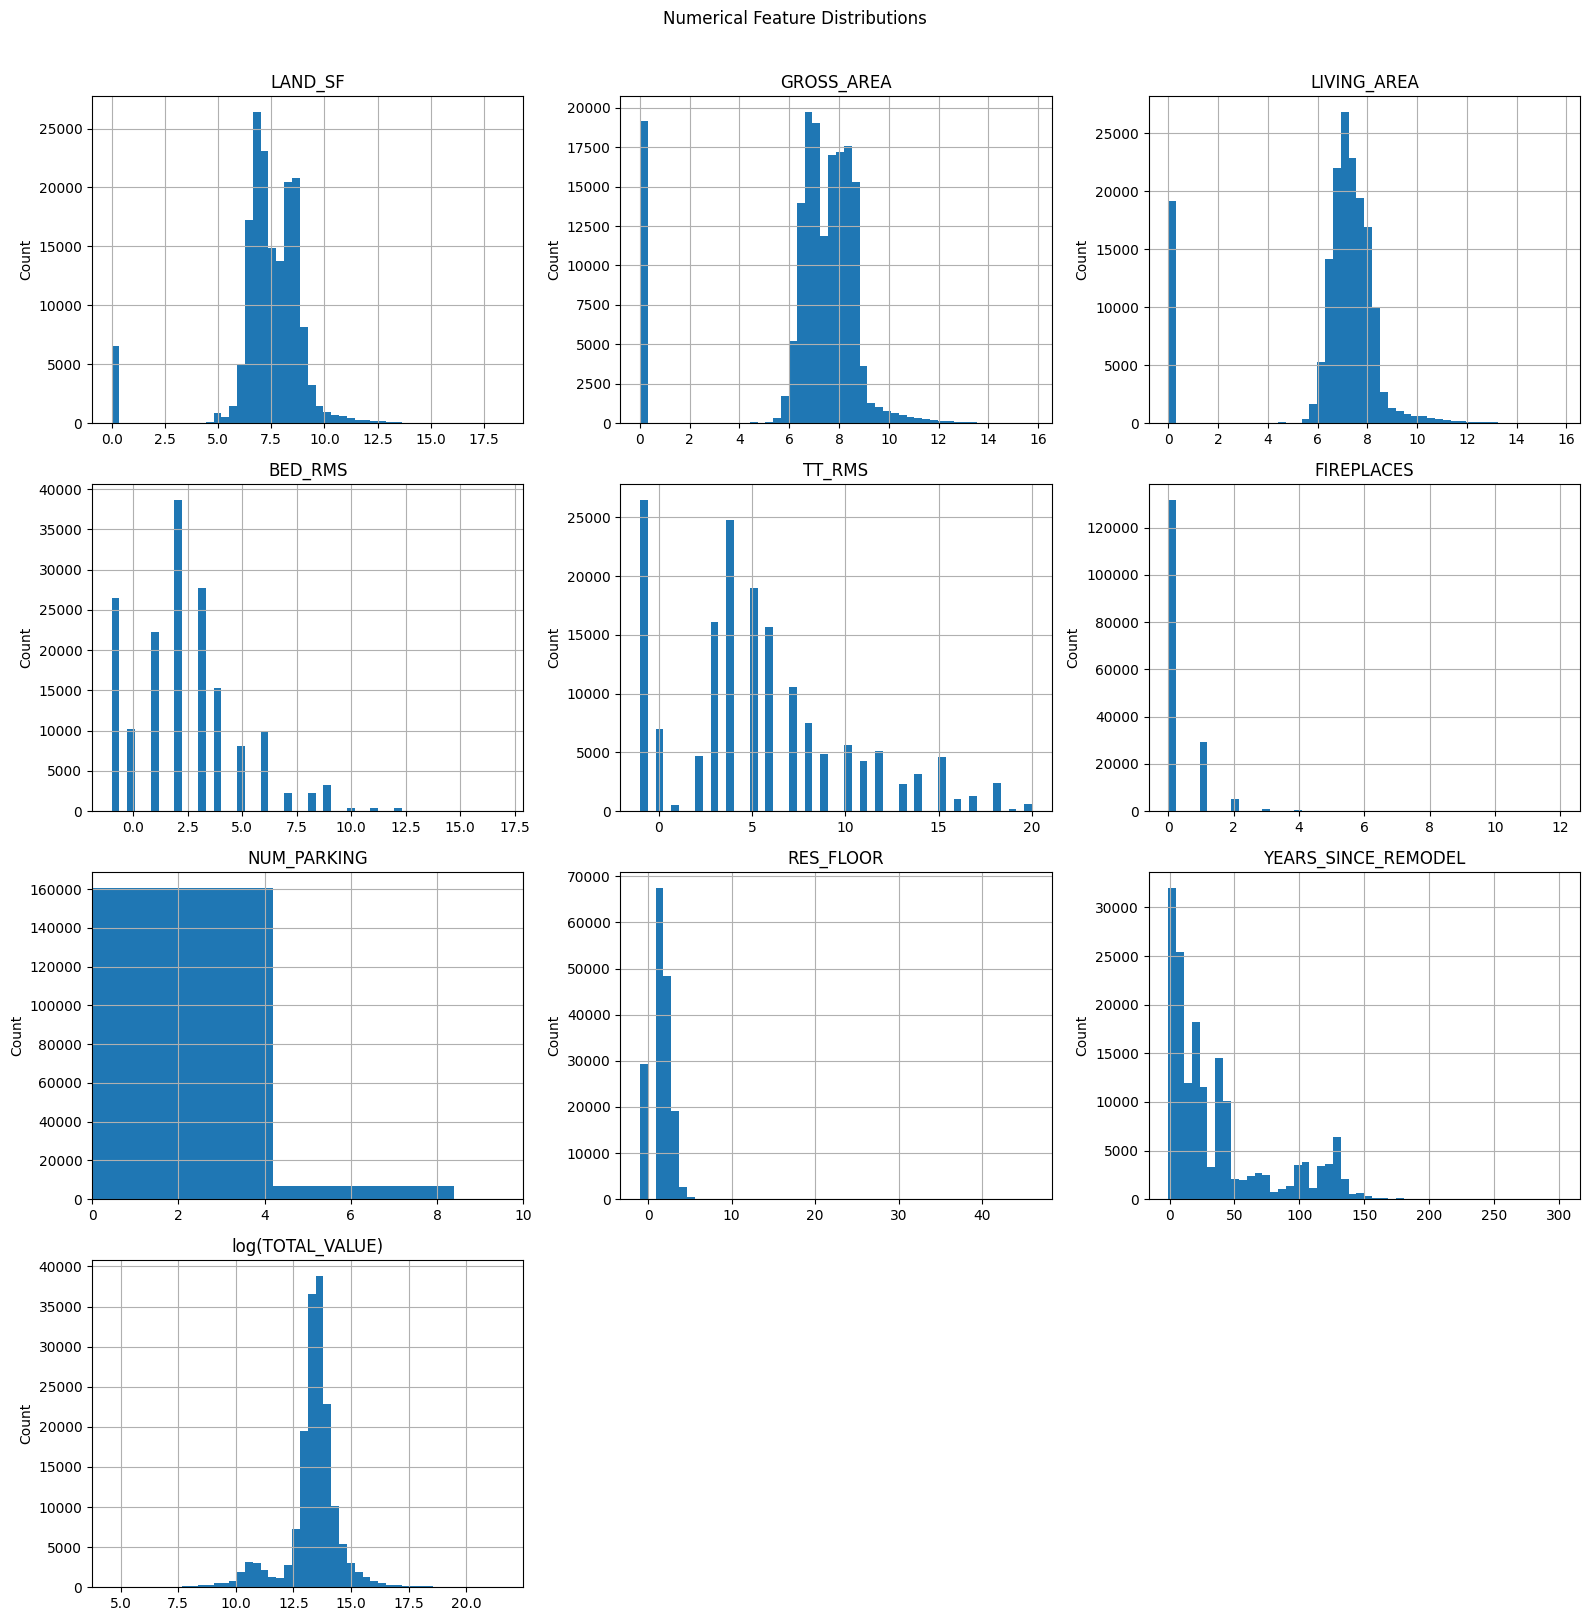

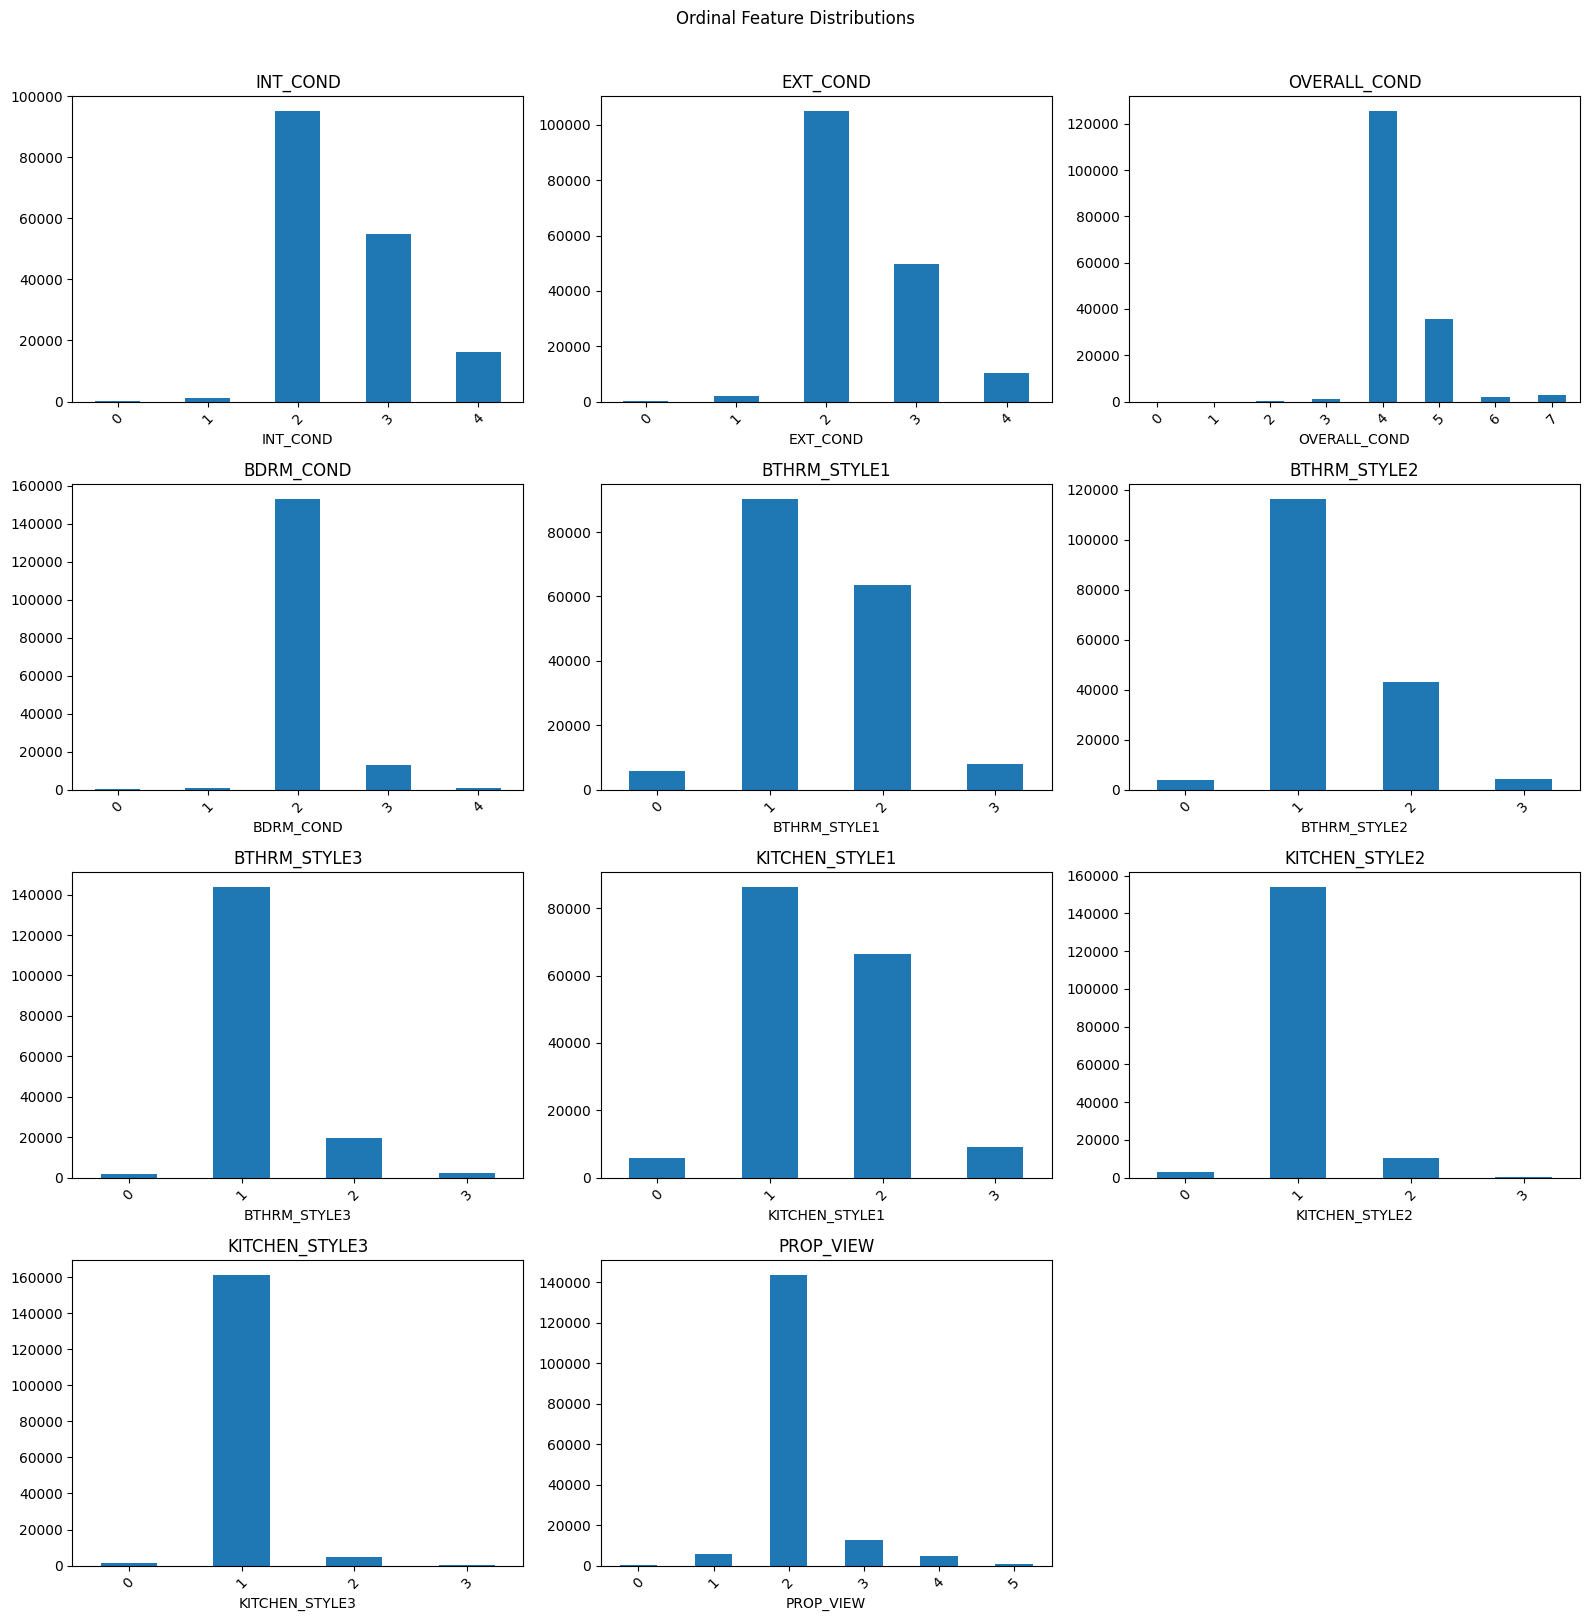

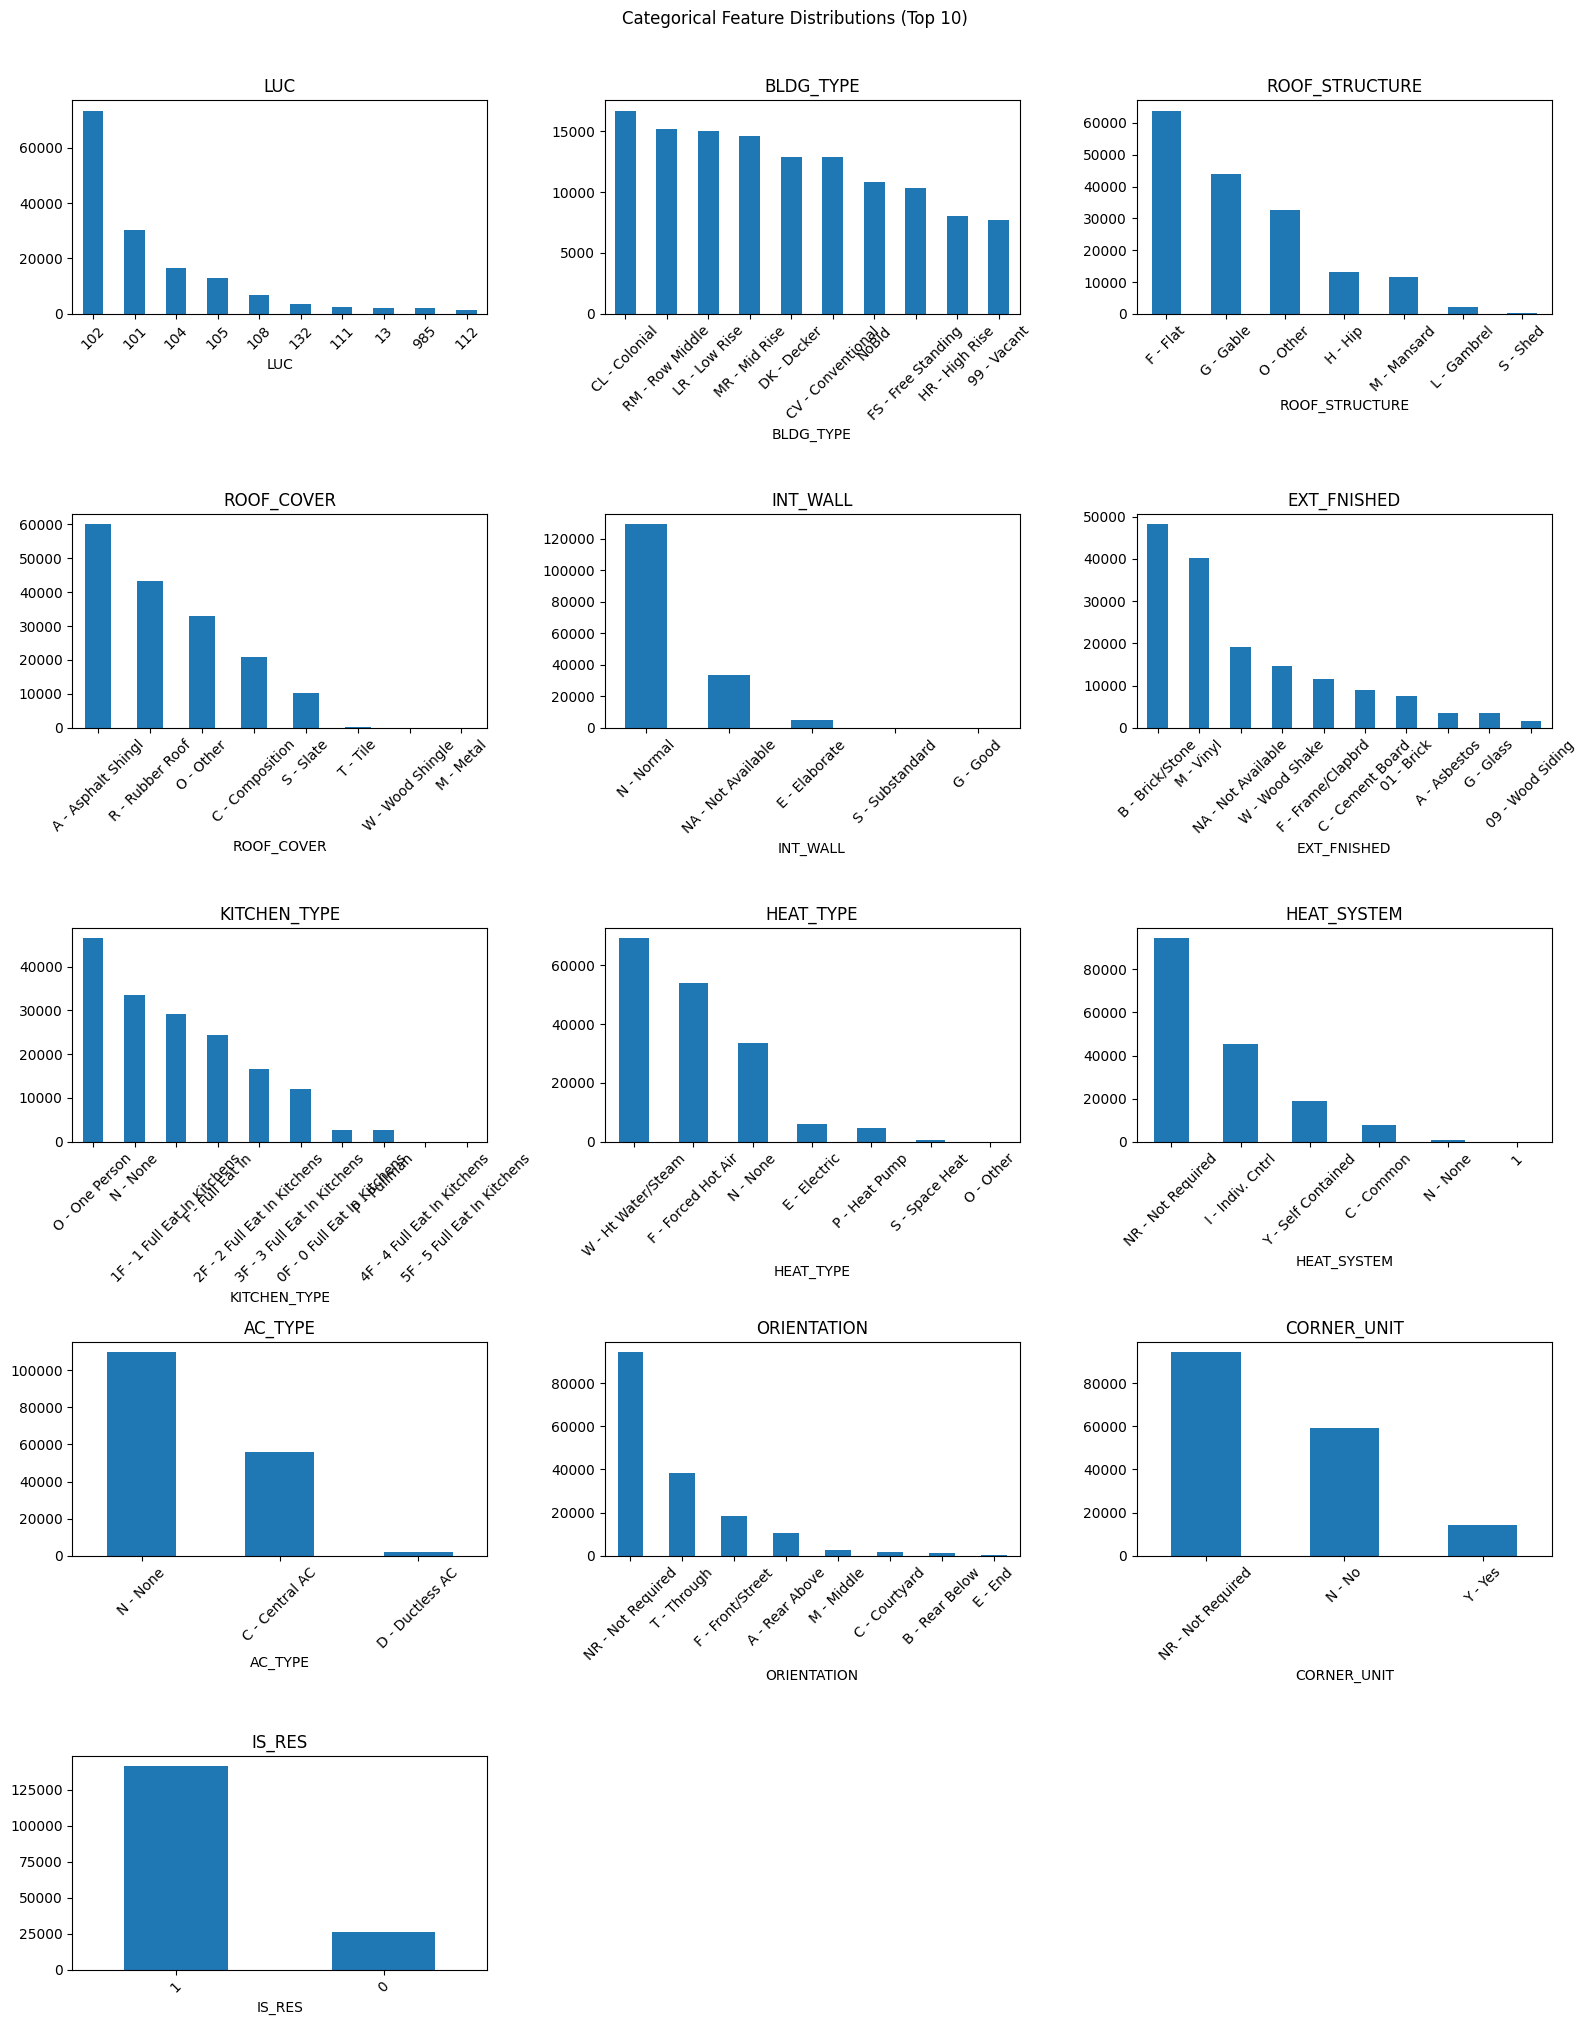

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_fe.csv', low_memory=False)

numerical_cols = ['LAND_SF', 'GROSS_AREA', 'LIVING_AREA', 'BED_RMS', 'TT_RMS', 
                  'FIREPLACES', 'NUM_PARKING', 'RES_FLOOR', 'YEARS_SINCE_REMODEL', 'TOTAL_VALUE']

categorical_cols = ['LUC', 'BLDG_TYPE', 'ROOF_STRUCTURE', 'ROOF_COVER', 'INT_WALL',
                    'EXT_FNISHED', 'KITCHEN_TYPE', 'HEAT_TYPE', 'HEAT_SYSTEM', 
                    'AC_TYPE', 'ORIENTATION', 'CORNER_UNIT', 'IS_RES']

ordinal_cols = ['INT_COND', 'EXT_COND', 'OVERALL_COND', 'BDRM_COND',
                'BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3',
                'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3', 'PROP_VIEW']

# Numerical — histogram
xlim_map = {'NUM_PARKING': 10}

n = len(numerical_cols)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(16, (n+2)//3 * 4))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    data = np.log1p(df[col].dropna()) if col == 'TOTAL_VALUE' else df[col].dropna()
    data.hist(ax=axes[i], bins=50, edgecolor='none')
    axes[i].set_title(f'log({col})' if col == 'TOTAL_VALUE' else col)
    axes[i].set_ylabel('Count')
    if col in xlim_map:
        axes[i].set_xlim(0, xlim_map[col])
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numerical Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

# Ordinal — bar chart
n = len(ordinal_cols)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(16, (n+2)//3 * 4))
axes = axes.flatten()
for i, col in enumerate(ordinal_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Ordinal Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

# Categorical — top 10 values (some have 100s of categories)
n = len(categorical_cols)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(16, (n+2)//3 * 4))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Categorical Feature Distributions (Top 10)', y=1.01)
plt.tight_layout()
plt.show()

## Numerical features

### Numerical feature plots -

1. Area feataures - We see high distribution for 0 area values in log scale due to clipping values at 0
2. Room features - clean, some values are -1 which represent NaN
3. Other - Clean
4. Log(TOTAL_VALUE) - Normal distribution

### Fixing zero living area, and outliers accounting for like extremely luxury penthouses and impossibly cheap houses

We have to check values with zero living area

In [6]:
print((df['LIVING_AREA'] == 0).sum(), "properties with LIVING_AREA = 0")
print(df[df['LIVING_AREA'] == 0]['BLDG_TYPE'].value_counts().head())

19191 properties with LIVING_AREA = 0
BLDG_TYPE
NoBld             9731
99 - Vacant       7707
MR - Mid Rise      514
LR - Low Rise      304
HR - High Rise     181
Name: count, dtype: int64


Suspicious zeros (~999 rows, 5%):

MR - Mid Rise (514), LR - Low Rise (304), HR - High Rise (181)
A high-rise with 0 living area is almost certainly missing data, not reality. These are likely encoding gaps where the feature wasn't recorded for that property

We can use other area features - GROSS_AREA and LAND_SF to impute LIVING AREA for these suspicious values

In [7]:
# Define the suspicious subset
rise_types = ['MR - Mid Rise', 'LR - Low Rise', 'HR - High Rise']
suspicious_mask = (df['LIVING_AREA'] == 0) & df['BLDG_TYPE'].isin(rise_types)
print(f"Rows to impute: {suspicious_mask.sum()}")

# Reference set: same rise types with valid LIVING_AREA
reference = df[
    df['BLDG_TYPE'].isin(rise_types) &
    (df['LIVING_AREA'] > 0) &
    (df['GROSS_AREA'] > 0)
]

# --- Step 1: Compute ratios per BLDG_TYPE (not global — rise types differ) ---
ratios = (
    reference.groupby('BLDG_TYPE')
    .apply(lambda g: (g['LIVING_AREA'] / g['GROSS_AREA']).median())
)
print("\nLIVING_AREA / GROSS_AREA ratios by type:")
print(ratios)

# Sanity check: ratios should be < 1 and in a reasonable range (typ. 0.7–0.95)

Rows to impute: 999

LIVING_AREA / GROSS_AREA ratios by type:
BLDG_TYPE
HR - High Rise    1.0
LR - Low Rise     1.0
MR - Mid Rise     1.0
dtype: float64


In [8]:
suspicious = df[suspicious_mask]
print("Area features for ~999 suspicious rows:")
print(suspicious[['LIVING_AREA', 'GROSS_AREA', 'LAND_SF']].describe())
print(f"\nAll three == 0: {((suspicious[['LIVING_AREA','GROSS_AREA','LAND_SF']] == 0).all(axis=1)).sum()}")
print(f"At least one > 0: {((suspicious[['LIVING_AREA','GROSS_AREA','LAND_SF']] > 0).any(axis=1)).sum()}")

Area features for ~999 suspicious rows:
       LIVING_AREA  GROSS_AREA     LAND_SF
count        999.0  999.000000  999.000000
mean           0.0    0.009239    0.116105
std            0.0    0.206394    1.031308
min            0.0    0.000000    0.000000
25%            0.0    0.000000    0.000000
50%            0.0    0.000000    0.000000
75%            0.0    0.000000    0.000000
max            0.0    4.615121   12.253018

All three == 0: 986
At least one > 0: 13


LIVING_AREA (log scale) — summary by rise type:

                  count   mean    std    min     5%    25%    50%    75%  \
BLDG_TYPE                                                                  
HR - High Rise   7845.0  7.042  0.528  4.615  6.303  6.680  7.047  7.361   
LR - Low Rise   14732.0  6.713  0.389  4.511  6.071  6.479  6.680  6.961   
MR - Mid Rise   14106.0  6.811  0.520  4.615  6.016  6.503  6.800  7.081   

                  95%     max  
BLDG_TYPE                      
HR - High Rise  7.888  13.784  
LR - Low Rise   7.358  10.705  
MR - Mid Rise   7.589  12.635  

Median in raw sqft (exp of log median):
BLDG_TYPE
HR - High Rise    1149.0
LR - Low Rise      796.0
MR - Mid Rise      898.0
Name: LIVING_AREA, dtype: float64


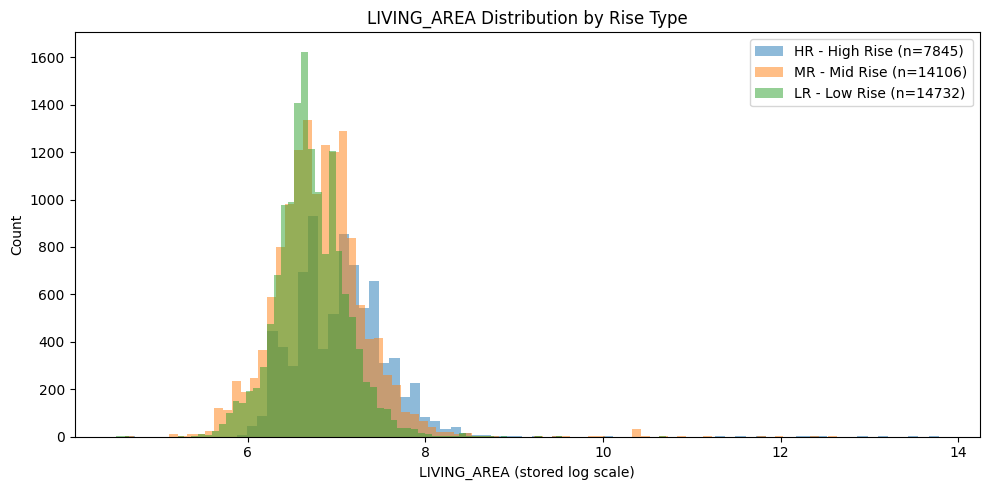

/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_37795/3883624022.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_box, labels=rise_types, showfliers=True)


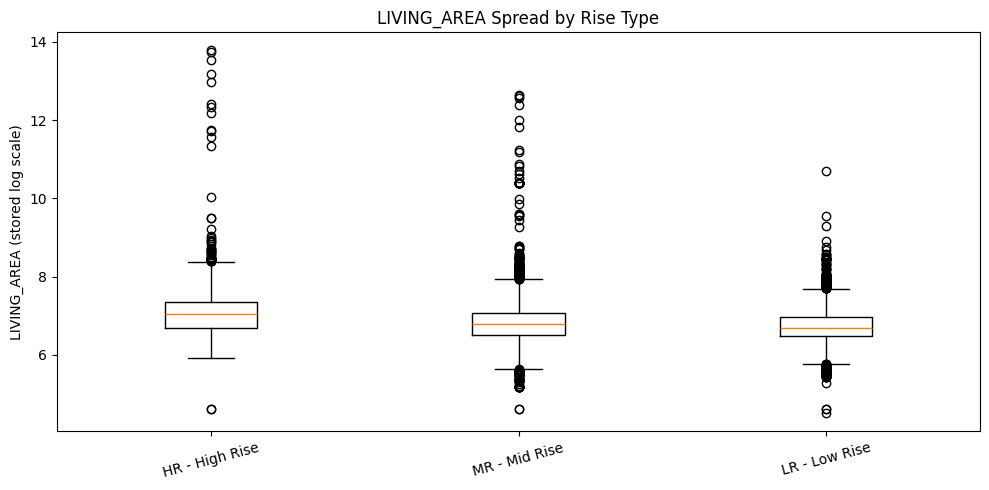

In [9]:
rise_types = ['HR - High Rise', 'MR - Mid Rise', 'LR - Low Rise']
reference_rise = df[df['BLDG_TYPE'].isin(rise_types) & (df['LIVING_AREA'] > 0)]

# --- Summary stats on log scale (as stored) + raw-sqft interpretation ---
print("LIVING_AREA (log scale) — summary by rise type:\n")
summary = reference_rise.groupby('BLDG_TYPE')['LIVING_AREA'].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
)
print(summary.round(3))

print("\nMedian in raw sqft (exp of log median):")
print(np.exp(reference_rise.groupby('BLDG_TYPE')['LIVING_AREA'].median()).round(0))

# --- Histogram on stored (log) scale, no further transform ---
fig, ax = plt.subplots(figsize=(10, 5))
for t in rise_types:
    data = reference_rise.loc[reference_rise['BLDG_TYPE'] == t, 'LIVING_AREA']
    ax.hist(data, bins=80, alpha=0.5, label=f"{t} (n={len(data)})")
ax.set_xlabel('LIVING_AREA (stored log scale)')
ax.set_ylabel('Count')
ax.set_title('LIVING_AREA Distribution by Rise Type')
ax.legend()
plt.tight_layout()
plt.show()

# --- Boxplot on stored (log) scale ---
fig, ax = plt.subplots(figsize=(10, 5))
data_for_box = [
    reference_rise.loc[reference_rise['BLDG_TYPE'] == t, 'LIVING_AREA']
    for t in rise_types
]
ax.boxplot(data_for_box, labels=rise_types, showfliers=True)
ax.set_ylabel('LIVING_AREA (stored log scale)')
ax.set_title('LIVING_AREA Spread by Rise Type')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [10]:
# Upper outlier check (anything > log 10 ≈ 22,000 sqft looks building-level)
upper = df[(df['LIVING_AREA'] > 10) & df['BLDG_TYPE'].isin(rise_types)]
print(f"Upper outliers (>log 10): {len(upper)}")
print(upper[['BLDG_TYPE', 'LIVING_AREA', 'GROSS_AREA', 'LAND_SF']].describe())

# Lower outlier check
lower = df[(df['LIVING_AREA'] < 5) & (df['LIVING_AREA'] > 0) & df['BLDG_TYPE'].isin(rise_types)]
print(f"\nLower outliers (<log 5): {len(lower)}")

Upper outliers (>log 10): 58
       LIVING_AREA  GROSS_AREA    LAND_SF
count    58.000000   58.000000  58.000000
mean     11.092316   11.194277   5.537324
std       1.034365    0.974853   6.028326
min      10.028224   10.028224   0.000000
25%      10.390993   10.573289   0.000000
50%      10.390993   10.573289   0.000000
75%      11.740517   11.740517  11.720187
max      13.783551   13.783551  13.960265

Lower outliers (<log 5): 7


In [11]:
suspicious_upper = df[
    df['BLDG_TYPE'].isin(rise_types) &
    (df['LIVING_AREA'] > 10)
][['LIVING_AREA', 'GROSS_AREA', 'LAND_SF', 'TOTAL_VALUE', 'BLDG_TYPE']]

# Price per sqft on the original scale (back-transform both)
suspicious_upper['sqft'] = np.exp(suspicious_upper['LIVING_AREA'])
# Adjust this back-transform depending on how TOTAL_VALUE is stored
suspicious_upper['value_per_sqft'] = (
    np.exp(suspicious_upper['TOTAL_VALUE']) / suspicious_upper['sqft']
    if suspicious_upper['TOTAL_VALUE'].max() < 30
    else suspicious_upper['TOTAL_VALUE'] / suspicious_upper['sqft']
)

print(suspicious_upper.sort_values('LIVING_AREA'))

        LIVING_AREA  GROSS_AREA    LAND_SF  TOTAL_VALUE       BLDG_TYPE  \
151122    10.028224   10.028224  10.028224      7714000  HR - High Rise   
54965     10.390993   10.573289   0.000000        43000   MR - Mid Rise   
54960     10.390993   10.573289   0.000000        43000   MR - Mid Rise   
54961     10.390993   10.573289   0.000000        43000   MR - Mid Rise   
54962     10.390993   10.573289   0.000000        43000   MR - Mid Rise   
54963     10.390993   10.573289   0.000000        43000   MR - Mid Rise   
54964     10.390993   10.573289   0.000000        43000   MR - Mid Rise   
54966     10.390993   10.573289   0.000000        43000   MR - Mid Rise   
54967     10.390993   10.573289   0.000000        90000   MR - Mid Rise   
54968     10.390993   10.573289   0.000000        43000   MR - Mid Rise   
54969     10.390993   10.573289   0.000000        43000   MR - Mid Rise   
54970     10.390993   10.573289   0.000000        43000   MR - Mid Rise   
54971     10.390993   10.

TOTAL_VALUE range: 1000 – 2448193300

Value per sqft — distribution:
count    1.485400e+05
mean     6.611873e+02
std      9.210558e+03
min      8.761437e-03
0.1%     3.305493e+01
1%       9.644587e+01
5%       1.928706e+02
50%      5.021281e+02
95%      1.245975e+03
99%      1.822686e+03
99.9%    3.207878e+03
max      2.092879e+06
Name: value_per_sqft, dtype: float64


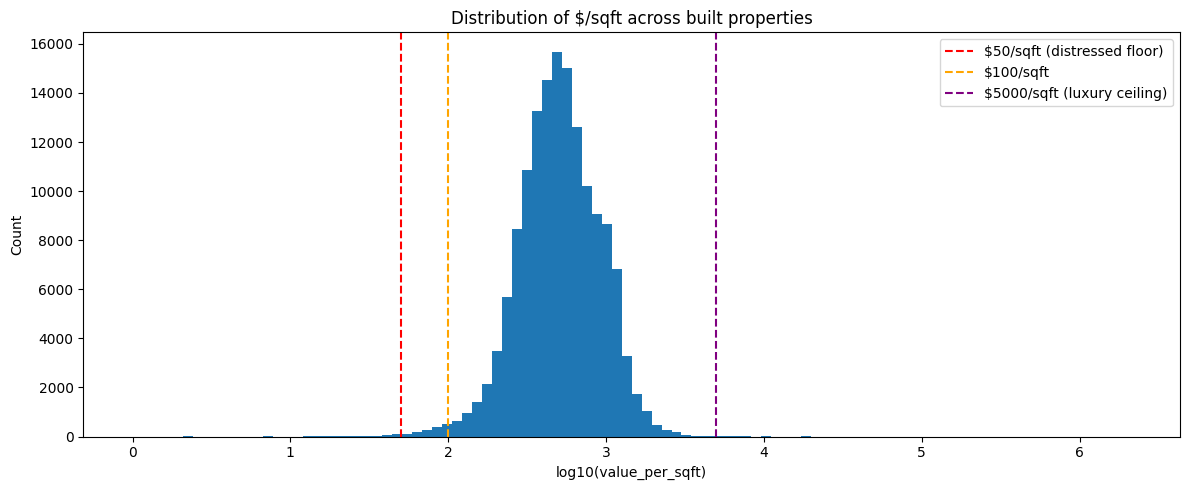

In [12]:
# Only analyze rows where both fields are meaningful
built_mask = (df['LIVING_AREA'] > 0) & (df['TOTAL_VALUE'] > 0)
built = df.loc[built_mask].copy()

# Back-transform LIVING_AREA from log to raw sqft
built['sqft'] = np.exp(built['LIVING_AREA'])

# Compute $/sqft — assuming TOTAL_VALUE is in raw dollars (not log)
# Verify: if max TOTAL_VALUE is in millions range, it's raw; if it's under ~30, it's log
print(f"TOTAL_VALUE range: {built['TOTAL_VALUE'].min()} – {built['TOTAL_VALUE'].max()}")

built['value_per_sqft'] = built['TOTAL_VALUE'] / built['sqft']

# --- Distribution of $/sqft ---
print(f"\nValue per sqft — distribution:")
print(built['value_per_sqft'].describe(percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))

# Histogram (log x since it spans orders of magnitude)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(np.log10(built['value_per_sqft'] + 1), bins=100)
ax.set_xlabel('log10(value_per_sqft)')
ax.set_ylabel('Count')
ax.axvline(np.log10(50),   color='red',    linestyle='--', label='$50/sqft (distressed floor)')
ax.axvline(np.log10(100),  color='orange', linestyle='--', label='$100/sqft')
ax.axvline(np.log10(5000), color='purple', linestyle='--', label='$5000/sqft (luxury ceiling)')
ax.set_title('Distribution of $/sqft across built properties')
ax.legend()
plt.tight_layout()
plt.show()

Both lower and higher tail in $/sqft plot have suspicious outliers, less than $50/sqft in Boston is very suspicious, while more than $5k per sqft is likely in Boston but still worth inspecting

In [13]:
# Left tail — suspicious low $/sqft
tails = {
    'Very low (<$10)':     (built['value_per_sqft'] < 10),
    'Low ($10-50)':        (built['value_per_sqft'] >= 10)    & (built['value_per_sqft'] < 50),
    'Grey ($50-100)':      (built['value_per_sqft'] >= 50)    & (built['value_per_sqft'] < 100),
    'Normal ($100-5000)':  (built['value_per_sqft'] >= 100)   & (built['value_per_sqft'] < 5000),
    'High ($5000-10000)':  (built['value_per_sqft'] >= 5000)  & (built['value_per_sqft'] < 10000),
    'Very high (>$10000)': (built['value_per_sqft'] >= 10000),
}
for label, mask in tails.items():
    print(f"{label}: {mask.sum():>6} rows ({100*mask.sum()/len(built):.2f}%)")

Very low (<$10):     44 rows (0.03%)
Low ($10-50):    285 rows (0.19%)
Grey ($50-100):   1278 rows (0.86%)
Normal ($100-5000): 146868 rows (98.87%)
High ($5000-10000):     22 rows (0.01%)
Very high (>$10000):     43 rows (0.03%)


Drop false recordings

- 44 rows under $10/sqft — impossible for any real property
- 43 rows over $10,000/sqft — impossible for any real property (Boston tops out ~$5K/sqft)

In [14]:
drop_mask = (built['value_per_sqft'] < 10) | (built['value_per_sqft'] > 10000)
drop_ids = built.loc[drop_mask].index

df = df.drop(drop_ids).reset_index(drop=True)
print(f"Dropped {drop_mask.sum()} rows with absurd $/sqft")
print(f"New shape: {df.shape}")

Dropped 87 rows with absurd $/sqft
New shape: (167644, 38)


In [15]:
# Low $10-50 — mostly corrupted but might include exempt/subsidized properties
low = built[(built['value_per_sqft'] >= 10) & (built['value_per_sqft'] < 50)]
print("--- Low $10-50 (285 rows) ---")
print("\nBy BLDG_TYPE:")
print(low['BLDG_TYPE'].value_counts())
print("\nBy LUC (land use code):")
print(low['LUC'].value_counts().head(10))

# High $5000-10000 — possible ultra-luxury or possible errors
high = built[(built['value_per_sqft'] >= 5000) & (built['value_per_sqft'] < 10000)]
print("\n--- High $5000-10000 (22 rows) ---")
print("\nBy BLDG_TYPE:")
print(high['BLDG_TYPE'].value_counts())
print("\nSample rows:")
print(high[['BLDG_TYPE','LIVING_AREA','sqft','TOTAL_VALUE','value_per_sqft']])

--- Low $10-50 (285 rows) ---

By BLDG_TYPE:
BLDG_TYPE
125 - SUBSD HOUSING S- 8          64
112 - APT 7-30 UNITS              27
316 - WAREHOUSE /Distrib          18
317 - STORAGE WHSE (old)          15
114 - APT 100+ UNITS              13
                                  ..
335 - CAR WASH                     1
TF - Two Fam Stack                 1
307 - VETERINARY HOSPITAL          1
324 - SUPERMARKET                  1
959 - ASSISTED LIVING/ Elderly     1
Name: count, Length: 66, dtype: int64

By LUC (land use code):
LUC
125    49
13     47
907    37
317    21
316    11
985     6
112     6
343     6
336     5
31      5
Name: count, dtype: int64

--- High $5000-10000 (22 rows) ---

By BLDG_TYPE:
BLDG_TYPE
FS - Free Standing             7
111 - APT 4-6 UNITS            2
384 - BOAT HOUSE /MARINA       1
397 - BUS /RR TERMINAL         1
319 - STRIP RETAIL/ OFFICE     1
402 - OFFICE: INDUSTRIAL       1
152 - APT 2BR units            1
334 - SERVICE Center/Retail    1
MR - Mid Rise       

These look legitmate - subsidized housing is legally assessed lower (tax abatements, rent restrictions), older multi-unit rentals, often distressed, warehouses run $20–80/sqft — much cheaper than residential

In [16]:
rise_types = ['HR - High Rise', 'MR - Mid Rise', 'LR - Low Rise']
remaining_rise_outliers = df[
    df['BLDG_TYPE'].isin(rise_types) &
    (df['LIVING_AREA'] > 10)
]
print(f"Remaining rise outliers after $/sqft drop: {len(remaining_rise_outliers)}")
print(remaining_rise_outliers[
    ['BLDG_TYPE', 'LIVING_AREA', 'GROSS_AREA', 'TOTAL_VALUE']
].head(20))

# Compute $/sqft for these residual rows
remaining_rise_outliers = remaining_rise_outliers.copy()
remaining_rise_outliers['sqft'] = np.exp(remaining_rise_outliers['LIVING_AREA'])
remaining_rise_outliers['value_per_sqft'] = (
    remaining_rise_outliers['TOTAL_VALUE'] / remaining_rise_outliers['sqft']
)
print(remaining_rise_outliers['value_per_sqft'].describe())

Remaining rise outliers after $/sqft drop: 27
            BLDG_TYPE  LIVING_AREA  GROSS_AREA  TOTAL_VALUE
12988   MR - Mid Rise    12.011729   12.131807     16177300
12989   MR - Mid Rise    12.376528   12.494311     19153500
17641   MR - Mid Rise    11.229235   11.229235     12919300
20703  HR - High Rise    13.755118   13.779810    487473800
28753  HR - High Rise    12.186365   12.186365     99866300
28754  HR - High Rise    11.745449   11.745449      7203800
34983  HR - High Rise    13.527963   13.527963    265271800
34984  HR - High Rise    12.420785   12.420785     45510700
57563  HR - High Rise    13.783551   13.783551    411409900
57566  HR - High Rise    11.725720   11.725720     47729200
57567  HR - High Rise    11.341211   11.341211     12035100
58022  HR - High Rise    12.965646   12.965646    280970500
58023  HR - High Rise    11.570770   11.570770     20888700
59492  HR - High Rise    13.178273   13.178273    392318600
63868   LR - Low Rise    10.704727   10.704727     137

### Rise-Building Area Outliers (Log LIVING_AREA > 10)

After the `$/sqft` filter removed obvious corruption, 27 rows remain with extreme
LIVING_AREA values. Cross-referencing TOTAL_VALUE with area shows these are
**legitimate building-level records** mixed into a unit-level dataset, not data
errors — the $/sqft figures are consistent with whole-building valuations rather
than unit-level condo prices.

| Row     | BLDG_TYPE      | LIVING_AREA (log) | GROSS_AREA (log) | Raw sqft | TOTAL_VALUE      | $/sqft  |
|---------|----------------|-------------------|------------------|----------|------------------|---------|
| 12988   | MR - Mid Rise  | 12.01             | 12.13            | 163,869  | $16,177,300      | $99     |
| 12989   | MR - Mid Rise  | 12.38             | 12.49            | 236,200  | $19,153,500      | $81     |
| 17641   | MR - Mid Rise  | 11.23             | 11.23            | 75,346   | $12,919,300      | $171    |
| 20703   | HR - High Rise | 13.76             | 13.78            | 941,192  | $487,473,800     | $518    |
| 28753   | HR - High Rise | 12.19             | 12.19            | 195,920  | $99,866,300      | $510    |
| 28754   | HR - High Rise | 11.75             | 11.75            | 126,090  | $7,203,800       | $57     |
| 34983   | HR - High Rise | 13.53             | 13.53            | 751,000  | $265,271,800     | $353    |
| 34984   | HR - High Rise | 12.42             | 12.42            | 248,012  | $45,510,700      | $184    |
| 57563   | HR - High Rise | 13.78             | 13.78            | 970,146  | $411,409,900     | $424    |
| 57566   | HR - High Rise | 11.73             | 11.73            | 123,624  | $47,729,200      | $386    |
| 57567   | HR - High Rise | 11.34             | 11.34            | 83,953   | $12,035,100      | $143    |
| 58022   | HR - High Rise | 12.97             | 12.97            | 429,310  | $280,970,500     | $654    |
| 58023   | HR - High Rise | 11.57             | 11.57            | 105,898  | $20,888,700      | $197    |
| 59492   | HR - High Rise | 13.18             | 13.18            | 529,879  | $392,318,600     | $740    |
| 63868   | LR - Low Rise  | 10.70             | 10.70            | 44,394   | $13,764,700      | $310    |
| 68406   | MR - Mid Rise  | 12.63             | 12.63            | 306,700  | $120,842,500     | $394    |
| 68444   | MR - Mid Rise  | 12.61             | 12.61            | 298,858  | $78,930,200      | $264    |
| 70741   | MR - Mid Rise  | 11.82             | 11.82            | 136,525  | $51,448,700      | $377    |
| 74691   | MR - Mid Rise  | 10.63             | 10.63            | 41,393   | $18,513,000      | $447    |
| 74991   | MR - Mid Rise  | 11.18             | 11.18            | 71,768   | $11,269,585      | $157    |

**Interpretation:** All 27 rows show $/sqft in the $50–750 range — sensible for
entire buildings but wrong for individual units. They survived the `$/sqft < $10`
filter precisely because total value and total area scale together at the building
level

In [17]:
# Pull all feature columns for the 27 suspicious rows
rise_types = ['HR - High Rise', 'MR - Mid Rise', 'LR - Low Rise']
suspicious = df[
    df['BLDG_TYPE'].isin(rise_types) &
    (df['LIVING_AREA'] > 10)
].copy()

# Compute $/sqft for the table
suspicious['sqft'] = np.exp(suspicious['LIVING_AREA'])
suspicious['value_per_sqft'] = suspicious['TOTAL_VALUE'] / suspicious['sqft']

# --- Full feature view for outliers ---
feature_cols = ['BLDG_TYPE', 'LIVING_AREA', 'sqft', 'TOTAL_VALUE', 'value_per_sqft',
                'BED_RMS', 'TT_RMS', 'RES_FLOOR', 'NUM_PARKING', 'FIREPLACES',
                'LUC', 'YR_BUILT' if 'YR_BUILT' in df.columns else 'YEARS_SINCE_REMODEL']
feature_cols = [c for c in feature_cols if c in suspicious.columns]
print("--- 27 Suspicious rise rows, full feature view ---")
print(suspicious[feature_cols].to_string())

# --- Reference: typical unit-level rise records for comparison ---
reference = df[
    df['BLDG_TYPE'].isin(rise_types) &
    (df['LIVING_AREA'].between(6, 9))  # normal unit-sized rise
]
print(f"\n--- Reference rise units (normal sized, n={len(reference)}) ---")
print(reference[['BED_RMS','TT_RMS','RES_FLOOR','NUM_PARKING','FIREPLACES']]
      .describe(percentiles=[0.05, 0.5, 0.95]).round(1))

--- 27 Suspicious rise rows, full feature view ---
             BLDG_TYPE  LIVING_AREA      sqft  TOTAL_VALUE  value_per_sqft  BED_RMS  TT_RMS  RES_FLOOR  NUM_PARKING  FIREPLACES  LUC  YEARS_SINCE_REMODEL
12988    MR - Mid Rise    12.011729  164675.0     16177300       98.237741     -1.0    -1.0       -1.0          0.0         0.0  316                  7.0
12989    MR - Mid Rise    12.376528  237169.0     19153500       80.758868     -1.0    -1.0       -1.0          0.0         0.0  316                  7.0
17641    MR - Mid Rise    11.229235   75300.0     12919300      171.571049     -1.0    -1.0       10.0          0.0         0.0  125                 28.0
20703   HR - High Rise    13.755118  941395.0    487473800      517.820681     -1.0    -1.0       -1.0          0.0         0.0  348                  6.0
28753   HR - High Rise    12.186365  196097.0     99866300      509.269902     -1.0    -1.0       -1.0          0.0         0.0   13                 13.0
28754   HR - High Rise   

## $/sqft outliers

In [18]:
# Quick summary — side-by-side medians
comparison = pd.DataFrame({
    'Suspicious (log>10)': suspicious[['BED_RMS','TT_RMS','RES_FLOOR',
                                        'NUM_PARKING','FIREPLACES']].median(),
    'Reference (normal units)': reference[['BED_RMS','TT_RMS','RES_FLOOR',
                                            'NUM_PARKING','FIREPLACES']].median(),
})
print("\n--- Median room-counts: suspicious vs normal units ---")
print(comparison)


--- Median room-counts: suspicious vs normal units ---
             Suspicious (log>10)  Reference (normal units)
BED_RMS                     -1.0                       2.0
TT_RMS                      -1.0                       4.0
RES_FLOOR                    1.0                       1.0
NUM_PARKING                  0.0                       0.0
FIREPLACES                   0.0                       0.0


The data contains both unit-level records (individual condos, houses — the vast majority) and a small number of building-level records (whole apartment buildings, commercial properties, warehouses) mixed into the same table. These ~27 rows are building-level assessments that leak into what is otherwise a unit-level analysis

In [19]:
# Signal 1: all unit-level fields missing/unpopulated
missing_room_data = (df['BED_RMS'] == -1) & (df['TT_RMS'] == -1)
print(f"Rows with BED_RMS=-1 AND TT_RMS=-1: {missing_room_data.sum()} "
      f"({100*missing_room_data.mean():.2f}%)")

# Signal 2: non-residential LUC  
non_res_luc = df['LUC'].astype(str).str.startswith(('3', '4')) | \
              df['LUC'].astype(str).isin(['112', '114', '125'])
print(f"Rows with multi-unit/commercial LUC: {non_res_luc.sum()} "
      f"({100*non_res_luc.mean():.2f}%)")

# Signal 3: both signals together (likely building-level records)
both = missing_room_data & non_res_luc
print(f"Rows with BOTH signals (high-confidence building-level): {both.sum()} "
      f"({100*both.mean():.2f}%)")

# Breakdown by BLDG_TYPE  
print("\nBLDG_TYPE breakdown of high-confidence building-level rows:")
print(df.loc[both, 'BLDG_TYPE'].value_counts().head(15))

# LUC breakdown
print("\nLUC breakdown of high-confidence building-level rows:")
print(df.loc[both, 'LUC'].value_counts().head(15))

# Size distribution
print("\nLIVING_AREA distribution of high-confidence building-level rows:")
print(df.loc[both, 'LIVING_AREA'].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2))

Rows with BED_RMS=-1 AND TT_RMS=-1: 26372 (15.73%)
Rows with multi-unit/commercial LUC: 9858 (5.88%)
Rows with BOTH signals (high-confidence building-level): 7329 (4.37%)

BLDG_TYPE breakdown of high-confidence building-level rows:
BLDG_TYPE
NoBld                          2133
99 - Vacant                     654
319 - STRIP RETAIL/ OFFICE      525
320 - RET/WHSL/SERVICE          426
344 - OFFICE 3-9 STORY          367
332 - REPAIR GARAGE             294
343 - OFFICE 1-2 STORY          253
317 - STORAGE WHSE (old)        223
316 - WAREHOUSE /Distrib        164
326 - RESTAURANT/Cafeteria      155
026 - RC: TWO RES UNITS         115
325 - RETAIL STORE Detached     109
111 - APT 4-6 UNITS              74
341 - BANK BUILDING              73
025 - RC: ONE RES UNIT           70
Name: count, dtype: int64

LUC breakdown of high-confidence building-level rows:
LUC
357    682
31     616
320    616
319    523
358    509
332    323
344    247
326    235
343    218
390    212
317    210
316    190
3

In [20]:
# --- PROPERTY_CLASS from LUC (from earlier discussion) ---
def luc_band(luc):
    s = str(luc).strip()
    if not s or s == 'nan':
        return 'unknown'
    first = s[0]
    return {
        '0': 'vacant',
        '1': 'residential',
        '3': 'commercial',
        '4': 'industrial',
        '9': 'exempt_or_condo',
    }.get(first, 'other')

df['PROPERTY_CLASS'] = df['LUC'].apply(luc_band)

# --- IS_UNIT_LEVEL — inverse of building-level detection ---
# A record is building-level if rooms are unpopulated AND it's non-residential
# or multi-unit. Otherwise it's a unit-level record.
multi_unit_luc = df['LUC'].astype(str).isin(['111', '112', '114', '125'])
commercial_luc = df['LUC'].astype(str).str[0].isin(['3', '4'])
vacant         = df['BLDG_TYPE'].isin(['NoBld', '99 - Vacant'])

no_room_data = (df['BED_RMS'] == -1) & (df['TT_RMS'] == -1)

# Building-level = non-unit records
is_building_level = (
    vacant |
    commercial_luc |
    multi_unit_luc |
    (no_room_data & (df['LIVING_AREA'] > 10))  # the rise-building leaks
)
df['IS_UNIT_LEVEL'] = (~is_building_level).astype(int)

print("Class breakdown:")
print(df['PROPERTY_CLASS'].value_counts())
print("\nGranularity breakdown:")
print(df['IS_UNIT_LEVEL'].value_counts().rename({1: 'unit-level', 0: 'building-level'}))

# Cross-tab
print("\nPROPERTY_CLASS x IS_UNIT_LEVEL:")
print(pd.crosstab(df['PROPERTY_CLASS'],
                  df['IS_UNIT_LEVEL'].map({1:'unit', 0:'building'}),
                  margins=True))

Class breakdown:
PROPERTY_CLASS
residential        152872
exempt_or_condo      7477
commercial           6717
industrial            575
other                   3
Name: count, dtype: int64

Granularity breakdown:
IS_UNIT_LEVEL
unit-level        138928
building-level     28716
Name: count, dtype: int64

PROPERTY_CLASS x IS_UNIT_LEVEL:
IS_UNIT_LEVEL    building    unit     All
PROPERTY_CLASS                           
commercial           6717       0    6717
exempt_or_condo      5438    2039    7477
industrial            575       0     575
other                   3       0       3
residential         15983  136889  152872
All                 28716  138928  167644


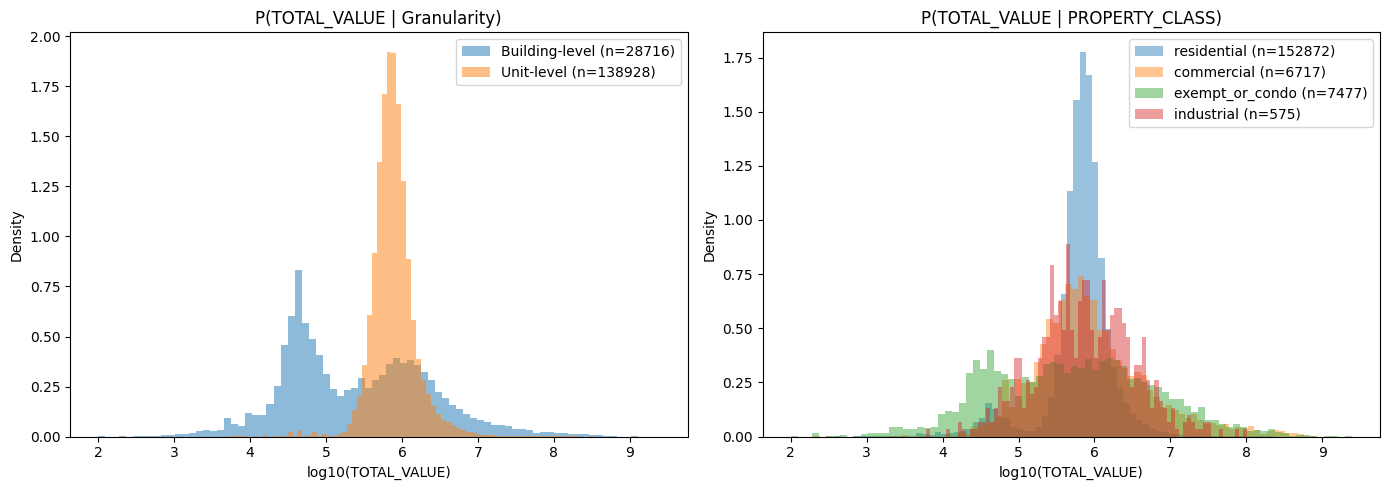

In [21]:
# Log-transform for visualization (TOTAL_VALUE spans orders of magnitude)
df_viz = df[df['TOTAL_VALUE'] > 0].copy()
df_viz['log_value'] = np.log10(df_viz['TOTAL_VALUE'])

# --- Distributions by granularity ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, group in df_viz.groupby('IS_UNIT_LEVEL'):
    name = 'Unit-level' if label == 1 else 'Building-level'
    axes[0].hist(group['log_value'], bins=80, alpha=0.5,
                 label=f"{name} (n={len(group)})", density=True)
axes[0].set_xlabel('log10(TOTAL_VALUE)')
axes[0].set_ylabel('Density')
axes[0].set_title('P(TOTAL_VALUE | Granularity)')
axes[0].legend()

# --- By PROPERTY_CLASS ---
for cls in ['residential', 'commercial', 'vacant', 'exempt_or_condo', 'industrial']:
    sub = df_viz[df_viz['PROPERTY_CLASS'] == cls]
    if len(sub) > 50:
        axes[1].hist(sub['log_value'], bins=80, alpha=0.45,
                     label=f"{cls} (n={len(sub)})", density=True)
axes[1].set_xlabel('log10(TOTAL_VALUE)')
axes[1].set_ylabel('Density')
axes[1].set_title('P(TOTAL_VALUE | PROPERTY_CLASS)')
axes[1].legend()

plt.tight_layout()
plt.show()

GRANULARITY
unit              138928
vacant             18550
whole_building     10166
Name: count, dtype: int64


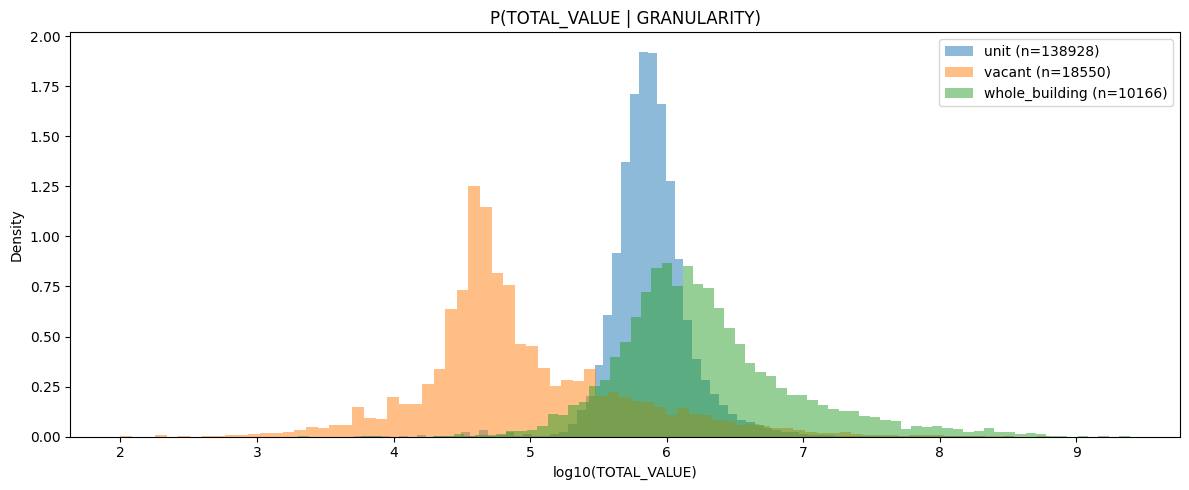

In [22]:
# Three-way granularity
def granularity(row):
    if row['BLDG_TYPE'] in ['NoBld', '99 - Vacant']:
        return 'vacant'
    luc = str(row['LUC'])
    if luc[0] in ('3', '4') or luc in ('111','112','114','125'):
        return 'whole_building'
    if (row['BED_RMS'] == -1) and (row['TT_RMS'] == -1) and row['LIVING_AREA'] > 10:
        return 'whole_building'
    return 'unit'

df['GRANULARITY'] = df.apply(granularity, axis=1)
print(df['GRANULARITY'].value_counts())

# Re-run the conditional distribution with 3 groups
fig, ax = plt.subplots(figsize=(12, 5))
for label, group in df[df['TOTAL_VALUE'] > 0].groupby('GRANULARITY'):
    logv = np.log10(group['TOTAL_VALUE'])
    ax.hist(logv, bins=80, alpha=0.5,
            label=f"{label} (n={len(group)})", density=True)
ax.set_xlabel('log10(TOTAL_VALUE)')
ax.set_ylabel('Density')
ax.set_title('P(TOTAL_VALUE | GRANULARITY)')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Show top LUCs with their row counts — reveals the natural sub-structure
print("Top 40 LUCs by frequency:")
top_luc = df['LUC'].value_counts().head(40)
print(top_luc)

print(f"\nTotal distinct LUCs: {df['LUC'].nunique()}")

# Group by first 2 digits (not just first digit) for finer view
luc_2digit = df['LUC'].astype(str).str[:2].value_counts().sort_index()
print("\nDistribution by first 2 LUC digits:")
print(luc_2digit)

Top 40 LUCs by frequency:
LUC
102    73352
101    30237
104    16555
105    13107
108     6965
132     3502
111     2422
13      2225
985     2129
112     1435
902     1330
125     1128
986      751
130      687
357      684
106      660
31       621
320      616
319      523
358      510
905      391
977      358
332      323
908      292
903      272
344      248
326      235
906      227
343      218
970      216
907      215
390      212
317      210
976      203
316      190
979      185
904      171
109      169
901      157
120      138
Name: count, dtype: int64

Total distinct LUCs: 195

Distribution by first 2 LUC digits:
LUC
10    141045
11      3945
12      1430
13      6452
30       150
31      1700
32      1283
33       708
34       986
35      1413
36        31
37        50
38       137
39       259
40       208
41        51
42        56
43        79
44        61
45        35
46        85
71         3
90      3082
91         1
92        41
93        11
94        47
95    

## Probability models for numerical features

### Check which LUC codes give similar probability distribution function | p(features∣LUC)

After $/sqft cleanup: (167644, 38)
X shape: (167644, 37), y shape: (167644,)
Distinct LUCs in X: 195
LUCs with >=30 rows: 80  |  rare LUCs (will go to 'misc'): 115

Summary table: (80, 18)
     zero_rate_living  zero_rate_gross  zero_rate_land  LIVING_AREA_mean  \
LUC                                                                        
013          0.094382         0.094382        0.001348          8.844579   
031          0.088567         0.083736        0.001610          8.694981   
101          0.000000         0.000000        0.000000          7.421924   
102          0.000000         0.000000        0.000000          6.876953   
104          0.000000         0.000000        0.000000          7.872429   

     LIVING_AREA_std  GROSS_AREA_mean  GROSS_AREA_std  LAND_SF_mean  \
LUC                                                                   
013         1.366156         9.054678        1.349690      8.129815   
031         1.001349         8.906067        1.014083      8.1900

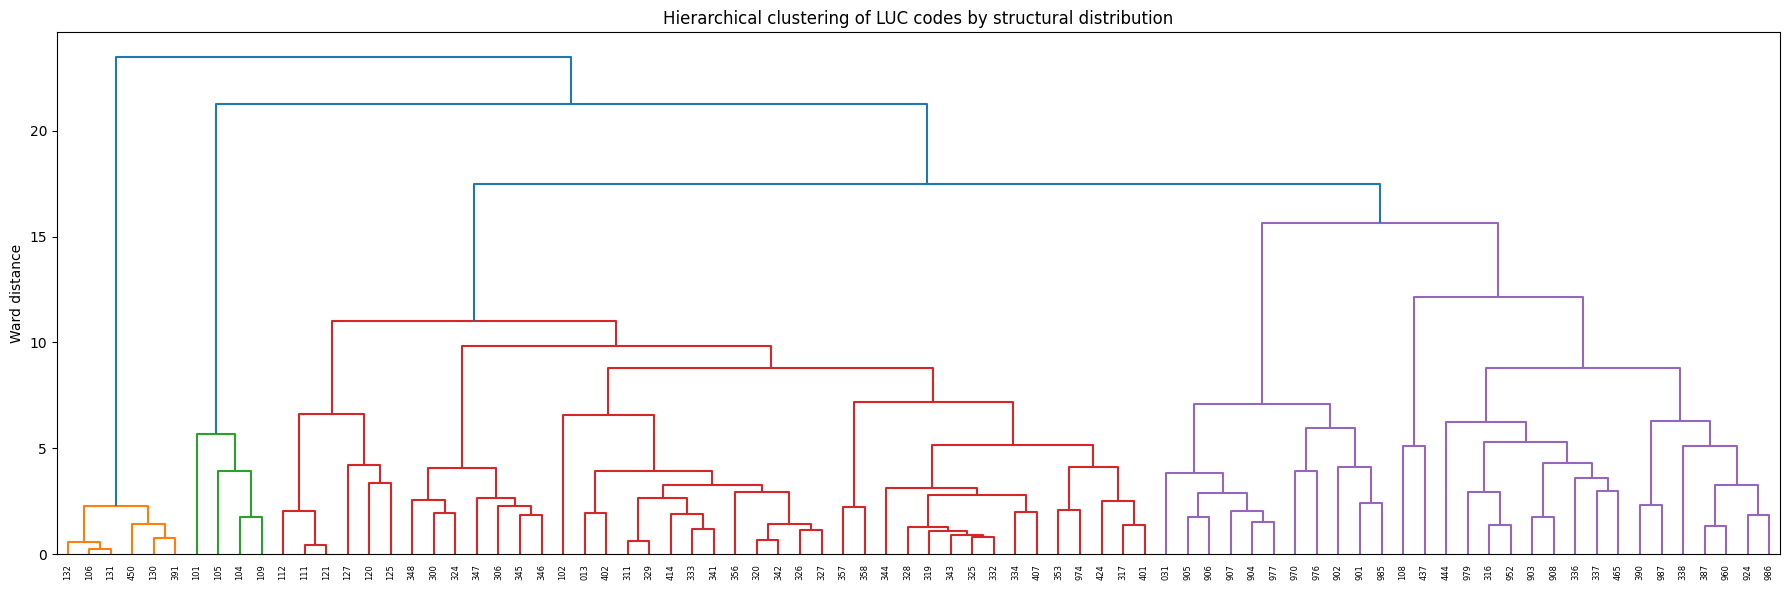


Cluster membership (LUCs grouped by cluster):
  Cluster  0  (n=  1147, 115 LUCs): ['973', '339', '124', '975', '118', '312', '900', '400', '315', '340']
  Cluster  1  (n=  4955, 6 LUCs): ['132', '130', '106', '131', '450', '391']
  Cluster  2  (n= 29831, 3 LUCs): ['104', '105', '109']
  Cluster  3  (n= 30237, 1 LUCs): ['101']
  Cluster  4  (n=  3936, 3 LUCs): ['111', '112', '121']
  Cluster  5  (n=  1297, 3 LUCs): ['125', '120', '127']
  Cluster  6  (n=   434, 7 LUCs): ['346', '347', '300', '348', '345', '324', '306']
  Cluster  7  (n=  3757, 12 LUCs): ['013', '320', '326', '341', '356', '327', '342', '329', '311', '402']
  Cluster  8  (n= 73352, 1 LUCs): ['102']
  Cluster  9  (n=  1194, 2 LUCs): ['357', '358']
  Cluster 10  (n=  1590, 8 LUCs): ['319', '332', '344', '343', '325', '328', '334', '407']
  Cluster 11  (n=   357, 5 LUCs): ['317', '424', '353', '401', '974']
  Cluster 12  (n=  1983, 6 LUCs): ['031', '905', '977', '906', '907', '904']
  Cluster 13  (n=   419, 2 LUCs): ['970'

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

# ─────────────────────────────────────────────────────────────
# 1. Load — use the version that still has LUC
#    (boston_housing_fe.csv, pre-cell-53 drop)
# ─────────────────────────────────────────────────────────────
df = pd.read_csv(
    '/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_fe.csv',
    low_memory=False
)

# Apply the $/sqft cleanup from cell 21 so we're working on the same population
built_mask = (df['LIVING_AREA'] > 0) & (df['TOTAL_VALUE'] > 0)
built = df.loc[built_mask].copy()
built['sqft'] = np.exp(built['LIVING_AREA'])
built['value_per_sqft'] = built['TOTAL_VALUE'] / built['sqft']
drop_ids = built[(built['value_per_sqft'] < 10) | (built['value_per_sqft'] > 10000)].index
df = df.drop(drop_ids).reset_index(drop=True)
print(f"After $/sqft cleanup: {df.shape}")

# ─────────────────────────────────────────────────────────────
# 2. Split X / y BEFORE touching anything else
#    y = TOTAL_VALUE is set aside and never referenced in clustering
# ─────────────────────────────────────────────────────────────
y = df['TOTAL_VALUE'].copy()
X = df.drop(columns=['TOTAL_VALUE']).copy()

# Keep LUC as string to preserve leading zeros and prevent accidental ordinal treatment
X['LUC'] = X['LUC'].astype(str).str.zfill(3)
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Distinct LUCs in X: {X['LUC'].nunique()}")

# ─────────────────────────────────────────────────────────────
# 3. Build per-LUC distribution summary
#    Features chosen are STRUCTURAL ONLY — no price leakage
# ─────────────────────────────────────────────────────────────
# Drop LUCs with <30 rows (can't summarize a distribution reliably)
luc_counts = X['LUC'].value_counts()
keep_lucs = luc_counts[luc_counts >= 30].index
rare_lucs = luc_counts[luc_counts < 30].index
print(f"LUCs with >=30 rows: {len(keep_lucs)}  |  rare LUCs (will go to 'misc'): {len(rare_lucs)}")

def summarize_luc(sub):
    """Return a vector of distribution-summary stats for one LUC's rows."""
    out = {}

    # Zero-rates — huge signal for unit vs building vs vacant
    out['zero_rate_living']  = (sub['LIVING_AREA']  == 0).mean()
    out['zero_rate_gross']   = (sub['GROSS_AREA']   == 0).mean()
    out['zero_rate_land']    = (sub['LAND_SF']      == 0).mean()

    # Log-scale area stats (fit Normal params per our earlier work)
    for col in ['LIVING_AREA', 'GROSS_AREA', 'LAND_SF']:
        nonzero = sub.loc[sub[col] > 0, col]
        out[f'{col}_mean']  = nonzero.mean() if len(nonzero) else 0
        out[f'{col}_std']   = nonzero.std(ddof=1) if len(nonzero) > 1 else 0

    # Count-feature means (Poisson lambdas)
    for col in ['BED_RMS', 'TT_RMS', 'FIREPLACES', 'NUM_PARKING', 'RES_FLOOR']:
        valid = sub.loc[sub[col] >= 0, col]   # drop -1 sentinel
        out[f'{col}_mean'] = valid.mean() if len(valid) else 0

    # Age
    ysr = sub['YEARS_SINCE_REMODEL']
    out['YSR_mean'] = ysr.mean()
    out['YSR_std']  = ysr.std(ddof=1) if len(ysr) > 1 else 0

    # BLDG_TYPE concentration — how "pure" is this LUC in terms of building form?
    bt_counts = sub['BLDG_TYPE'].value_counts(normalize=True)
    out['bldg_top_share'] = bt_counts.iloc[0] if len(bt_counts) else 0
    # Entropy: lower = more uniform building type within LUC
    out['bldg_entropy'] = -(bt_counts * np.log(bt_counts + 1e-12)).sum()

    return pd.Series(out)

summary = (
    X[X['LUC'].isin(keep_lucs)]
    .groupby('LUC', group_keys=False)
    .apply(summarize_luc)
)
print(f"\nSummary table: {summary.shape}")
print(summary.head())

# ─────────────────────────────────────────────────────────────
# 4. Standardize summary vectors, compute pairwise distances
# ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
summary_z = scaler.fit_transform(summary.fillna(0))

# Ward linkage plays nice with Euclidean distance on standardized features
Z = linkage(summary_z, method='ward')

# Dendrogram — helps you pick the cut threshold
fig, ax = plt.subplots(figsize=(18, 6))
dendrogram(Z, labels=summary.index.tolist(), leaf_rotation=90, ax=ax)
ax.set_title('Hierarchical clustering of LUC codes by structural distribution')
ax.set_ylabel('Ward distance')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# 5. Cut the tree — pick a target number of clusters
# ─────────────────────────────────────────────────────────────
N_CLUSTERS = 20   # tune based on dendrogram — start here, adjust after looking

labels = fcluster(Z, t=N_CLUSTERS, criterion='maxclust')
luc_to_cluster = dict(zip(summary.index, labels))

# Map rare LUCs (n<30) to a separate 'misc' cluster
for luc in rare_lucs:
    luc_to_cluster[luc] = 0   # cluster 0 = misc

# ─────────────────────────────────────────────────────────────
# 6. Name the clusters by inspection — which LUCs ended up together?
# ─────────────────────────────────────────────────────────────
cluster_df = pd.DataFrame({
    'LUC': list(luc_to_cluster.keys()),
    'cluster': list(luc_to_cluster.values()),
})
cluster_df['n_rows'] = cluster_df['LUC'].map(luc_counts).fillna(0).astype(int)
cluster_df = cluster_df.sort_values(['cluster', 'n_rows'], ascending=[True, False])

print("\nCluster membership (LUCs grouped by cluster):")
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]
    total_n = members['n_rows'].sum()
    luc_list = members['LUC'].tolist()[:10]  # first 10 LUCs
    print(f"  Cluster {c:2d}  (n={total_n:>6}, {len(members)} LUCs): {luc_list}")

# ─────────────────────────────────────────────────────────────
# 7. Apply the mapping back to X
# ─────────────────────────────────────────────────────────────
X['PROPERTY_CLASS'] = X['LUC'].map(luc_to_cluster).fillna(0).astype(int)
print(f"\nX now has PROPERTY_CLASS column with {X['PROPERTY_CLASS'].nunique()} distinct values")
print(X['PROPERTY_CLASS'].value_counts().sort_index())

1. Orange branch (far left, ~5 LUCs: 132, 106, 131, 450, 130, 391) — This branches off at distance ~23, higher than any other split. That means these LUCs are maximally different from everything else. These are probably the degenerate / vacant / anomalous codes — likely zero-rate-living ≈ 1, very sparse everything else. Worth inspecting, but almost certainly a "misc / vacant" cluster

2. Green branch (~5 LUCs: 101, 105, 104, 109) — Tight little cluster, splits off at ~21. These are your single-family and small multi-family residential codes. The fact that 101 (single family), 104 (two-family), 105 (three-family) cluster tightly means their structural distributions are very similar modulo size — makes sense, they're all detached homes with similar room counts, fireplaces, parking patterns.
Red branch (middle, large, ~40 LUCs including 102, 111, 112, 120s, 3xx, 4xx) — This is the biggest branch and contains two interesting sub-groups:

3. The left red sub-branch has 102 (condo!), 111, 112, 120–127, 345–348 — condos and small apartment buildings mixed with some 3xx codes
The right red sub-branch is heavy in 3xx (300, 319, 325, 332, 341, 343, 344, 357, 358) and 4xx (401, 402, 407, 414, 424) — commercial and industrial

4. Purple branch (right, ~30 LUCs: 031, 9xx heavy, some 3xx) — This is the exempt / condo-parent / institutional group. Has 9xx codes (exempt), condo parents (901, 902, 903, 904, 905, 906, 907), 985, 986 (exempt institutional).

### Findings
- Finding 1: LUC 102 (condo) doesn't cluster with 101 (single family). In your manual grouping, 101 was sfr and 102 was res_condo — correct separation. But notice how far apart they are structurally — 102 is deep inside the red branch with apartment buildings, while 101 is in the tight green cluster with 104/105. The data agrees with your split but tells you 102 is more apartment-like than house-like structurally, which you captured in your cell 54 refinement (res_condo_rise vs res_condo_rowhouse)

- Finding 2: Commercial and industrial are not well-separated. The red branch mixes 3xx and 4xx codes heavily. Your manual grouping kept them separate (com_* vs industrial), but structurally they look similar — both dominated by large GROSS_AREA, zero bedrooms, varied LAND_SF. If XGBoost doesn't need them distinguished, keeping them merged might actually be fine

- Finding 3: The orange outlier branch needs investigation. 132, 106, 131, 450, 130, 391 being maximally different is either a real finding (these are genuine outliers deserving their own class) or a signal that they have too few samples to summarize reliably. Check their row counts — if any are borderline at the 30-row threshold, they might be getting pulled into weird places by noise

In [25]:
# 1. Inspect the orange outliers — are they real or noise?
for luc in ['132', '106', '131', '450', '130', '391']:
    n = (X['LUC'] == luc).sum()
    print(f"LUC {luc}: n={n}")
    
# 2. Look at the summary vectors for the outliers vs a typical residential LUC
comparison = summary.loc[['132', '106', '131', '101', '102']].round(2)
print(comparison.T)

LUC 132: n=3502
LUC 106: n=660
LUC 131: n=38
LUC 450: n=35
LUC 130: n=687
LUC 391: n=33
LUC                132   106   131    101    102
zero_rate_living  1.00  1.00  1.00   0.00   0.00
zero_rate_gross   1.00  1.00  1.00   0.00   0.00
zero_rate_land    0.00  0.00  0.00   0.00   0.00
LIVING_AREA_mean  0.00  0.00  0.00   7.42   6.88
LIVING_AREA_std   0.00  0.00  0.00   0.36   0.45
GROSS_AREA_mean   0.00  0.00  0.00   7.95   6.89
GROSS_AREA_std    0.00  0.00  0.00   0.32   0.46
LAND_SF_mean      7.71  8.03  7.94   8.37   6.88
LAND_SF_std       0.80  0.61  0.68   0.64   0.46
BED_RMS_mean      0.00  0.00  0.00   3.43   1.82
TT_RMS_mean       0.00  0.00  0.00   7.32   4.26
FIREPLACES_mean   0.00  0.00  0.00   0.63   0.29
NUM_PARKING_mean  0.00  0.02  0.00   2.21   0.52
RES_FLOOR_mean    0.00  0.00  0.00   1.89   1.27
YSR_mean         -1.00 -0.98 -1.00  56.63  27.99
YSR_std           0.00  0.43  0.00  45.55  24.25
bldg_top_share    0.99  1.00  0.97   0.55   0.20
bldg_entropy      0.07  0.03  

In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────────────────────
# Setup — reload the version with LUC intact
# ─────────────────────────────────────────────────────────────
# Adjust path if needed — use whichever CSV still has LUC
df = pd.read_csv('/Users/yajur/Machine Learning & Pattern Recognition/Boston Housing/boston_housing_fe.csv',
                 low_memory=False)

# Recreate PROPERTY_CLASS from the hierarchical clustering mapping
# (paste your luc_to_cluster dict here, or reload it if saved)
df['LUC_STR'] = df['LUC'].astype(str).str.zfill(3)
df['PROPERTY_CLASS'] = df['LUC_STR'].map(luc_to_cluster).fillna(0).astype(int)

y = np.log1p(df['TOTAL_VALUE'].values)

def projection_from_onehot(X, y):
    count = X.sum(axis=0)
    count = np.where(count == 0, 1, count)
    coeff = (X.T @ y) / count
    y_hat = X @ coeff
    return y_hat

# ─────────────────────────────────────────────────────────────
# Argument 1 — Column space containment (mathematical)
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("ARGUMENT 1: Column space containment")
print("=" * 60)

X_luc = pd.get_dummies(df['LUC']).astype(int).values
X_pc  = pd.get_dummies(df['PROPERTY_CLASS']).astype(int).values

print(f"LUC one-hot:            shape = {X_luc.shape}")
print(f"PROPERTY_CLASS one-hot: shape = {X_pc.shape}")

# Each PROPERTY_CLASS indicator should equal the sum of its member LUC indicators.
# If so, X_pc's columns lie exactly in the column space of X_luc.
# Test: regress each PC column on X_luc — residual should be 0.
max_residual = 0
for c in range(X_pc.shape[1]):
    target_col = X_pc[:, c].astype(float)
    # Projection of this PC indicator onto LUC's column space
    coeff = (X_luc.T @ target_col) / np.maximum(X_luc.sum(axis=0), 1)
    reconstruction = X_luc @ coeff
    residual = np.linalg.norm(target_col - reconstruction)
    max_residual = max(max_residual, residual)

print(f"\nMax residual norm reconstructing any PC column from LUC columns: {max_residual:.2e}")
print("(Should be ~0 — confirms col(X_pc) ⊆ col(X_luc))")

# ─────────────────────────────────────────────────────────────
# Argument 2 — Projection R² comparison (empirical upper bound)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ARGUMENT 2: Projection R² — PROPERTY_CLASS bounded by LUC")
print("=" * 60)

y_hat_luc = projection_from_onehot(X_luc, y)
y_hat_pc  = projection_from_onehot(X_pc, y)

r2_luc = r2_score(y, y_hat_luc)
r2_pc  = r2_score(y, y_hat_pc)

print(f"R² projecting log(TOTAL_VALUE) onto LUC:            {r2_luc:.4f}")
print(f"R² projecting log(TOTAL_VALUE) onto PROPERTY_CLASS: {r2_pc:.4f}")
print(f"Information lost by coarsening LUC → PROPERTY_CLASS: {r2_luc - r2_pc:.4f}")
print(f"\n(Theorem: R²(PC) ≤ R²(LUC) because col(X_pc) ⊆ col(X_luc). Verified: {r2_pc <= r2_luc})")

# ─────────────────────────────────────────────────────────────
# Argument 3 — Tree model recovers LUC signal without needing PC
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ARGUMENT 3: Model-based — XGBoost recovers the grouping")
print("=" * 60)

# Build three feature sets, holding everything else constant
feature_base = df.drop(columns=['TOTAL_VALUE', 'LUC_STR', 'LUC', 'PROPERTY_CLASS'])

# Encode categoricals once
for col in feature_base.select_dtypes(include=['object']).columns:
    feature_base[col] = LabelEncoder().fit_transform(feature_base[col].astype(str))
feature_base = feature_base.fillna(-1)

# Three versions
X_A = feature_base.copy()
X_A['LUC'] = LabelEncoder().fit_transform(df['LUC'].astype(str))                  # LUC only

X_B = feature_base.copy()
X_B['PROPERTY_CLASS'] = df['PROPERTY_CLASS'].values                                # PC only

X_C = feature_base.copy()
X_C['LUC'] = X_A['LUC']
X_C['PROPERTY_CLASS'] = df['PROPERTY_CLASS'].values                                # Both

# Same split for all three — fair comparison
for name, X_var in [('LUC only', X_A),
                    ('PROPERTY_CLASS only', X_B),
                    ('Both', X_C)]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_var, y, test_size=0.2, random_state=42)
    model = XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.05,
                         random_state=42, n_jobs=-1, verbosity=0)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    print(f"  {name:25s} R²(log) = {r2_score(y_te, pred):.4f}")

# ─────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"• Col space of PROPERTY_CLASS one-hot is contained in LUC one-hot (residual ≈ 0)")
print(f"• Linear projection: LUC explains {r2_luc:.1%} variance, PROPERTY_CLASS explains {r2_pc:.1%}")
print(f"  → PROPERTY_CLASS loses {100*(r2_luc-r2_pc):.1f} percentage points of explainable variance")
print(f"• XGBoost: compare the 'Both' vs 'LUC only' scores above")
print(f"  If they're ~equal, PROPERTY_CLASS adds nothing XGBoost couldn't learn from LUC")

ARGUMENT 1: Column space containment
LUC one-hot:            shape = (167731, 195)
PROPERTY_CLASS one-hot: shape = (167731, 21)

Max residual norm reconstructing any PC column from LUC columns: 0.00e+00
(Should be ~0 — confirms col(X_pc) ⊆ col(X_luc))

ARGUMENT 2: Projection R² — PROPERTY_CLASS bounded by LUC
R² projecting log(TOTAL_VALUE) onto LUC:            0.5856
R² projecting log(TOTAL_VALUE) onto PROPERTY_CLASS: 0.5179
Information lost by coarsening LUC → PROPERTY_CLASS: 0.0677

(Theorem: R²(PC) ≤ R²(LUC) because col(X_pc) ⊆ col(X_luc). Verified: True)

ARGUMENT 3: Model-based — XGBoost recovers the grouping


/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_37795/3105499148.py:86: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in feature_base.select_dtypes(include=['object']).columns:


  LUC only                  R²(log) = 0.9409
  PROPERTY_CLASS only       R²(log) = 0.9357
  Both                      R²(log) = 0.9404

SUMMARY
• Col space of PROPERTY_CLASS one-hot is contained in LUC one-hot (residual ≈ 0)
• Linear projection: LUC explains 58.6% variance, PROPERTY_CLASS explains 51.8%
  → PROPERTY_CLASS loses 6.8 percentage points of explainable variance
• XGBoost: compare the 'Both' vs 'LUC only' scores above
  If they're ~equal, PROPERTY_CLASS adds nothing XGBoost couldn't learn from LUC


Empirical verification of the information-theoretic argument:

Column-space containment (algebraic): Every PROPERTY_CLASS one-hot column is reconstructible from LUC one-hot columns with residual norm = 0.00e+00, confirming col(XPC)⊆col(XLUC)\text{col}(X_{\text{PC}}) \subseteq \text{col}(X_{\text{LUC}})
col(XPC​)⊆col(XLUC​) as expected.

Linear projection (statistical): R2R^2
R2 of log⁡(TOTAL_VALUE)\log(\text{TOTAL\_VALUE})
log(TOTAL_VALUE) projected onto the one-hot encoding is
0.5856 for LUC and 0.5179 for PROPERTY_CLASS — the coarsening discards 6.77 percentage points of explainable variance, retaining 88.4% of LUC's signal.
**Nonlinear model (practical):** Holding all other features constant, XGBoost achieves Rlog⁡2R^2_{\log}
Rlog2​ of **0.9409 with LUC alone**, **0.9357 with PROPERTY_CLASS alone**, and **0.9404 with both**. Adding PROPERTY_CLASS to LUC slightly *degrades* performance — the model must allocate tree capacity to a feature that provides no new information, while XGBoost's depth-wise splits already recover any useful groupings of LUC on their own.


All three lines of evidence support retaining LUC and dropping PROPERTY_CLASS for this pipeline. PROPERTY_CLASS retains value as (a) a linear-model feature, where its lower cardinality aids generalization, (b) an interpretable stakeholder-facing categorical, and (c) a deployment fallback if unseen LUC codes appear at inference — none of which are active constraints here.

## Probability distribution

### Target feature and LIVING_AREA


--- log(TOTAL_VALUE) --- (best fit first)
  norm        KS=0.1665  p=0.0000
  lognorm     KS=0.1665  p=0.0000
  gamma       KS=0.1874  p=0.0000
  expon       KS=0.4841  p=0.0000

--- LIVING_AREA (log scale) --- (best fit first)
  lognorm     KS=0.0437  p=0.0000
  gamma       KS=0.0476  p=0.0000
  norm        KS=0.0589  p=0.0000
  expon       KS=0.5255  p=0.0000


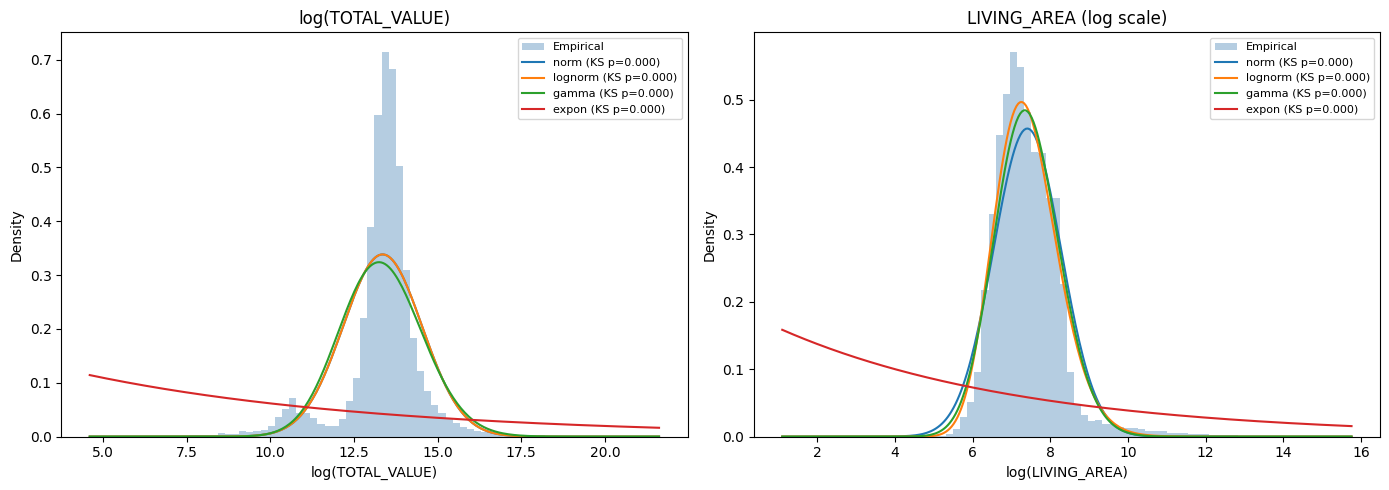

In [27]:
# Columns to fit — LIVING_AREA is already log-transformed in the CSV
# TOTAL_VALUE is raw — we fit both raw and log versions
target = df['TOTAL_VALUE'][df['TOTAL_VALUE'] > 0]
log_target = np.log(target)

living = df['LIVING_AREA'][df['LIVING_AREA'] > 0]  # already log-scale in CSV

# Distributions to try
candidates = {
    'norm':       stats.norm,
    'lognorm':    stats.lognorm,
    'gamma':      stats.gamma,
    'expon':      stats.expon,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name_col, data, xlabel) in zip(axes, [
    ('log(TOTAL_VALUE)', log_target, 'log(TOTAL_VALUE)'),
    ('LIVING_AREA (log scale)', living, 'log(LIVING_AREA)')
]):
    ax.hist(data, bins=80, density=True, alpha=0.4, color='steelblue', label='Empirical')
    x = np.linspace(data.min(), data.max(), 300)

    results = []
    for dist_name, dist in candidates.items():
        params = dist.fit(data)
        pdf_vals = dist.pdf(x, *params)
        ks_stat, ks_p = stats.kstest(data, dist_name, args=params)
        ax.plot(x, pdf_vals, label=f'{dist_name} (KS p={ks_p:.3f})')
        results.append((dist_name, ks_stat, ks_p, params))

    results.sort(key=lambda r: r[1])  # sort by KS statistic (lower = better fit)
    print(f"\n--- {name_col} --- (best fit first)")
    for dist_name, ks_stat, ks_p, params in results:
        print(f"  {dist_name:10s}  KS={ks_stat:.4f}  p={ks_p:.4f}")

    ax.set_title(name_col)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

LIVING_AREA shows a clean normal distribution but TOTAL_VALUE is a mixture of various probability distributions. We should check the distribution by conditioning TOTAL_VALUE on a high predictive singal's class like LUC. Lets pick the LUC class which has most values i.e. 102

LUC 102 — within-class: n=73352, μ=13.44, σ=0.62
KS = 0.0779


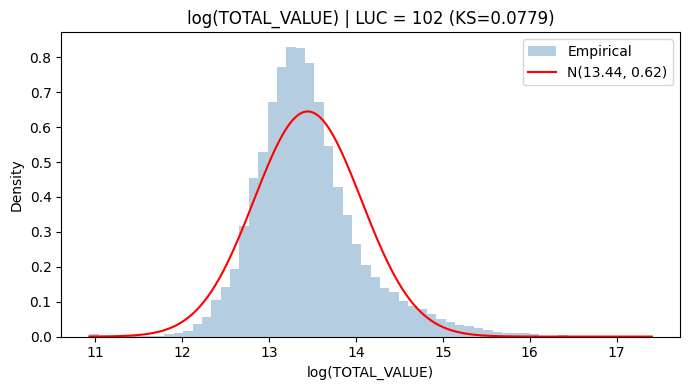

In [28]:
# Fit Normal to log(TOTAL_VALUE) within a single LUC
cls = df[df['LUC'] == 102]          # or whichever you pick
target = np.log(cls['TOTAL_VALUE'][cls['TOTAL_VALUE'] > 0])

mu, sigma = target.mean(), target.std()
ks_stat, ks_p = stats.kstest(target, 'norm', args=(mu, sigma))
print(f"LUC 102 — within-class: n={len(target)}, μ={mu:.2f}, σ={sigma:.2f}")
print(f"KS = {ks_stat:.4f}")

# Visual confirmation
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(target, bins=60, density=True, alpha=0.4, color='steelblue', label='Empirical')
x = np.linspace(target.min(), target.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', label=f'N({mu:.2f}, {sigma:.2f})')
ax.set_xlabel('log(TOTAL_VALUE)')
ax.set_ylabel('Density')
ax.set_title(f'log(TOTAL_VALUE) | LUC = 102 (KS={ks_stat:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

This plot confirms more Gaussian-ness when conditioning TOTAL_VALUE on LUC=102. Lets try conditioning even further using 102 and BLDG_TYPE = HR - High rise

LUC 102 + HR: n=7732, μ=14.04, σ=0.80, KS=0.0405


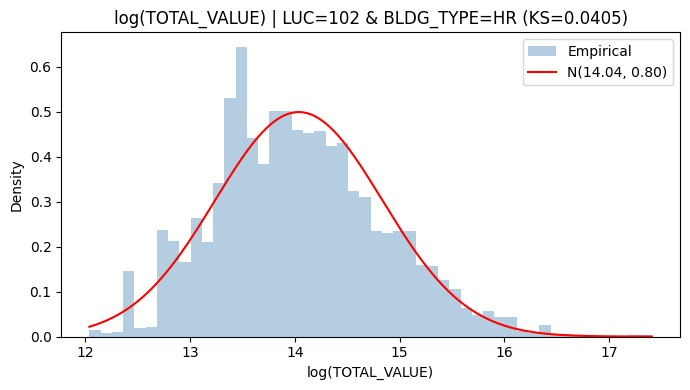

In [29]:
cls = df[(df['LUC'] == 102) & (df['BLDG_TYPE'] == 'HR - High Rise')]
target = np.log(cls['TOTAL_VALUE'][cls['TOTAL_VALUE'] > 0])

mu, sigma = target.mean(), target.std()
ks_stat, ks_p = stats.kstest(target, 'norm', args=(mu, sigma))
print(f"LUC 102 + HR: n={len(target)}, μ={mu:.2f}, σ={sigma:.2f}, KS={ks_stat:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(target, bins=50, density=True, alpha=0.4, color='steelblue', label='Empirical')
x = np.linspace(target.min(), target.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', label=f'N({mu:.2f}, {sigma:.2f})')
ax.set_title(f'log(TOTAL_VALUE) | LUC=102 & BLDG_TYPE=HR (KS={ks_stat:.4f})')
ax.set_xlabel('log(TOTAL_VALUE)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

1. Generative models must condition. Any parametric generative model for property value must be specified conditionally on property type — specifically p(logV∣LUC,BLDG_TYPE) — rather than marginally. A Gaussian Naive Bayes or class-conditional Gaussian classifier is therefore a viable generative baseline; a single-Normal model is not.

2. Tree models implicitly exploit this structure. Gradient-boosted trees splitting on LUC and BLDG\_TYPE before splitting on continuous features are effectively learning the mixture components from data. This is consistent with the observed result that XGBoost achieves Rlog⁡2=0.951R^2 using raw LUC — the model is rediscovering the class-conditional structure through its splits.

3. Anomaly detection should be class-conditional. Flagging a property as a price outlier based on the marginal distribution p(log⁡V)p(\log V)
p(logV) will misclassify low-value land records and high-value luxury units as anomalies when they are typical for their class. A density threshold on p(log⁡V∣c) — within each cluster — produces calibrated outlier scores.

## Naive Bayes Classifier

LUCs kept (n≥30): 80
Rows: 166579 (99.3% of full dataset)
Train: 133263, Test: 33316
  scored 0/33316
  scored 5000/33316
  scored 10000/33316
  scored 15000/33316
  scored 20000/33316
  scored 25000/33316
  scored 30000/33316

──────────────────────────────────────────────────
Naive Bayes classifier over 80 LUCs
──────────────────────────────────────────────────
  Top-1 accuracy:     0.6986
  Top-3 accuracy:     0.8784
  Majority baseline:  0.4403  (always predict LUC 102)
  Random baseline:    0.0125  (uniform over classes)
  Lift over majority: 1.6x


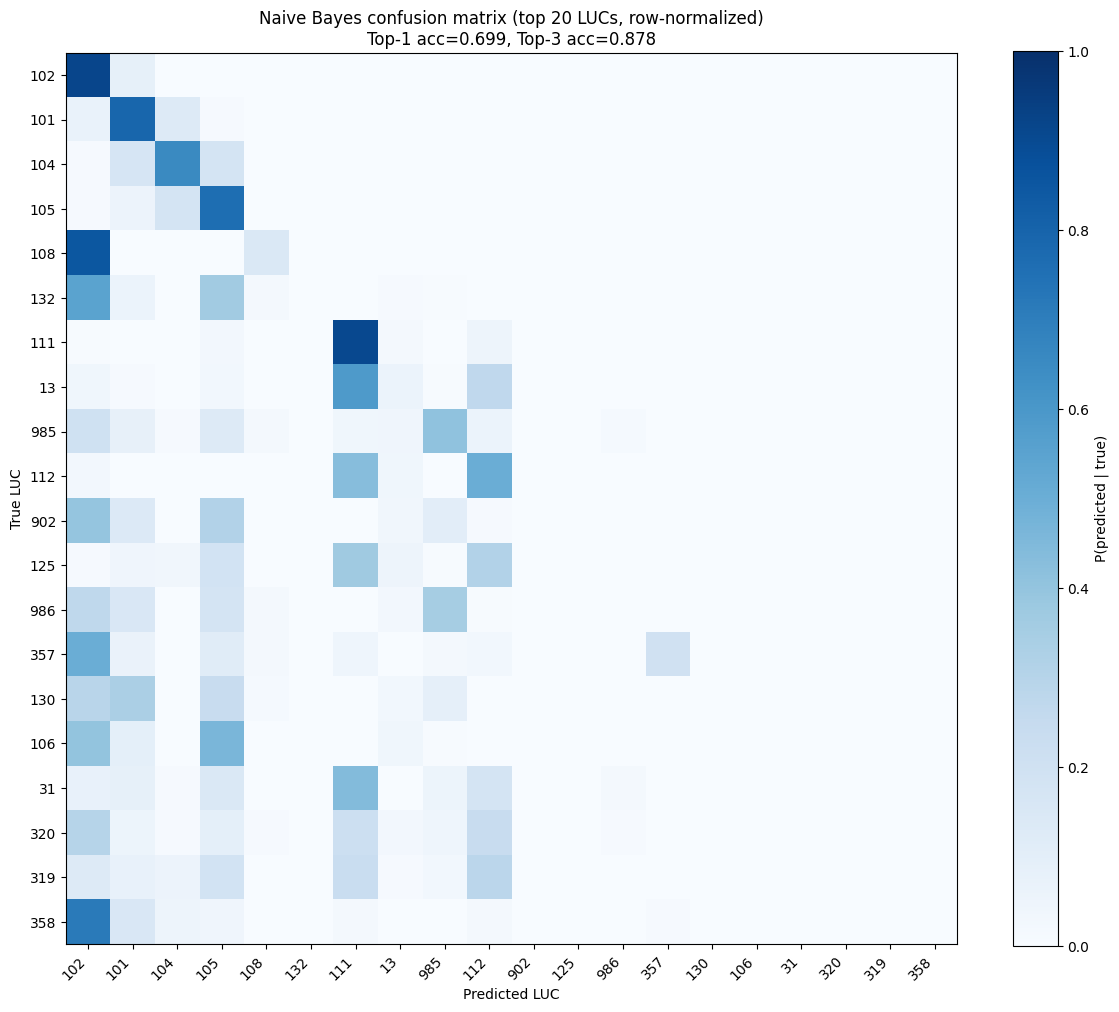

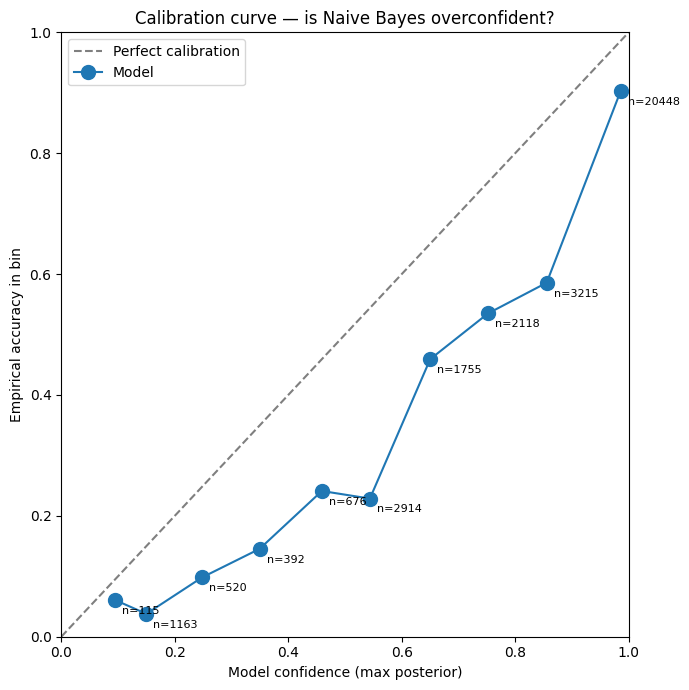

In [30]:
# ─────────────────────────────────────────────────────────────
# 1. Data preparation
# ─────────────────────────────────────────────────────────────

# Features: structural numerical only — no categoricals that encode LUC
feature_config = {
    # (feature_name, distribution_family, sentinel_to_filter)
    'LIVING_AREA':         ('normal', None),      # log-scale, fit Normal on >0
    'LAND_SF':             ('normal', None),
    'GROSS_AREA':          ('normal', None),
    'BED_RMS':             ('poisson', -1),       # -1 is "not applicable"
    'TT_RMS':              ('poisson', -1),
    'FIREPLACES':          ('poisson', None),
    'NUM_PARKING':         ('poisson', None),
    'YEARS_SINCE_REMODEL': ('normal', -1),        # -1 is "missing"
}

features = list(feature_config.keys())

# Keep only LUCs with ≥30 rows so we can reliably estimate per-class distributions
min_samples_per_class = 30
luc_counts = df['LUC'].value_counts()
keep_lucs = luc_counts[luc_counts >= min_samples_per_class].index.tolist()

mask = df['LUC'].isin(keep_lucs)
data = df.loc[mask, features + ['LUC']].copy()
print(f"LUCs kept (n≥{min_samples_per_class}): {len(keep_lucs)}")
print(f"Rows: {len(data)} ({mask.mean():.1%} of full dataset)")

# Train/test split — stratify to guarantee each LUC appears in both sets
X = data[features]
y = data['LUC']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# ─────────────────────────────────────────────────────────────
# 2. Fit class-conditional distributions
# ─────────────────────────────────────────────────────────────
# For each LUC c and each feature x_j, store the fitted distribution params.
# fitted[c][feature] = {'family': ..., 'params': ...}

def fit_feature_per_class(train_X, train_y, feature, family, sentinel):
    """Fit one distribution per class for a single feature."""
    fits = {}
    for c in train_y.unique():
        x = train_X.loc[train_y == c, feature].values
        if sentinel is not None:
            x = x[x != sentinel]
        if len(x) < 5:
            fits[c] = None   # too few samples → use a fallback at inference
            continue
        
        if family == 'normal':
            x_valid = x[x > 0] if (x == 0).any() else x
            if len(x_valid) < 5:
                fits[c] = None
                continue
            mu, sigma = x_valid.mean(), x_valid.std(ddof=1)
            sigma = max(sigma, 1e-3)   # guard against zero variance
            fits[c] = {'family': 'normal', 'mu': mu, 'sigma': sigma}
        
        elif family == 'poisson':
            x_valid = x[x >= 0]
            if len(x_valid) < 5:
                fits[c] = None
                continue
            lam = max(x_valid.mean(), 1e-3)
            fits[c] = {'family': 'poisson', 'lam': lam}
    return fits

fitted = {feat: fit_feature_per_class(X_train, y_train, feat, family, sentinel)
          for feat, (family, sentinel) in feature_config.items()}

# Prior: P(LUC=c) from training frequencies
prior = y_train.value_counts(normalize=True).to_dict()
log_prior = {c: np.log(p) for c, p in prior.items()}

# ─────────────────────────────────────────────────────────────
# 3. Log-likelihood computation
# ─────────────────────────────────────────────────────────────

def log_likelihood_row(x_row, fitted, feature_config, class_c):
    """Sum of log p(x_j | c) across features, assuming conditional independence."""
    total = 0.0
    for feat, (family, sentinel) in feature_config.items():
        val = x_row[feat]
        # Skip features with sentinel values — treat as missing, don't penalize
        if sentinel is not None and val == sentinel:
            continue
        
        fit = fitted[feat].get(class_c)
        if fit is None:
            # No fit for this class → fall back to a very small log-probability
            total += -20.0
            continue
        
        if fit['family'] == 'normal':
            # Normal likelihood, only valid for positive values if we filtered zeros
            if val <= 0:
                continue
            total += stats.norm.logpdf(val, loc=fit['mu'], scale=fit['sigma'])
        elif fit['family'] == 'poisson':
            if val < 0 or val != int(val):
                continue
            total += stats.poisson.logpmf(int(val), mu=fit['lam'])
    return total

# ─────────────────────────────────────────────────────────────
# 4. Predict on test set
# ─────────────────────────────────────────────────────────────

classes = sorted(fitted['LIVING_AREA'].keys())   # all LUCs with fits
n_test = len(X_test)
log_posteriors = np.zeros((n_test, len(classes)))

for i, (_, row) in enumerate(X_test.iterrows()):
    for j, c in enumerate(classes):
        log_posteriors[i, j] = log_prior[c] + log_likelihood_row(row, fitted, feature_config, c)
    if i % 5000 == 0:
        print(f"  scored {i}/{n_test}")

# Normalize to get posterior probabilities (log-sum-exp for numerical stability)
log_evidence = np.logaddexp.reduce(log_posteriors, axis=1, keepdims=True)
log_post_normalized = log_posteriors - log_evidence
posteriors = np.exp(log_post_normalized)

predicted_classes = np.array([classes[j] for j in posteriors.argmax(axis=1)])
top3_idx = np.argsort(-posteriors, axis=1)[:, :3]
top3_classes = np.array([[classes[j] for j in row] for row in top3_idx])

# ─────────────────────────────────────────────────────────────
# 5. Metrics
# ─────────────────────────────────────────────────────────────

y_test_arr = y_test.values
top1_acc = (predicted_classes == y_test_arr).mean()
top3_acc = np.mean([y_test_arr[i] in top3_classes[i] for i in range(n_test)])

# Baseline: always predict the most common class
baseline_class = y_train.value_counts().idxmax()
baseline_acc = (y_test_arr == baseline_class).mean()

print(f"\n{'─'*50}")
print(f"Naive Bayes classifier over {len(classes)} LUCs")
print(f"{'─'*50}")
print(f"  Top-1 accuracy:     {top1_acc:.4f}")
print(f"  Top-3 accuracy:     {top3_acc:.4f}")
print(f"  Majority baseline:  {baseline_acc:.4f}  (always predict LUC {baseline_class})")
print(f"  Random baseline:    {1/len(classes):.4f}  (uniform over classes)")
print(f"  Lift over majority: {top1_acc/baseline_acc:.1f}x")

# ─────────────────────────────────────────────────────────────
# 6. Confusion matrix — top 20 most frequent LUCs only for readability
# ─────────────────────────────────────────────────────────────
top_classes = y_test.value_counts().head(20).index.tolist()

mask_top = np.isin(y_test_arr, top_classes) & np.isin(predicted_classes, top_classes)
cm = confusion_matrix(y_test_arr[mask_top], predicted_classes[mask_top], labels=top_classes)

# Row-normalized: P(predicted | true)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(top_classes)))
ax.set_yticks(range(len(top_classes)))
ax.set_xticklabels(top_classes, rotation=45, ha='right')
ax.set_yticklabels(top_classes)
ax.set_xlabel('Predicted LUC')
ax.set_ylabel('True LUC')
ax.set_title(f'Naive Bayes confusion matrix (top 20 LUCs, row-normalized)\nTop-1 acc={top1_acc:.3f}, Top-3 acc={top3_acc:.3f}')
plt.colorbar(im, ax=ax, label='P(predicted | true)')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# 7. Calibration check — when the model says "X% confident", is it right X% of the time?
# ─────────────────────────────────────────────────────────────
confidence = posteriors.max(axis=1)
correct = (predicted_classes == y_test_arr).astype(int)

bins = np.linspace(0, 1, 11)
bin_means = 0.5 * (bins[:-1] + bins[1:])
bin_accuracy = []
bin_confidence = []
bin_counts = []

for i in range(10):
    mask_bin = (confidence >= bins[i]) & (confidence < bins[i+1])
    if mask_bin.sum() > 0:
        bin_accuracy.append(correct[mask_bin].mean())
        bin_confidence.append(confidence[mask_bin].mean())
        bin_counts.append(mask_bin.sum())
    else:
        bin_accuracy.append(np.nan)
        bin_confidence.append(bin_means[i])
        bin_counts.append(0)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(bin_confidence, bin_accuracy, 'o-', markersize=10, label='Model')
for i, n in enumerate(bin_counts):
    if n > 0:
        ax.annotate(f'n={n}', (bin_confidence[i], bin_accuracy[i]),
                    textcoords='offset points', xytext=(5, -10), fontsize=8)
ax.set_xlabel('Model confidence (max posterior)')
ax.set_ylabel('Empirical accuracy in bin')
ax.set_title('Calibration curve — is Naive Bayes overconfident?')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

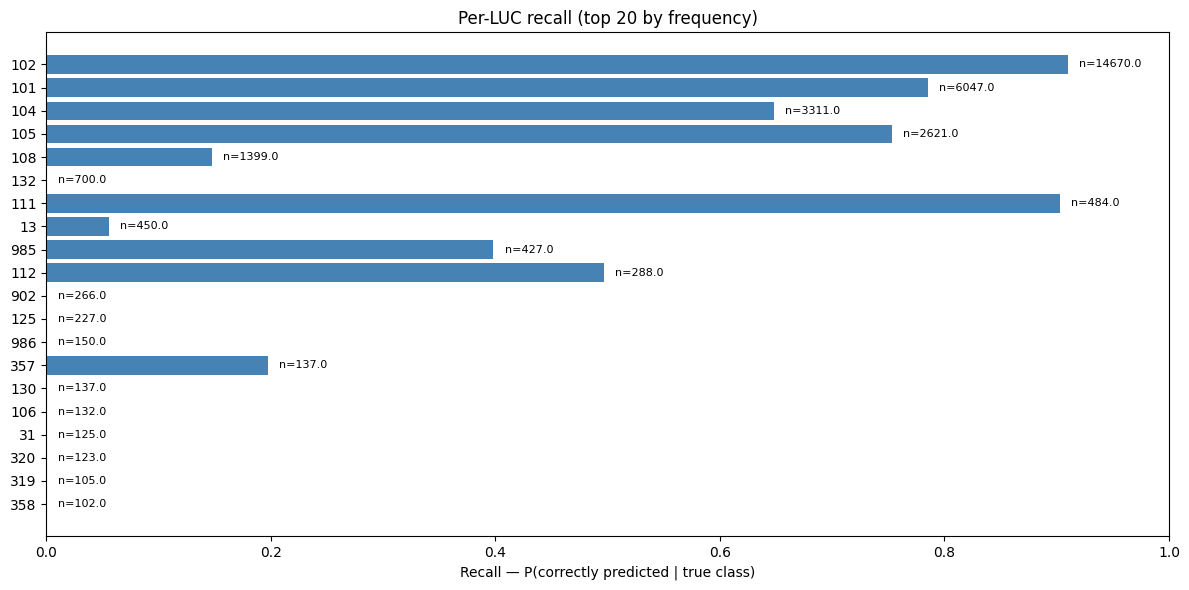

     precision  recall  f1-score  support
102      0.822   0.910     0.864    14670
101      0.677   0.786     0.727     6047
104      0.614   0.648     0.630     3311
105      0.580   0.753     0.655     2621
108      0.789   0.147     0.248     1399
132      0.000   0.000     0.000      700
111      0.381   0.903     0.536      484
13       0.175   0.056     0.084      450
985      0.353   0.398     0.374      427
112      0.240   0.497     0.324      288
902      0.000   0.000     0.000      266
125      0.000   0.000     0.000      227
986      0.000   0.000     0.000      150
357      0.871   0.197     0.321      137
130      0.000   0.000     0.000      137
106      0.000   0.000     0.000      132
31       0.000   0.000     0.000      125
320      0.000   0.000     0.000      123
319      0.000   0.000     0.000      105
358      0.000   0.000     0.000      102


In [31]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test_arr, predicted_classes,
    output_dict=True, zero_division=0
)

# Drop the summary rows (accuracy, macro avg, weighted avg)
summary_keys = {'accuracy', 'macro avg', 'weighted avg'}
per_class = {k: v for k, v in report.items() if k not in summary_keys}

per_class_df = pd.DataFrame(per_class).T
per_class_df['support'] = per_class_df['support'].astype(int)
per_class_df['recall'] = per_class_df['recall'].astype(float)
per_class_df['precision'] = per_class_df['precision'].astype(float)
per_class_df['f1-score'] = per_class_df['f1-score'].astype(float)

# Top 20 by support (most frequent classes)
top20 = per_class_df.sort_values('support', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top20.index.astype(str), top20['recall'], color='steelblue')
ax.set_xlabel('Recall — P(correctly predicted | true class)')
ax.set_title('Per-LUC recall (top 20 by frequency)')
ax.set_xlim(0, 1)
ax.invert_yaxis()

# Annotate bars with support count
for bar, (_, row) in zip(bars, top20.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'n={row["support"]}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(top20[['precision', 'recall', 'f1-score', 'support']].round(3))

In [32]:
# ─────────────────────────────────────────────────────────────
# 1. Feature config — now with Bernoulli indicators
# ─────────────────────────────────────────────────────────────
feature_config = {
    # Continuous features — fit Normal on positive values (skip zeros/sentinels)
    'LIVING_AREA':         ('normal_nonzero', None),
    'LAND_SF':             ('normal_nonzero', None),
    'GROSS_AREA':          ('normal_nonzero', None),
    'YEARS_SINCE_REMODEL': ('normal_nonneg', -1),    # -1 is missing, fit on >=0

    # Count features — fit Poisson on valid values only
    'BED_RMS':             ('poisson', -1),
    'TT_RMS':              ('poisson', -1),
    'FIREPLACES':          ('poisson', None),
    'NUM_PARKING':         ('poisson', None),

    # Bernoulli indicators — the "missingness is signal" features
    'HAS_LIVING':          ('bernoulli', None),    # 1 if LIVING_AREA > 0
    'HAS_GROSS':           ('bernoulli', None),
    'HAS_LAND':            ('bernoulli', None),
    'HAS_BED_DATA':        ('bernoulli', None),    # 1 if BED_RMS != -1
    'HAS_ROOM_DATA':       ('bernoulli', None),    # 1 if TT_RMS != -1
    'HAS_REMODEL_DATA':    ('bernoulli', None),    # 1 if YEARS_SINCE_REMODEL != -1
}

features = list(feature_config.keys())

# Reload only the raw columns we need, then build the indicators
raw_cols = ['LIVING_AREA', 'LAND_SF', 'GROSS_AREA', 'YEARS_SINCE_REMODEL',
            'BED_RMS', 'TT_RMS', 'FIREPLACES', 'NUM_PARKING', 'LUC']
data = df[raw_cols].copy()

data['HAS_LIVING']       = (data['LIVING_AREA']  > 0).astype(int)
data['HAS_GROSS']        = (data['GROSS_AREA']   > 0).astype(int)
data['HAS_LAND']         = (data['LAND_SF']      > 0).astype(int)
data['HAS_BED_DATA']     = (data['BED_RMS']      != -1).astype(int)
data['HAS_ROOM_DATA']    = (data['TT_RMS']       != -1).astype(int)
data['HAS_REMODEL_DATA'] = (data['YEARS_SINCE_REMODEL'] != -1).astype(int)

# ─────────────────────────────────────────────────────────────
# 2. Filter classes with ≥30 samples, stratified split
# ─────────────────────────────────────────────────────────────
min_samples_per_class = 30
luc_counts = data['LUC'].value_counts()
keep_lucs = luc_counts[luc_counts >= min_samples_per_class].index.tolist()

data = data[data['LUC'].isin(keep_lucs)].copy()
X = data[features]
y = data['LUC']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"LUCs kept: {len(keep_lucs)} | Rows: {len(data)} | "
      f"Train: {len(X_train)}, Test: {len(X_test)}")

# ─────────────────────────────────────────────────────────────
# 3. Fit per-class distributions (now handles Bernoulli)
# ─────────────────────────────────────────────────────────────

def fit_feature_per_class(train_X, train_y, feature, family, sentinel):
    fits = {}
    for c in train_y.unique():
        x = train_X.loc[train_y == c, feature].values
        
        if family == 'normal_nonzero':
            x_valid = x[x > 0]
            if len(x_valid) < 5:
                fits[c] = None; continue
            mu = x_valid.mean()
            sigma = max(x_valid.std(ddof=1), 1e-3)
            fits[c] = {'family': 'normal', 'mu': mu, 'sigma': sigma}
        
        elif family == 'normal_nonneg':
            x_valid = x[x >= 0] if sentinel is not None else x
            if len(x_valid) < 5:
                fits[c] = None; continue
            mu = x_valid.mean()
            sigma = max(x_valid.std(ddof=1), 1e-3)
            fits[c] = {'family': 'normal', 'mu': mu, 'sigma': sigma}
        
        elif family == 'poisson':
            x_valid = x[x >= 0] if sentinel is not None else x
            if len(x_valid) < 5:
                fits[c] = None; continue
            lam = max(x_valid.mean(), 1e-3)
            fits[c] = {'family': 'poisson', 'lam': lam}
        
        elif family == 'bernoulli':
            # Laplace smoothing so p is never exactly 0 or 1
            p = (x.sum() + 1) / (len(x) + 2)
            fits[c] = {'family': 'bernoulli', 'p': p}
    
    return fits

fitted = {feat: fit_feature_per_class(X_train, y_train, feat, family, sentinel)
          for feat, (family, sentinel) in feature_config.items()}

prior = y_train.value_counts(normalize=True).to_dict()
log_prior = {c: np.log(p) for c, p in prior.items()}

# ─────────────────────────────────────────────────────────────
# 4. Log-likelihood — sentinels now skip continuous/count features
#    but the HAS_* indicator carries the information
# ─────────────────────────────────────────────────────────────

def log_likelihood_row(x_row, fitted, feature_config, class_c):
    total = 0.0
    for feat, (family, sentinel) in feature_config.items():
        val = x_row[feat]
        fit = fitted[feat].get(class_c)
        if fit is None:
            total += -20.0
            continue
        
        # For continuous/count features: still skip sentinels, but HAS_* carries that info
        if sentinel is not None and val == sentinel:
            continue
        if family.startswith('normal') and val <= 0:
            continue  # HAS_* feature carries "this is zero" info
        
        if fit['family'] == 'normal':
            total += stats.norm.logpdf(val, loc=fit['mu'], scale=fit['sigma'])
        elif fit['family'] == 'poisson':
            if val < 0 or val != int(val):
                continue
            total += stats.poisson.logpmf(int(val), mu=fit['lam'])
        elif fit['family'] == 'bernoulli':
            p = fit['p']
            total += np.log(p if val == 1 else 1 - p)
    return total

# ─────────────────────────────────────────────────────────────
# 5. Predict + normalize
# ─────────────────────────────────────────────────────────────
classes = sorted(fitted['LIVING_AREA'].keys())
n_test = len(X_test)
log_posteriors = np.zeros((n_test, len(classes)))

X_test_records = X_test.to_dict('records')
for i, row in enumerate(X_test_records):
    for j, c in enumerate(classes):
        log_posteriors[i, j] = log_prior[c] + log_likelihood_row(row, fitted, feature_config, c)
    if i % 5000 == 0:
        print(f"  scored {i}/{n_test}")

log_evidence = np.logaddexp.reduce(log_posteriors, axis=1, keepdims=True)
posteriors = np.exp(log_posteriors - log_evidence)
predicted_classes = np.array([classes[j] for j in posteriors.argmax(axis=1)])
top3_idx = np.argsort(-posteriors, axis=1)[:, :3]
top3_classes = np.array([[classes[j] for j in row] for row in top3_idx])

# ─────────────────────────────────────────────────────────────
# 6. Metrics — compare against Option A baseline
# ─────────────────────────────────────────────────────────────
y_test_arr = y_test.values
top1_acc = (predicted_classes == y_test_arr).mean()
top3_acc = np.mean([y_test_arr[i] in top3_classes[i] for i in range(n_test)])
baseline_acc = (y_test_arr == y_train.value_counts().idxmax()).mean()

print(f"\n{'─'*60}")
print(f"Naive Bayes with Bernoulli indicators — {len(classes)} LUCs")
print(f"{'─'*60}")
print(f"  Top-1 accuracy:     {top1_acc:.4f}   (Option A was 0.6986)")
print(f"  Top-3 accuracy:     {top3_acc:.4f}   (Option A was 0.8784)")
print(f"  Majority baseline:  {baseline_acc:.4f}")
print(f"  Lift over majority: {top1_acc/baseline_acc:.2f}x")

# Per-class breakdown — especially look at the previously zero-recall classes
report = classification_report(y_test_arr, predicted_classes, output_dict=True, zero_division=0)
summary_keys = {'accuracy', 'macro avg', 'weighted avg'}
per_class = {k: v for k, v in report.items() if k not in summary_keys}
per_class_df = pd.DataFrame(per_class).T
per_class_df['support'] = per_class_df['support'].astype(int)
per_class_df = per_class_df.sort_values('support', ascending=False).head(20)

print(f"\nTop 20 classes by support:")
print(per_class_df[['precision', 'recall', 'f1-score', 'support']].round(3).to_string())

# Which previously-zero-recall classes recovered?
zero_before = ['132', '902', '125', '986', '130', '106', '31', '320', '319', '358']
# (adjust to whatever dtype your LUC column uses; strip quotes if integer)
recovered = []
for luc in zero_before:
    luc_typed = int(luc) if y_test_arr.dtype != object else luc
    if luc_typed in per_class:
        r = per_class[luc_typed]['recall']
        s = per_class[luc_typed]['support']
        recovered.append((luc, r, s))

print(f"\nPreviously zero-recall classes — now:")
for luc, r, s in recovered:
    flag = "✓ recovered" if r > 0.1 else "✗ still zero"
    print(f"  LUC {luc:<4}  recall={r:.3f}  (n={s})  {flag}")

LUCs kept: 80 | Rows: 166579 | Train: 133263, Test: 33316
  scored 0/33316
  scored 5000/33316
  scored 10000/33316
  scored 15000/33316
  scored 20000/33316
  scored 25000/33316
  scored 30000/33316

────────────────────────────────────────────────────────────
Naive Bayes with Bernoulli indicators — 80 LUCs
────────────────────────────────────────────────────────────
  Top-1 accuracy:     0.7002   (Option A was 0.6986)
  Top-3 accuracy:     0.8487   (Option A was 0.8784)
  Majority baseline:  0.4403
  Lift over majority: 1.59x

Top 20 classes by support:
     precision  recall  f1-score  support
102      0.963   0.913     0.937    14670
101      0.712   0.785     0.747     6047
104      0.619   0.648     0.633     3311
105      0.736   0.753     0.744     2621
108      0.000   0.000     0.000     1399
132      0.000   0.000     0.000      700
111      0.528   0.911     0.668      484
13       0.293   0.064     0.106      450
985      0.271   0.330     0.298      427
112      0.398   0

In [33]:
# Look at what the classifier predicts for the zero-recall classes
from collections import Counter

for true_luc in [132, 106, 130, 108]:  # or whatever your LUC dtype is
    mask = y_test_arr == true_luc
    if mask.sum() == 0:
        continue
    preds = predicted_classes[mask]
    pred_counts = Counter(preds)
    top = pred_counts.most_common(5)
    print(f"\nTrue LUC {true_luc} (n={mask.sum()}):")
    for pred_luc, count in top:
        print(f"  predicted as {pred_luc}: {count} ({100*count/mask.sum():.1f}%)")


True LUC 132 (n=700):
  predicted as 902: 699 (99.9%)
  predicted as 985: 1 (0.1%)

True LUC 106 (n=132):
  predicted as 902: 132 (100.0%)

True LUC 130 (n=137):
  predicted as 902: 131 (95.6%)
  predicted as 985: 6 (4.4%)

True LUC 108 (n=1399):
  predicted as 902: 1199 (85.7%)
  predicted as 905: 192 (13.7%)
  predicted as 977: 4 (0.3%)
  predicted as 109: 2 (0.1%)
  predicted as 903: 1 (0.1%)


In [34]:
# What are the fitted Bernoulli p-values for HAS_LIVING across the collapsing classes?
collapsed_lucs = [132, 106, 130, 108, 902, 905, 977]
print("HAS_LIVING, HAS_BED_DATA, HAS_GROSS, HAS_LAND fitted p values per class:")
print(f"{'LUC':>6}  {'HAS_LIV':>8}  {'HAS_BED':>8}  {'HAS_GRO':>8}  {'HAS_LAND':>9}  {'LAND_SF_mu':>11}  {'prior':>7}")
for luc in collapsed_lucs:
    if luc not in fitted['HAS_LIVING']:
        continue
    hl  = fitted['HAS_LIVING'].get(luc, {}).get('p', np.nan)
    hb  = fitted['HAS_BED_DATA'].get(luc, {}).get('p', np.nan)
    hg  = fitted['HAS_GROSS'].get(luc, {}).get('p', np.nan)
    hla = fitted['HAS_LAND'].get(luc, {}).get('p', np.nan)
    ls_mu = fitted['LAND_SF'].get(luc, {}).get('mu', np.nan)
    pr = prior.get(luc, 0)
    print(f"{luc:>6}  {hl:>8.3f}  {hb:>8.3f}  {hg:>8.3f}  {hla:>9.3f}  {ls_mu:>11.2f}  {pr:>7.4f}")

HAS_LIVING, HAS_BED_DATA, HAS_GROSS, HAS_LAND fitted p values per class:
   LUC   HAS_LIV   HAS_BED   HAS_GRO   HAS_LAND   LAND_SF_mu    prior
   132     0.000     0.000     0.000      0.995         7.71   0.0210
   106     0.002     0.002     0.002      0.998         8.04   0.0040
   130     0.002     0.002     0.002      0.996         8.17   0.0041
   108     0.006     0.000     0.006      0.148         5.15   0.0420
   902     0.041     0.008     0.041      0.989         8.29   0.0080
   905     0.400     0.187     0.400      0.873         8.40   0.0023
   977     0.750     0.035     0.750      0.986         8.81   0.0021


In [35]:
# ─────────────────────────────────────────────────────────────
# Naive Bayes with BAYESIAN parameter estimates (conjugate priors)
#
# Replaces the n ≥ 30 hard cutoff with principled shrinkage:
#   - Normal-Normal  for continuous features  (PDF p 49)
#   - Gamma-Poisson  for count features       (PDF p 48)
#   - Beta-Bernoulli for indicators           (PDF p 46-47)
#
# Empirical Bayes: prior means come from the global pooled data;
# prior strength κ₀ = 30 pseudo-observations. Rare LUCs with n < 30
# shrink toward the global estimate; common LUCs dominate their own data.
# The threshold n≥30 from cell 54 is no longer needed — shrinkage is
# automatic and continuous in n.
# ─────────────────────────────────────────────────────────────

KAPPA_0 = 30.0   # pseudo-observation count for all priors

feature_config = {
    'LIVING_AREA':         ('normal_nonzero', None),
    'LAND_SF':             ('normal_nonzero', None),
    'GROSS_AREA':          ('normal_nonzero', None),
    'YEARS_SINCE_REMODEL': ('normal_nonneg',  -1),
    'BED_RMS':             ('poisson',        -1),
    'TT_RMS':              ('poisson',        -1),
    'FIREPLACES':          ('poisson',        None),
    'NUM_PARKING':         ('poisson',        None),
    'HAS_LIVING':          ('bernoulli',      None),
    'HAS_GROSS':           ('bernoulli',      None),
    'HAS_LAND':            ('bernoulli',      None),
    'HAS_BED_DATA':        ('bernoulli',      None),
    'HAS_ROOM_DATA':       ('bernoulli',      None),
    'HAS_REMODEL_DATA':    ('bernoulli',      None),
}
features = list(feature_config.keys())

raw_cols = ['LIVING_AREA', 'LAND_SF', 'GROSS_AREA', 'YEARS_SINCE_REMODEL',
            'BED_RMS', 'TT_RMS', 'FIREPLACES', 'NUM_PARKING', 'LUC']
data = df[raw_cols].copy()
data['HAS_LIVING']       = (data['LIVING_AREA']  > 0).astype(int)
data['HAS_GROSS']        = (data['GROSS_AREA']   > 0).astype(int)
data['HAS_LAND']         = (data['LAND_SF']      > 0).astype(int)
data['HAS_BED_DATA']     = (data['BED_RMS']      != -1).astype(int)
data['HAS_ROOM_DATA']    = (data['TT_RMS']       != -1).astype(int)
data['HAS_REMODEL_DATA'] = (data['YEARS_SINCE_REMODEL'] != -1).astype(int)

# Keep ALL LUCs with at least 2 rows (need a stratified split); Bayesian shrinkage
# will handle the long tail.
luc_counts = data['LUC'].value_counts()
keep_lucs  = luc_counts[luc_counts >= 2].index
data = data[data['LUC'].isin(keep_lucs)].copy()

X = data[features]
y = data['LUC']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"LUCs kept: {y.nunique()}  (no n≥30 cutoff — Bayesian shrinkage handles rare classes)")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# ─────────────────────────────────────────────────────────────
# Step 1 — compute GLOBAL (empirical-Bayes) priors from pooled training
# ─────────────────────────────────────────────────────────────
global_priors = {}
for feat, (family, sentinel) in feature_config.items():
    x_all = X_train[feat].values
    if family == 'normal_nonzero':
        x_valid = x_all[x_all > 0]
        global_priors[feat] = {'mu_0': x_valid.mean(),
                               'sigma_0': max(x_valid.std(ddof=1), 1e-3)}
    elif family == 'normal_nonneg':
        x_valid = x_all[x_all >= 0] if sentinel is not None else x_all
        global_priors[feat] = {'mu_0': x_valid.mean(),
                               'sigma_0': max(x_valid.std(ddof=1), 1e-3)}
    elif family == 'poisson':
        x_valid = x_all[x_all >= 0] if sentinel is not None else x_all
        global_priors[feat] = {'lambda_0': max(x_valid.mean(), 1e-3)}
    elif family == 'bernoulli':
        global_priors[feat] = {'p_0': np.clip(x_all.mean(), 1e-3, 1 - 1e-3)}

print("\nGlobal (empirical-Bayes) priors:")
for feat, p in global_priors.items():
    params = ', '.join(f'{k}={v:.3f}' for k, v in p.items())
    print(f"  {feat:<22s}  {params}")

# ─────────────────────────────────────────────────────────────
# Step 2 — per-class POSTERIOR parameter estimates
# ─────────────────────────────────────────────────────────────
def fit_feature_per_class_bayes(train_X, train_y, feature, family, sentinel, prior):
    fits = {}
    for c in train_y.unique():
        x = train_X.loc[train_y == c, feature].values

        if family in ('normal_nonzero', 'normal_nonneg'):
            if family == 'normal_nonzero':
                x_valid = x[x > 0]
            else:
                x_valid = x[x >= 0] if sentinel is not None else x
            n = len(x_valid)
            mu_0, sigma_0 = prior['mu_0'], prior['sigma_0']
            x_bar = x_valid.mean() if n > 0 else mu_0
            # Normal-Normal posterior mean: convex combination of prior + data
            mu_post = (KAPPA_0 * mu_0 + n * x_bar) / (KAPPA_0 + n)
            # Pool prior sd² (weight κ₀-1) with sample s² (weight n-1)
            if n >= 2:
                s2 = x_valid.var(ddof=1)
                sigma_post = np.sqrt(((KAPPA_0 - 1) * sigma_0**2 + (n - 1) * s2)
                                     / (KAPPA_0 + n - 2))
            else:
                sigma_post = sigma_0
            fits[c] = {'family': 'normal', 'mu': mu_post,
                       'sigma': max(sigma_post, 1e-3), 'n': n}

        elif family == 'poisson':
            x_valid = x[x >= 0] if sentinel is not None else x
            n = len(x_valid)
            lambda_0 = prior['lambda_0']
            # Gamma(α₀, β₀) prior with α₀/β₀ = λ₀ and β₀ = κ₀
            alpha_0, beta_0 = KAPPA_0 * lambda_0, KAPPA_0
            alpha_n = alpha_0 + x_valid.sum()
            beta_n  = beta_0 + n
            fits[c] = {'family': 'poisson', 'lam': alpha_n / beta_n,
                       'alpha': alpha_n, 'beta': beta_n, 'n': n}

        elif family == 'bernoulli':
            n = len(x)
            p_0 = prior['p_0']
            a_0, b_0 = KAPPA_0 * p_0, KAPPA_0 * (1 - p_0)
            a_n = a_0 + x.sum()
            b_n = b_0 + n - x.sum()
            fits[c] = {'family': 'bernoulli',
                       'p': np.clip(a_n / (a_n + b_n), 1e-6, 1 - 1e-6),
                       'alpha': a_n, 'beta': b_n, 'n': n}
    return fits

fitted = {feat: fit_feature_per_class_bayes(X_train, y_train, feat, family, sentinel,
                                            global_priors[feat])
          for feat, (family, sentinel) in feature_config.items()}

prior_cls = y_train.value_counts(normalize=True).to_dict()
log_prior = {c: np.log(p) for c, p in prior_cls.items()}

# ─────────────────────────────────────────────────────────────
# Step 3 — score test set
# ─────────────────────────────────────────────────────────────
def log_likelihood_row(x_row, fitted, feature_config, class_c):
    total = 0.0
    for feat, (family, sentinel) in feature_config.items():
        val = x_row[feat]
        fit = fitted[feat][class_c]
        if sentinel is not None and val == sentinel:
            continue
        if family.startswith('normal') and val <= 0:
            continue

        if fit['family'] == 'normal':
            total += stats.norm.logpdf(val, loc=fit['mu'], scale=fit['sigma'])
        elif fit['family'] == 'poisson':
            if val < 0 or val != int(val):
                continue
            total += stats.poisson.logpmf(int(val), mu=fit['lam'])
        elif fit['family'] == 'bernoulli':
            p = fit['p']
            total += np.log(p if val == 1 else 1 - p)
    return total

classes = sorted(fitted['LIVING_AREA'].keys())
n_test  = len(X_test)
log_posteriors = np.zeros((n_test, len(classes)))
X_test_records = X_test.to_dict('records')

for i, row in enumerate(X_test_records):
    for j, c in enumerate(classes):
        log_posteriors[i, j] = log_prior[c] + log_likelihood_row(row, fitted, feature_config, c)
    if i % 5000 == 0:
        print(f"  scored {i}/{n_test}")

log_evidence = np.logaddexp.reduce(log_posteriors, axis=1, keepdims=True)
posteriors   = np.exp(log_posteriors - log_evidence)
predicted_classes = np.array([classes[j] for j in posteriors.argmax(axis=1)])
top3_idx = np.argsort(-posteriors, axis=1)[:, :3]
top3_classes = np.array([[classes[j] for j in row] for row in top3_idx])

y_test_arr = y_test.values
top1_acc = (predicted_classes == y_test_arr).mean()
top3_acc = np.mean([y_test_arr[i] in top3_classes[i] for i in range(n_test)])
baseline_acc = (y_test_arr == y_train.value_counts().idxmax()).mean()

print(f"\n{'─'*60}")
print(f"Bayesian Naive Bayes — {len(classes)} LUCs  (κ₀={KAPPA_0:g})")
print(f"{'─'*60}")
print(f"  Top-1 accuracy:     {top1_acc:.4f}   (cell 54 Option A: 0.6986)")
print(f"  Top-3 accuracy:     {top3_acc:.4f}   (cell 54 Option A: 0.8784)")
print(f"  Majority baseline:  {baseline_acc:.4f}")
print(f"  Lift over majority: {top1_acc/baseline_acc:.2f}x")

# Per-class breakdown: common vs rare
report    = classification_report(y_test_arr, predicted_classes, output_dict=True, zero_division=0)
per_class = {k: v for k, v in report.items()
             if k not in {'accuracy', 'macro avg', 'weighted avg'}}
pc_df     = pd.DataFrame(per_class).T
pc_df['support'] = pc_df['support'].astype(int)

common = pc_df[pc_df['support'] >= 30].sort_values('support', ascending=False)
rare   = pc_df[pc_df['support'] <  30].sort_values('support', ascending=False)

print(f"\nCommon LUCs (n≥30) — {len(common)} classes, macro F1: {common['f1-score'].mean():.3f}")
print(common[['precision', 'recall', 'f1-score', 'support']].head(10).round(3).to_string())

print(f"\nRare LUCs (n<30) — {len(rare)} classes, macro F1: {rare['f1-score'].mean():.3f}  "
      f"(was 0 under old n≥30 filter because they were dropped entirely)")
print(rare[['precision', 'recall', 'f1-score', 'support']].head(15).round(3).to_string())

LUCs kept: 178  (no n≥30 cutoff — Bayesian shrinkage handles rare classes)
Train: 134171, Test: 33543

Global (empirical-Bayes) priors:
  LIVING_AREA             mu_0=7.409, sigma_0=0.872
  LAND_SF                 mu_0=7.666, sigma_0=1.075
  GROSS_AREA              mu_0=7.629, sigma_0=0.984
  YEARS_SINCE_REMODEL     mu_0=42.588, sigma_0=40.432
  BED_RMS                 lambda_0=2.987
  TT_RMS                  lambda_0=6.579
  FIREPLACES              lambda_0=0.273
  NUM_PARKING             lambda_0=1.060
  HAS_LIVING              p_0=0.885
  HAS_GROSS               p_0=0.886
  HAS_LAND                p_0=0.961
  HAS_BED_DATA            p_0=0.842
  HAS_ROOM_DATA           p_0=0.842
  HAS_REMODEL_DATA        p_0=0.888
  scored 0/33543
  scored 5000/33543
  scored 10000/33543
  scored 15000/33543
  scored 20000/33543
  scored 25000/33543
  scored 30000/33543

────────────────────────────────────────────────────────────
Bayesian Naive Bayes — 178 LUCs  (κ₀=30)
─────────────────────────────

Prior: λ ~ Gamma(α₀=89.59, β₀=30.00),  E[λ]=2.986
common LUC 102: 73352 valid obs
rare   LUC 127:   31 valid obs


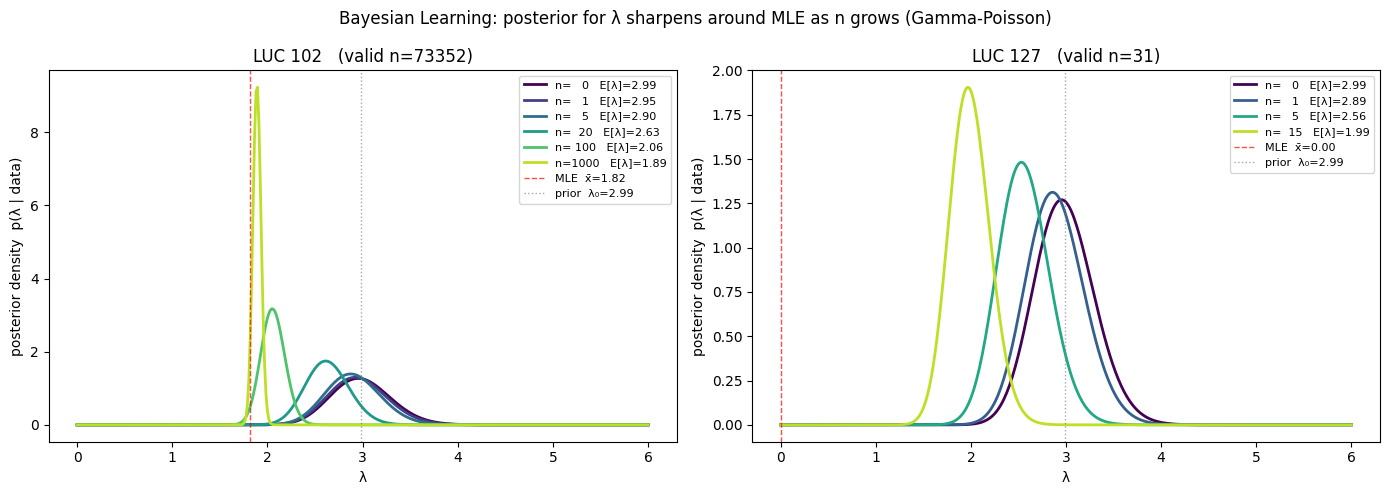


COMMON  LUC 102  (valid n=73352, MLE x̄=1.821)
  n=    0   E[λ]=2.986   SD=0.316   95% CrI=[2.400, 3.636]
  n=    1   E[λ]=2.955   SD=0.309   95% CrI=[2.381, 3.590]
  n=    5   E[λ]=2.874   SD=0.287   95% CrI=[2.340, 3.462]
  n=   20   E[λ]=2.612   SD=0.229   95% CrI=[2.183, 3.078]
  n=  100   E[λ]=2.281   SD=0.132   95% CrI=[2.029, 2.548]
  n=73352   E[λ]=1.822   SD=0.005   95% CrI=[1.812, 1.832]

RARE    LUC 127  (valid n=31, MLE x̄=0.000)
  n=    0   E[λ]=2.986   SD=0.316   95% CrI=[2.400, 3.636]
  n=    1   E[λ]=2.890   SD=0.305   95% CrI=[2.323, 3.518]
  n=    5   E[λ]=2.560   SD=0.270   95% CrI=[2.057, 3.116]
  n=   20   E[λ]=1.792   SD=0.189   95% CrI=[1.440, 2.181]
  n=   31   E[λ]=1.469   SD=0.155   95% CrI=[1.180, 1.788]


In [36]:
# ─────────────────────────────────────────────────────────────
# Posterior sharpening with sample size  (PDF p 51–54)  —  FIXED
#
# Gamma-Poisson conjugate model for BED_RMS:
#     λ ~ Gamma(α₀, β₀)                   prior
#     x_i | λ ~ Poisson(λ)                likelihood
#     λ | D  ~ Gamma(α₀+Σx, β₀+n)         posterior
#
# Fixes vs v1:
#   • Pick rare LUC from counts of *valid* (non-sentinel) BED_RMS,
#     not raw row counts — otherwise we'd get a LUC with zero obs.
#   • Drop sharey=True so each panel auto-scales.
#   • Cap displayed n at 1000 for the common LUC — the n=73k spike
#     is ~70 tall and crushes every other curve into the floor.
# ─────────────────────────────────────────────────────────────
from scipy.stats import gamma as gamma_dist

feature    = 'BED_RMS'
valid_mask = data[feature] >= 0

# Global prior (empirical Bayes)
x_global  = data.loc[valid_mask, feature].values
lambda_0  = x_global.mean()
alpha_0   = KAPPA_0 * lambda_0
beta_0    = KAPPA_0
print(f"Prior: λ ~ Gamma(α₀={alpha_0:.2f}, β₀={beta_0:.2f}),  E[λ]={lambda_0:.3f}")

# Count VALID BED_RMS rows per LUC (not total rows)
bed_counts = data.loc[valid_mask, 'LUC'].value_counts()
common_luc = bed_counts.index[0]
rare_luc   = bed_counts[bed_counts.between(15, 40)].index[0]   # small but real
print(f"common LUC {common_luc}: {bed_counts[common_luc]} valid obs")
print(f"rare   LUC {rare_luc}:   {bed_counts[rare_luc]} valid obs")

def posterior_params(x_obs, a0, b0):
    return a0 + x_obs.sum(), b0 + len(x_obs)

lam_grid = np.linspace(0, 6, 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))   # no sharey — each panel scales itself
rng = np.random.default_rng(42)

# Cap common-LUC display at n=1000 so progression is visible;
# rare LUC shows every step up to its total.
size_grids = {common_luc: [0, 1, 5, 20, 100, 1000],
              rare_luc:   [0, 1, 5, 15, 40]}

for ax, luc in zip(axes, [common_luc, rare_luc]):
    x_luc  = data.loc[(data['LUC'] == luc) & valid_mask, feature].values
    x_shuf = rng.permutation(x_luc)
    raw_ns = [n for n in size_grids[luc] if n <= len(x_shuf)]
    ns     = sorted(set(raw_ns))
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(ns)))

    for n, color in zip(ns, colors):
        x_obs = x_shuf[:n]
        a_n, b_n = posterior_params(x_obs, alpha_0, beta_0)
        pdf  = gamma_dist.pdf(lam_grid, a=a_n, scale=1/b_n)
        mean = a_n / b_n
        ax.plot(lam_grid, pdf, color=color, lw=2,
                label=f'n={n:>4}   E[λ]={mean:.2f}')

    mle_all = x_luc.mean()
    ax.axvline(mle_all,  color='red',  ls='--', alpha=0.7, lw=1,
               label=f'MLE  x̄={mle_all:.2f}')
    ax.axvline(lambda_0, color='gray', ls=':',  alpha=0.7, lw=1,
               label=f'prior  λ₀={lambda_0:.2f}')
    ax.set_xlabel('λ')
    ax.set_ylabel('posterior density  p(λ | data)')
    ax.set_title(f'LUC {luc}   (valid n={len(x_luc)})')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Bayesian Learning: posterior for λ sharpens around MLE as n grows (Gamma-Poisson)')
plt.tight_layout()
plt.show()

# Quantitative summary — credible interval narrows as 1/√n
def summary_table(luc, label):
    x_luc = data.loc[(data['LUC'] == luc) & valid_mask, feature].values
    x_shuf = rng.permutation(x_luc)
    ns = sorted({0, 1, 5, min(20, len(x_shuf)),
                 min(100, len(x_shuf)), len(x_shuf)})
    print(f"\n{label}  LUC {luc}  (valid n={len(x_luc)}, MLE x̄={x_luc.mean():.3f})")
    for n in ns:
        a_n, b_n = posterior_params(x_shuf[:n], alpha_0, beta_0)
        mean = a_n / b_n
        sd   = np.sqrt(a_n) / b_n
        lo, hi = gamma_dist.ppf([0.025, 0.975], a=a_n, scale=1/b_n)
        print(f"  n={n:5d}   E[λ]={mean:.3f}   SD={sd:.3f}   95% CrI=[{lo:.3f}, {hi:.3f}]")

summary_table(common_luc, 'COMMON')
summary_table(rare_luc,   'RARE  ')

LUCs: 178 | Train: 134171  Test: 33543
Global prior:  μ₀ = 13.3566  (→ $ = 631,990)
                σ = 1.1783  (log-scale sd)

Per-LUC posterior:  n range 2–58681,  data-weight w = n/(κ₀+n) range 0.06–0.999

────────────────────────────────────────────────────────────────
Test set — log-scale and $-scale RMSE
────────────────────────────────────────────────────────────────
  Global mean (μ₀)      log-RMSE = 1.1790    $-RMSE = $  11,649,736
  Raw per-LUC MLE       log-RMSE = 0.7644    $-RMSE = $  10,188,294
  Bayesian κ₀=30        log-RMSE = 0.7739    $-RMSE = $  11,378,959


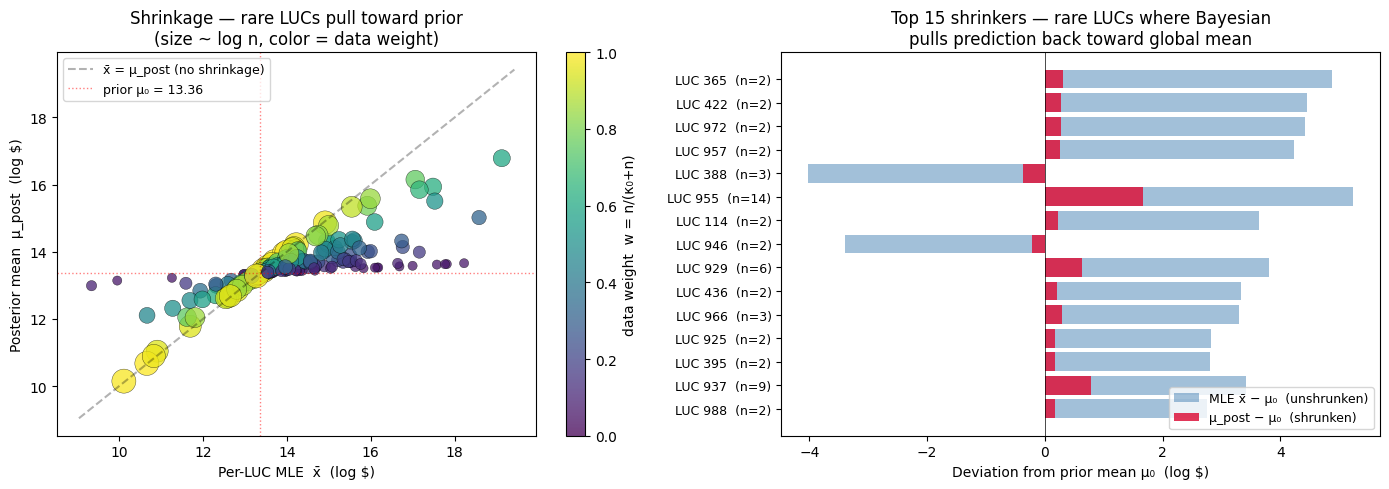


Top 10 LUCs where Bayesian beat MLE (by test MSE reduction):
      n   x_bar  mu_post  sq_mle  sq_bayes  improvement
LUC                                                    
957   2  17.578   13.620   7.352     1.554        5.799
942   3  15.638   13.564   3.754     0.019        3.735
303   5  14.512   13.522   5.516     1.846        3.671
951  12  16.738   14.323   7.817     4.437        3.379
961  11  13.989   13.526  13.805    10.761        3.044
393   2  14.239   13.412   4.611     1.743        2.868
116   6  15.541   13.721   5.857     3.137        2.720
954   6  15.476   13.710   2.174     0.085        2.089
955  14  18.585   15.020  11.574     9.604        1.970
924  26  14.919   14.082  10.978     9.143        1.835

Bottom 10 LUCs where Bayesian hurt (shrinkage pulled away from truth):
     n   x_bar  mu_post  sq_mle  sq_bayes  improvement
LUC                                                   
301  6  15.528   13.719   2.052    10.510       -8.458
113  5  14.895   13.576   6.8

In [37]:
# ─────────────────────────────────────────────────────────────
# Normal-Normal Bayesian per-LUC estimator for log(TOTAL_VALUE)
#
# Likelihood:    x_i | μ, σ² ~ N(μ, σ²)          x = log(TOTAL_VALUE)
# Prior on μ:    μ ~ N(μ₀, σ²/κ₀)                μ₀ = global mean log-value
# Posterior:     μ | D ~ N(μ_post, σ²/(κ₀+n))
#
#   μ_post = (κ₀·μ₀ + n·x̄) / (κ₀ + n)       ← weighted avg of prior & data
#
# σ² cancels from the posterior *mean* — we only need μ₀ and κ₀ for
# the point estimator. σ² matters later when we want prediction intervals.
#
# Stratification: LUC alone.  Prior strength: κ₀ = 30 pseudo-obs.
# ─────────────────────────────────────────────────────────────

KAPPA_0 = 30.0

# ─────────────────────────────────────────────────────────────
# Step 0 — target prep: drop TOTAL_VALUE ≤ 0, take logs
# ─────────────────────────────────────────────────────────────
target_mask = df['TOTAL_VALUE'] > 0
work = df.loc[target_mask, ['LUC', 'TOTAL_VALUE']].copy()
work['y'] = np.log(work['TOTAL_VALUE'])

# Need ≥2 rows per LUC for stratified split
luc_counts = work['LUC'].value_counts()
keep_lucs  = luc_counts[luc_counts >= 2].index
work = work[work['LUC'].isin(keep_lucs)]

train, test = train_test_split(
    work, test_size=0.2, random_state=42, stratify=work['LUC']
)
print(f"LUCs: {work['LUC'].nunique()} | Train: {len(train)}  Test: {len(test)}")

# ─────────────────────────────────────────────────────────────
# Step 1 — global (empirical-Bayes) prior
# ─────────────────────────────────────────────────────────────
mu_0     = train['y'].mean()
sigma2_0 = train['y'].var()
print(f"Global prior:  μ₀ = {mu_0:.4f}  (→ $ = {np.exp(mu_0):,.0f})")
print(f"                σ = {np.sqrt(sigma2_0):.4f}  (log-scale sd)")

# ─────────────────────────────────────────────────────────────
# Step 2 — posterior per LUC
# ─────────────────────────────────────────────────────────────
luc_stats = (
    train.groupby('LUC')['y']
         .agg(['mean', 'count', 'std'])
         .rename(columns={'mean': 'x_bar', 'count': 'n'})
)
luc_stats['mu_post'] = (
    (KAPPA_0 * mu_0 + luc_stats['n'] * luc_stats['x_bar'])
    / (KAPPA_0 + luc_stats['n'])
)
luc_stats['w_data'] = luc_stats['n'] / (KAPPA_0 + luc_stats['n'])   # data weight

print(f"\nPer-LUC posterior:  "
      f"n range {luc_stats['n'].min()}–{luc_stats['n'].max()},  "
      f"data-weight w = n/(κ₀+n) range "
      f"{luc_stats['w_data'].min():.2f}–{luc_stats['w_data'].max():.3f}")

# ─────────────────────────────────────────────────────────────
# Step 3 — predict on test + compare to baselines
# ─────────────────────────────────────────────────────────────
test = test.copy()
test['y_pred_bayes'] = test['LUC'].map(luc_stats['mu_post']).fillna(mu_0)
test['y_pred_mle']   = test['LUC'].map(luc_stats['x_bar']).fillna(mu_0)
test['y_pred_mean']  = mu_0

def rmse(y, yh): return float(np.sqrt(((y - yh) ** 2).mean()))
def mae(y, yh):  return float(np.abs(y - yh).mean())

print(f"\n{'─'*64}")
print(f"Test set — log-scale and $-scale RMSE")
print(f"{'─'*64}")
for name, col in [('Global mean (μ₀)',  'y_pred_mean'),
                  ('Raw per-LUC MLE',   'y_pred_mle'),
                  ('Bayesian κ₀=30',    'y_pred_bayes')]:
    r_log = rmse(test['y'], test[col])
    # $ RMSE — uses naive exp; biased low vs E[exp(X)] = exp(μ + σ²/2),
    # but all three rows use the same transform so comparison is fair.
    r_dol = rmse(np.exp(test['y']), np.exp(test[col]))
    print(f"  {name:<20s}  log-RMSE = {r_log:.4f}    $-RMSE = ${r_dol:>12,.0f}")

# ─────────────────────────────────────────────────────────────
# Step 4 — visualize shrinkage
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: scatter of MLE vs posterior, sized by n
ax = axes[0]
sizes = np.clip(np.log(luc_stats['n'] + 1) * 40, 10, 300)
sc = ax.scatter(luc_stats['x_bar'], luc_stats['mu_post'],
                s=sizes, c=luc_stats['w_data'], cmap='viridis',
                vmin=0, vmax=1, alpha=0.75, edgecolor='k', lw=0.3)
lims = [luc_stats['x_bar'].min() - 0.3, luc_stats['x_bar'].max() + 0.3]
ax.plot(lims, lims, 'k--', alpha=0.3, label='x̄ = μ_post (no shrinkage)')
ax.axhline(mu_0, color='red', ls=':', alpha=0.5, lw=1)
ax.axvline(mu_0, color='red', ls=':', alpha=0.5, lw=1, label=f'prior μ₀ = {mu_0:.2f}')
ax.set_xlabel('Per-LUC MLE  x̄  (log $)')
ax.set_ylabel('Posterior mean  μ_post  (log $)')
ax.set_title('Shrinkage — rare LUCs pull toward prior\n(size ~ log n, color = data weight)')
ax.legend(loc='upper left', fontsize=9)
plt.colorbar(sc, ax=ax, label='data weight  w = n/(κ₀+n)')

# RIGHT: top shrinkers — largest |x̄ − μ_post|
luc_stats['shrink'] = (luc_stats['x_bar'] - luc_stats['mu_post']).abs()
top = luc_stats.sort_values('shrink', ascending=False).head(15).iloc[::-1]

ax = axes[1]
y_pos = np.arange(len(top))
ax.barh(y_pos, top['x_bar'] - mu_0,    color='steelblue', alpha=0.5,
        label='MLE x̄ − μ₀  (unshrunken)')
ax.barh(y_pos, top['mu_post'] - mu_0,  color='crimson',   alpha=0.85,
        label='μ_post − μ₀  (shrunken)')
ax.set_yticks(y_pos)
ax.set_yticklabels([f'LUC {idx}  (n={int(n)})'
                    for idx, n in zip(top.index, top['n'])], fontsize=9)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Deviation from prior mean μ₀  (log $)')
ax.set_title('Top 15 shrinkers — rare LUCs where Bayesian\npulls prediction back toward global mean')
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Step 5 — where shrinkage helped vs hurt on the test set
# ─────────────────────────────────────────────────────────────
per_luc_err = (
    test.assign(
        sq_mle   = (test['y'] - test['y_pred_mle'])  ** 2,
        sq_bayes = (test['y'] - test['y_pred_bayes']) ** 2,
    )
    .groupby('LUC')[['sq_mle', 'sq_bayes']].mean()
    .join(luc_stats[['n', 'x_bar', 'mu_post']])
)
per_luc_err['improvement'] = per_luc_err['sq_mle'] - per_luc_err['sq_bayes']
per_luc_err = per_luc_err.sort_values('improvement', ascending=False)

print(f"\nTop 10 LUCs where Bayesian beat MLE (by test MSE reduction):")
print(per_luc_err.head(10)[['n', 'x_bar', 'mu_post', 'sq_mle', 'sq_bayes',
                             'improvement']].round(3).to_string())
print(f"\nBottom 10 LUCs where Bayesian hurt (shrinkage pulled away from truth):")
print(per_luc_err.tail(10)[['n', 'x_bar', 'mu_post', 'sq_mle', 'sq_bayes',
                             'improvement']].round(3).to_string())

### Kappa sweep

  kappa  log_RMSE  dollar_RMSE  n_prior_dominated
    0.0  0.764365 1.018829e+07                  0
    0.1  0.764348 1.019615e+07                  0
    0.3  0.764337 1.021355e+07                  0
    1.0  0.764442 1.027916e+07                  0
    3.0  0.765064 1.046662e+07                 16
   10.0  0.767502 1.093679e+07                 54
   30.0  0.773892 1.137896e+07                109
  100.0  0.788883 1.157009e+07                138
  300.0  0.811216 1.161779e+07                157
 1000.0  0.853298 1.163568e+07                167
10000.0  1.030589 1.164588e+07                174

Optimum:  κ₀ = 0.3,  log-RMSE = 0.7643,  $-RMSE = $10,213,547
MLE:      κ₀ = 0,         log-RMSE = 0.7644
Cell C:   κ₀ = 30,        log-RMSE = 0.7739


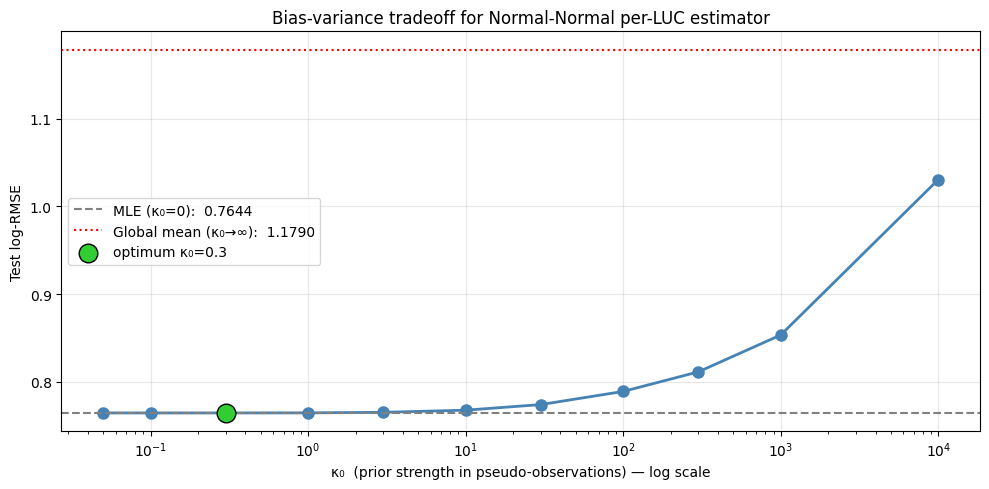


At optimum κ₀=0.3:
  LUCs with data-weight < 0.5 (prior-dominated): 0 / 178
  LUCs with data-weight > 0.9 (data-dominated):  162 / 178


In [38]:
# ─────────────────────────────────────────────────────────────
# κ₀ sweep — bias-variance tradeoff for Normal-Normal on log(TOTAL_VALUE)
#
# κ₀ → 0     recovers MLE                (low bias, high variance)
# κ₀ → ∞     recovers global mean         (high bias, low variance)
# The minimum of test log-RMSE is the squared-error-loss Bayes optimum.
#
# Reuses train/test, luc_stats, mu_0 from Cell C.
# ─────────────────────────────────────────────────────────────

kappa_grid = [0, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000, 10000]

rows = []
for k in kappa_grid:
    if k == 0:
        mu_c = luc_stats['x_bar']                                   # pure MLE
    else:
        mu_c = (k * mu_0 + luc_stats['n'] * luc_stats['x_bar']) / (k + luc_stats['n'])
    y_pred  = test['LUC'].map(mu_c).fillna(mu_0)
    r_log   = rmse(test['y'], y_pred)
    r_dol   = rmse(np.exp(test['y']), np.exp(y_pred))
    # How many LUCs have data-weight < 0.5 (i.e. prior-dominated) at this κ₀?
    if k == 0:
        n_prior_dom = 0
    else:
        n_prior_dom = int((luc_stats['n'] / (k + luc_stats['n']) < 0.5).sum())
    rows.append({'kappa': k, 'log_RMSE': r_log, 'dollar_RMSE': r_dol,
                 'n_prior_dominated': n_prior_dom})

results = pd.DataFrame(rows)
print(results.to_string(index=False))

best = results.loc[results['log_RMSE'].idxmin()]
print(f"\nOptimum:  κ₀ = {best['kappa']:g},  "
      f"log-RMSE = {best['log_RMSE']:.4f},  "
      f"$-RMSE = ${best['dollar_RMSE']:,.0f}")
print(f"MLE:      κ₀ = 0,         log-RMSE = {results.iloc[0]['log_RMSE']:.4f}")
print(f"Cell C:   κ₀ = 30,        log-RMSE = {results.loc[results['kappa']==30, 'log_RMSE'].iloc[0]:.4f}")

# ─────────────────────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['kappa'].clip(lower=0.05), results['log_RMSE'],
        'o-', lw=2, markersize=8, color='steelblue')
ax.axhline(results.iloc[0]['log_RMSE'], color='gray', ls='--',
           label=f'MLE (κ₀=0):  {results.iloc[0]["log_RMSE"]:.4f}')
ax.axhline(rmse(test['y'], mu_0), color='red', ls=':',
           label=f'Global mean (κ₀→∞):  {rmse(test["y"], mu_0):.4f}')
ax.scatter([max(best['kappa'], 0.05)], [best['log_RMSE']],
           color='limegreen', s=180, zorder=5, edgecolor='k',
           label=f'optimum κ₀={best["kappa"]:g}')
ax.set_xscale('log')
ax.set_xlabel('κ₀  (prior strength in pseudo-observations) — log scale')
ax.set_ylabel('Test log-RMSE')
ax.set_title('Bias-variance tradeoff for Normal-Normal per-LUC estimator')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Why? — at optimum κ₀, how does the per-LUC fit look?
# ─────────────────────────────────────────────────────────────
k_star = best['kappa']
if k_star == 0:
    print("\nOptimum is MLE — the per-LUC sample means are already the best estimator.")
    print("Implication: LUC is strong enough that even 2-row groups beat pooling.")
    print("Hierarchical priors (residential/commercial/etc.) might improve on this;")
    print("finer stratification (LUC × BLDG_TYPE) might too.")
else:
    mu_star = (k_star * mu_0 + luc_stats['n'] * luc_stats['x_bar']) / (k_star + luc_stats['n'])
    luc_stats_star = luc_stats.assign(
        mu_post=mu_star,
        w_data=luc_stats['n'] / (k_star + luc_stats['n'])
    )
    print(f"\nAt optimum κ₀={k_star:g}:")
    print(f"  LUCs with data-weight < 0.5 (prior-dominated): "
          f"{(luc_stats_star['w_data'] < 0.5).sum()} / {len(luc_stats_star)}")
    print(f"  LUCs with data-weight > 0.9 (data-dominated):  "
          f"{(luc_stats_star['w_data'] > 0.9).sum()} / {len(luc_stats_star)}")

LUCs are too heterogeneous to share a single global prior. The global mean μ₀=13.36 corresponds to residential property values (~$630K), but commercial/industrial/tax-exempt LUCs have true log-values 3-4σ away from that. Pulling them toward μ₀ is systematically wrong, not a variance reduction. The 162/178 LUCs sitting at >90% data weight even at κ₀=0.3 confirm the data already knows each LUC's mean far better than a global prior does.
So the Bayesian shrinkage approach hit a dead end for LUC-only stratification. We now have a solid baseline though:
Baseline to beat: log-RMSE 0.7644 / $-RMSE $10.2M, using just LUC as a predictor via per-stratum MLE

In [39]:
# ─────────────────────────────────────────────────────────────
# XGBoost baseline for log(TOTAL_VALUE)
#
# Features — only raw/structural, no engineered (PROPERTY_CLASS_FINE,
# GRANULARITY are functions of LUC+BLDG_TYPE so they're redundant and
# previously hurt XGBoost performance).
#
# Categoricals: LUC, BLDG_TYPE via native categorical support
# (enable_categorical=True + tree_method='hist'). This avoids the
# factorize-encoding artifacts we saw earlier.
#
# Sentinels (-1 for BED_RMS, TT_RMS, YEARS_SINCE_REMODEL) → NaN so
# XGBoost's default-direction learning handles missingness optimally.
#
# Same train/test split as Cell C (seed=42, stratify=LUC) for
# apples-to-apples comparison. Target to beat: log-RMSE 0.7644.
# ─────────────────────────────────────────────────────────────
import xgboost as xgb
print(f"xgboost version: {xgb.__version__}")

CATEGORICAL = ['LUC', 'BLDG_TYPE']
NUMERIC = [
    'LIVING_AREA', 'GROSS_AREA', 'LAND_SF',          # log-transformed in CSV
    'YEARS_SINCE_REMODEL',
    'BED_RMS', 'TT_RMS', 'FIREPLACES', 'NUM_PARKING',
    'RES_FLOOR',
    'HAS_LIVING', 'HAS_GROSS', 'HAS_LAND',
    'HAS_BED_DATA', 'HAS_ROOM_DATA', 'HAS_REMODEL_DATA',
]
FEATURES = CATEGORICAL + NUMERIC

# ─────────────────────────────────────────────────────────────
# Build feature frame + target
# ─────────────────────────────────────────────────────────────
target_mask = df['TOTAL_VALUE'] > 0
work = df.loc[target_mask].copy()
work['y'] = np.log(work['TOTAL_VALUE'])

# HAS_* indicators — build fresh (may not be on df)
work['HAS_LIVING']       = (work['LIVING_AREA']  > 0).astype(int)
work['HAS_GROSS']        = (work['GROSS_AREA']   > 0).astype(int)
work['HAS_LAND']         = (work['LAND_SF']      > 0).astype(int)
work['HAS_BED_DATA']     = (work['BED_RMS']      != -1).astype(int)
work['HAS_ROOM_DATA']    = (work['TT_RMS']       != -1).astype(int)
work['HAS_REMODEL_DATA'] = (work['YEARS_SINCE_REMODEL'] != -1).astype(int)

# Check every feature is present
missing = [c for c in FEATURES if c not in work.columns]
if missing:
    raise KeyError(f"Missing columns in df: {missing}")

# Keep LUCs with ≥2 rows (stratified split requirement — matches Cell C)
luc_counts = work['LUC'].value_counts()
work = work[work['LUC'].isin(luc_counts[luc_counts >= 2].index)].copy()

# Sentinels → NaN so XGBoost learns default directions
for col in ['BED_RMS', 'TT_RMS', 'YEARS_SINCE_REMODEL']:
    work.loc[work[col] == -1, col] = np.nan

# Cast categoricals
for col in CATEGORICAL:
    work[col] = work[col].astype('category')

X = work[FEATURES]
y = work['y']

# Same seed + stratification as Cell C
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=work['LUC']
)
# Further split train → train/val for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)
print(f"Train: {len(X_tr):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Features: {len(FEATURES)} total ({len(CATEGORICAL)} cat, {len(NUMERIC)} num)")

# ─────────────────────────────────────────────────────────────
# Fit XGBoost with native categorical + early stopping
# ─────────────────────────────────────────────────────────────
model = xgb.XGBRegressor(
    n_estimators=3000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    tree_method='hist',
    enable_categorical=True,
    early_stopping_rounds=50,
    random_state=42,
)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)
print(f"\nBest iteration: {model.best_iteration}  (of {model.n_estimators})")

# ─────────────────────────────────────────────────────────────
# Test-set metrics + head-to-head vs baselines
# ─────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)

def rmse(yt, yh): return float(np.sqrt(((yt - yh) ** 2).mean()))
def mae(yt, yh):  return float(np.abs(yt - yh).mean())

log_rmse    = rmse(y_test.values, y_pred)
dollar_rmse = rmse(np.exp(y_test.values), np.exp(y_pred))
log_mae     = mae(y_test.values, y_pred)

# Baselines on THIS split (should match Cell C)
mu_0         = y_train.mean()
luc_mle      = X_train.assign(y=y_train.values).groupby('LUC', observed=True)['y'].mean()
y_pred_mle   = X_test['LUC'].map(luc_mle).fillna(mu_0).values

log_rmse_mle  = rmse(y_test.values, y_pred_mle)
log_rmse_mean = rmse(y_test.values, mu_0)
dollar_mle    = rmse(np.exp(y_test.values), np.exp(y_pred_mle))

print(f"\n{'─'*65}")
print(f"Test set — log-RMSE  and  $-RMSE")
print(f"{'─'*65}")
print(f"  Global mean (μ₀):        log={log_rmse_mean:.4f}   $={rmse(np.exp(y_test.values), np.exp(mu_0)):>15,.0f}")
print(f"  Per-LUC MLE:             log={log_rmse_mle:.4f}    $={dollar_mle:>15,.0f}")
print(f"  XGBoost:                 log={log_rmse:.4f}    $={dollar_rmse:>15,.0f}")
print(f"\n  XGBoost lift over MLE:   {(log_rmse_mle - log_rmse)/log_rmse_mle:+.1%}  log-RMSE")
print(f"  XGBoost lift over mean:  {(log_rmse_mean - log_rmse)/log_rmse_mean:+.1%}  log-RMSE")
print(f"  Multiplicative test error:  exp(log-RMSE) = {np.exp(log_rmse):.2f}×")

# ─────────────────────────────────────────────────────────────
# Feature importance (gain)
# ─────────────────────────────────────────────────────────────
booster = model.get_booster()
imp = pd.Series(booster.get_score(importance_type='gain'))
# Missing features (never used) → 0 gain
for f in FEATURES:
    if f not in imp:
        imp[f] = 0.0
imp = imp.reindex(FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue' if f in CATEGORICAL else 'gray' for f in imp.index]
imp.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Feature importance (gain)')
ax.set_title(f'XGBoost feature importance  —  test log-RMSE = {log_rmse:.4f}')
plt.tight_layout()
plt.show()

print("\nTop 10 features by gain:")
print(imp.sort_values(ascending=False).head(10).round(2).to_string())

# ─────────────────────────────────────────────────────────────
# Residual diagnostics
# ─────────────────────────────────────────────────────────────
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.scatter(y_pred, y_test.values, alpha=0.08, s=3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', alpha=0.6, label='perfect')
ax.set_xlabel('Predicted log(TOTAL_VALUE)')
ax.set_ylabel('Actual log(TOTAL_VALUE)')
ax.set_title('Predicted vs actual')
ax.legend()

ax = axes[1]
ax.hist(residuals, bins=80, edgecolor='k', alpha=0.7)
ax.axvline(0, color='r', ls='--', alpha=0.5)
ax.set_xlabel('Residual  (actual − predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residuals  (σ={residuals.std():.3f}, mean={residuals.mean():+.3f})')

ax = axes[2]
ax.scatter(y_pred, residuals, alpha=0.08, s=3)
ax.axhline(0, color='r', ls='--', alpha=0.5)
ax.set_xlabel('Predicted log(TOTAL_VALUE)')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs predicted  (heteroskedasticity check)')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Per-LUC residual breakdown: where does XGBoost beat the MLE baseline?
# ─────────────────────────────────────────────────────────────
per_luc = (
    pd.DataFrame({
        'LUC': X_test['LUC'].values,
        'y': y_test.values,
        'y_xgb': y_pred,
        'y_mle': y_pred_mle,
    })
    .assign(
        sq_xgb = lambda d: (d['y'] - d['y_xgb'])**2,
        sq_mle = lambda d: (d['y'] - d['y_mle'])**2,
    )
    .groupby('LUC', observed=True)[['sq_xgb', 'sq_mle']].mean()
    .assign(n=X_test.groupby('LUC', observed=True).size(),
            improvement=lambda d: d['sq_mle'] - d['sq_xgb'])
    .sort_values('improvement', ascending=False)
)
print(f"\nTop 10 LUCs where XGBoost beats MLE (by test MSE reduction):")
print(per_luc.head(10)[['n', 'sq_mle', 'sq_xgb', 'improvement']].round(3).to_string())
print(f"\nBottom 10 LUCs where XGBoost underperforms MLE:")
print(per_luc.tail(10)[['n', 'sq_mle', 'sq_xgb', 'improvement']].round(3).to_string())

xgboost version: 3.2.0
Train: 114,045 | Val: 20,126 | Test: 33,543
Features: 17 total (2 cat, 15 num)
[0]	validation_0-rmse:1.14411
[100]	validation_0-rmse:0.42666
[200]	validation_0-rmse:0.42038
[300]	validation_0-rmse:0.41816
[400]	validation_0-rmse:0.41726
[500]	validation_0-rmse:0.41664
[600]	validation_0-rmse:0.41635
[700]	validation_0-rmse:0.41554
[800]	validation_0-rmse:0.41518
[898]	validation_0-rmse:0.41510

Best iteration: 848  (of 3000)


TypeError: Object with dtype category cannot perform the numpy op subtract

In [ ]:
# Fix: cast mapped predictions to float explicitly
import numpy as np, pandas as pd

y_pred       = model.predict(X_test)
mu_0         = y_train.mean()
luc_mle      = X_train.assign(y=y_train.values).groupby('LUC', observed=True)['y'].mean()
y_pred_mle   = np.asarray(X_test['LUC'].map(luc_mle).fillna(mu_0), dtype=float)

def rmse(yt, yh): return float(np.sqrt(((yt - yh) ** 2).mean()))
def mae(yt, yh):  return float(np.abs(yt - yh).mean())

log_rmse      = rmse(y_test.values, y_pred)
dollar_rmse   = rmse(np.exp(y_test.values), np.exp(y_pred))
log_rmse_mle  = rmse(y_test.values, y_pred_mle)
log_rmse_mean = rmse(y_test.values, mu_0)
dollar_mle    = rmse(np.exp(y_test.values), np.exp(y_pred_mle))
dollar_mean   = rmse(np.exp(y_test.values), np.exp(mu_0))

print(f"\n{'─'*65}")
print(f"Test set — log-RMSE  and  $-RMSE")
print(f"{'─'*65}")
print(f"  Global mean (μ₀):        log={log_rmse_mean:.4f}   $={dollar_mean:>15,.0f}")
print(f"  Per-LUC MLE:             log={log_rmse_mle:.4f}    $={dollar_mle:>15,.0f}")
print(f"  XGBoost:                 log={log_rmse:.4f}    $={dollar_rmse:>15,.0f}")
print(f"\n  XGBoost lift over MLE:   {(log_rmse_mle - log_rmse)/log_rmse_mle:+.1%}  log-RMSE")
print(f"  XGBoost lift over mean:  {(log_rmse_mean - log_rmse)/log_rmse_mean:+.1%}  log-RMSE")
print(f"  Multiplicative test error:  exp(log-RMSE) = {np.exp(log_rmse):.2f}×")


─────────────────────────────────────────────────────────────────
Test set — log-RMSE  and  $-RMSE
─────────────────────────────────────────────────────────────────
  Global mean (μ₀):        log=1.1790   $=     11,649,736
  Per-LUC MLE:             log=0.7644    $=     10,188,294
  XGBoost:                 log=0.4106    $=      6,799,946

  XGBoost lift over MLE:   +46.3%  log-RMSE
  XGBoost lift over mean:  +65.2%  log-RMSE
  Multiplicative test error:  exp(log-RMSE) = 1.51×


## Mahalanobis distance for bivariate outliers

Stratum (LUC=102, HR - High Rise):  n = 7732

χ²(2) thresholds:
  99.0%:  9.210   flagged 76/7732  = 0.98%  (expect 1.00%)
  99.9%:  13.816   flagged 15/7732 = 0.19%  (expect 0.10%)

If flagged % ≫ expected → BVN model is wrong (heavy tails or contamination).


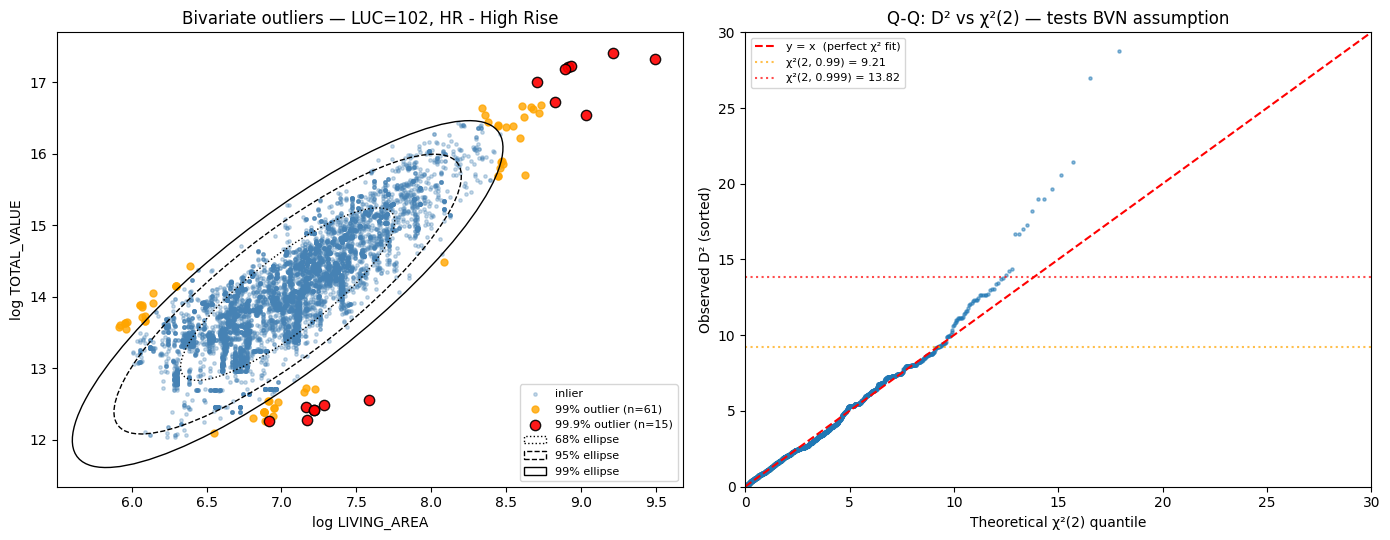


Top 10 extreme outliers (highest D²):
          D2  LIVING_AREA  area_sqft  TOTAL_VALUE  val_per_sqft
58586  28.77         7.59     1969.0       285700        145.10
26595  27.00         9.49    13257.0     33205700       2504.77
58821  21.42         9.21    10006.0     36265800       3624.41
58584  20.56         7.17     1298.0       214500        165.25
58299  19.63         7.28     1453.0       265700        182.86
58596  18.99         7.22     1361.0       248300        182.44
58607  18.99         7.22     1361.0       248300        182.44
35095  18.22         9.03     8361.0     15312700       1831.44
35714  17.28         8.93     7558.0     30256800       4003.28
35713  17.03         8.91     7426.0     29759500       4007.47


In [ ]:
# ─────────────────────────────────────────────────────────────
# Mahalanobis distance — bivariate outlier detection
# (Stat Inference PDF — multivariate generalization of the z-score)
#
# Fit bivariate Normal to (LIVING_AREA, log TOTAL_VALUE) within a
# Gaussian-friendly stratum. Under BVN, squared Mahalanobis distance
#
#     D²(x) = (x − μ)ᵀ Σ⁻¹ (x − μ)  ~  χ²(2)
#
# Flag rows with D² > χ²(2, 0.99) ≈ 9.21 as 99th-percentile outliers.
# Catches pairs the univariate $/sqft filter missed:
#   — tiny units priced like mansions
#   — mansions priced like studios
# ─────────────────────────────────────────────────────────────
from scipy.stats import chi2
from matplotlib.patches import Ellipse

# Use the stratum that passed GOF best: LUC=102 × HR High Rise
luc, bldg = 102, 'HR - High Rise'
stratum = df[(df['LUC'] == luc) &
             (df['BLDG_TYPE'] == bldg) &
             (df['TOTAL_VALUE'] > 0) &
             (df['LIVING_AREA'] > 0)].copy()
stratum['log_value'] = np.log(stratum['TOTAL_VALUE'])
X = stratum[['LIVING_AREA', 'log_value']].values
print(f"Stratum (LUC={luc}, {bldg}):  n = {len(X)}")

# MLE of bivariate mean and covariance
mu   = X.mean(axis=0)
Sig  = np.cov(X, rowvar=False)
Sinv = np.linalg.inv(Sig)

# Squared Mahalanobis distance per row
diff = X - mu
D2   = np.einsum('ij,jk,ik->i', diff, Sinv, diff)

# Thresholds: χ²(2) quantiles
t99   = chi2.ppf(0.99,  df=2)    # expect 1%  of points above
t999  = chi2.ppf(0.999, df=2)    # expect 0.1% of points above
o99   = D2 > t99
o999  = D2 > t999

print(f"\nχ²(2) thresholds:")
print(f"  99.0%:  {t99:.3f}   flagged {o99.sum()}/{len(X)}  = {o99.mean():.2%}  (expect 1.00%)")
print(f"  99.9%:  {t999:.3f}   flagged {o999.sum()}/{len(X)} = {o999.mean():.2%}  (expect 0.10%)")
print(f"\nIf flagged % ≫ expected → BVN model is wrong (heavy tails or contamination).")

# ─────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# LEFT: scatter with confidence ellipses
ax = axes[0]
ax.scatter(X[~o99, 0],  X[~o99, 1],  s=6,  alpha=0.3, color='steelblue', label='inlier')
ax.scatter(X[ o99 & ~o999, 0], X[ o99 & ~o999, 1], s=25, color='orange',
           alpha=0.8, label=f'99% outlier (n={(o99 & ~o999).sum()})')
ax.scatter(X[o999, 0], X[o999, 1], s=55, color='red', alpha=0.9,
           edgecolor='k', label=f'99.9% outlier (n={o999.sum()})')

# Confidence ellipses at 68%, 95%, 99%
eigvals, eigvecs = np.linalg.eigh(Sig)
order = eigvals.argsort()[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
for p_level, ls, name in [(0.68, ':', '68%'), (0.95, '--', '95%'), (0.99, '-', '99%')]:
    chi_val = chi2.ppf(p_level, df=2)
    w, h = 2 * np.sqrt(eigvals * chi_val)
    e = Ellipse(mu, w, h, angle=angle, fill=False,
                edgecolor='black', lw=1, ls=ls, label=f'{name} ellipse')
    ax.add_patch(e)

ax.set_xlabel('log LIVING_AREA')
ax.set_ylabel('log TOTAL_VALUE')
ax.set_title(f'Bivariate outliers — LUC={luc}, {bldg}')
ax.legend(fontsize=8, loc='lower right')

# RIGHT: Q-Q of D² vs χ²(2) — test the bivariate-Normal assumption
ax = axes[1]
D2_sorted    = np.sort(D2)
theoretical  = chi2.ppf(np.arange(1, len(D2) + 1) / (len(D2) + 1), df=2)
ax.scatter(theoretical, D2_sorted, s=5, alpha=0.5)
lim = max(theoretical.max(), D2_sorted.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', label='y = x  (perfect χ² fit)')
ax.axhline(t99,  color='orange', ls=':', alpha=0.7, label=f'χ²(2, 0.99) = {t99:.2f}')
ax.axhline(t999, color='red',    ls=':', alpha=0.7, label=f'χ²(2, 0.999) = {t999:.2f}')
ax.set_xlabel('Theoretical χ²(2) quantile')
ax.set_ylabel('Observed D² (sorted)')
ax.set_title('Q-Q: D² vs χ²(2) — tests BVN assumption')
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(0, min(30, lim));  ax.set_ylim(0, min(30, lim))

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Inspect the most extreme outliers — what makes them weird?
# ─────────────────────────────────────────────────────────────
stratum = stratum.assign(D2=D2)
stratum['area_sqft']  = np.exp(stratum['LIVING_AREA'])
stratum['val_per_sqft'] = stratum['TOTAL_VALUE'] / stratum['area_sqft']
top10 = stratum.nlargest(10, 'D2')[
    ['D2', 'LIVING_AREA', 'area_sqft', 'TOTAL_VALUE', 'val_per_sqft']
].round(2)
print("\nTop 10 extreme outliers (highest D²):")
print(top10.to_string())

## Goodness of fit

/var/folders/kx/pd4sg77j7v5fxr5t26brhwqw0000gn/T/ipykernel_26051/3519575666.py:30: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad           = sstats.anderson(x, dist='norm')


       label      n      mu  sigma  KS_norm_stat  KS_norm_p   AD_norm        t_df  KS_t_p    skew  excess_kurt
      Global 167731 13.3571 1.1787        0.1665        0.0 8123.2557      1.5659     0.0 -0.8900       5.2800
     LUC=101  30237 13.5462 0.4811        0.1037        0.0  810.6463      2.9843     0.0  1.8333       6.1392
     LUC=102  73352 13.4441 0.6184        0.0779        0.0  872.5650      8.3412     0.0  0.9130       2.1170
LUC=102 × HR   7732 14.0378 0.7984        0.0405        0.0   19.5376 643512.9269     0.0  0.3717      -0.0430

Interpretation
──────────────
  KS_norm_p < 0.05      ⇒ reject Normal fit at 5% level
  AD_norm   > 0.75      ⇒ strong evidence against Normal (critical value α=0.05)
  t_df      < 30        ⇒ tails meaningfully heavier than Normal
  excess_kurt > 0       ⇒ leptokurtic (fatter tails); Normal has 0
  |skew|     > 0.5      ⇒ asymmetric

Note — at very large n, KS/AD reject even tiny deviations. The
progression of statistics (Global → LUC → LU

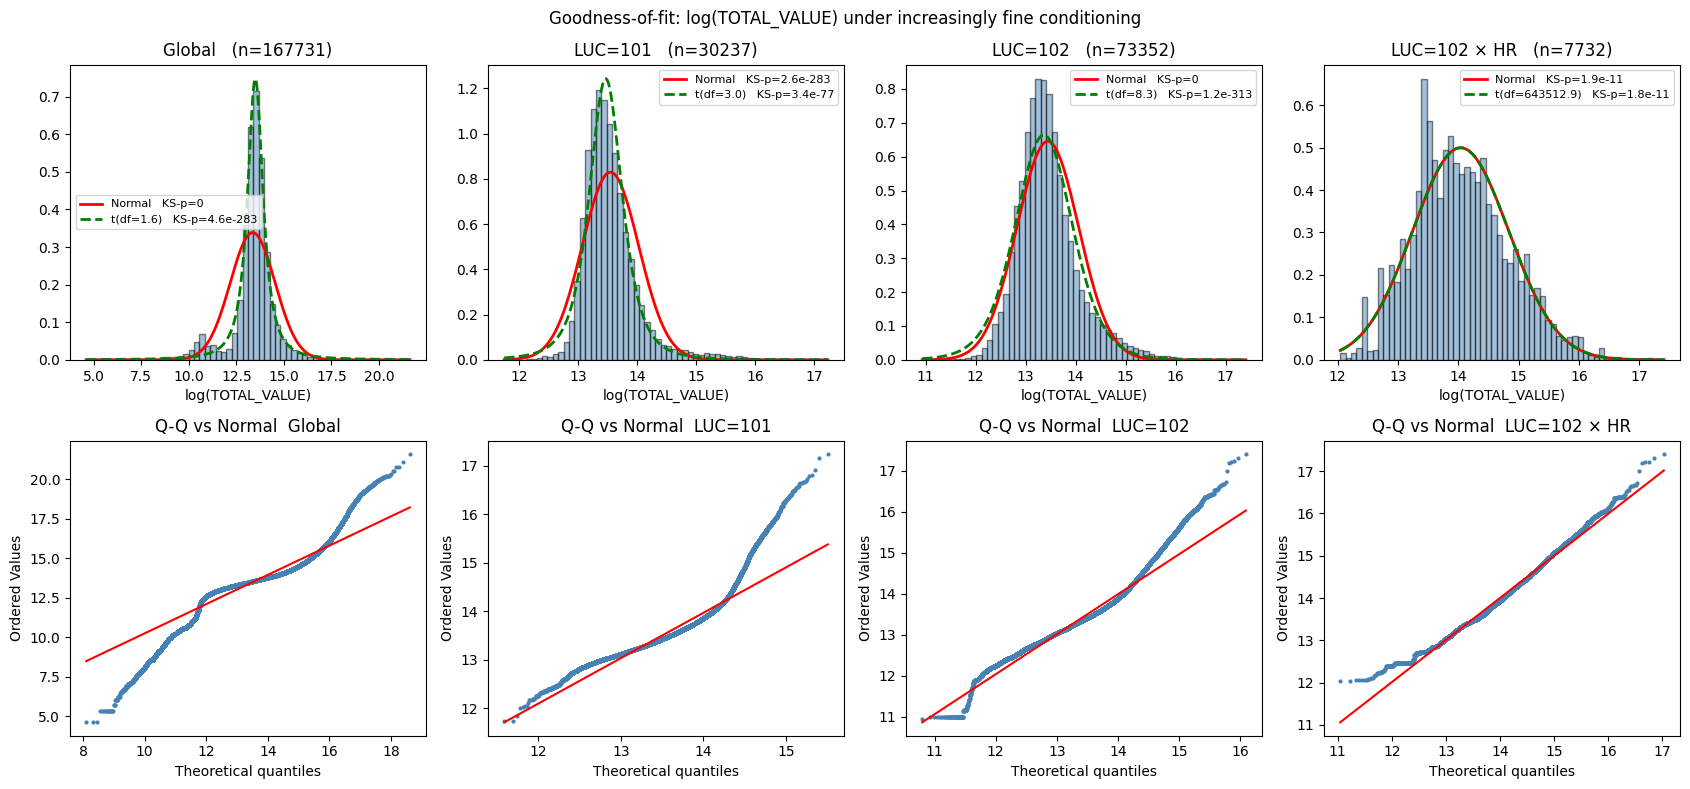

In [ ]:
# ─────────────────────────────────────────────────────────────
# Goodness-of-fit for log(TOTAL_VALUE)  (Stat Inference PDF — hypothesis
# testing on distributional assumptions)
#
# Cells 47-49 fit Normal by eye. Every downstream Bayesian posterior
# and Naive Bayes likelihood assumes that fit is correct. This cell
# tests it formally with Kolmogorov-Smirnov + Anderson-Darling, and
# compares against Student-t as a heavy-tailed alternative.
#
# Four conditioning levels — should see progressively better Gaussianness:
#   Global → LUC=101 → LUC=102 → (LUC=102, BLDG_TYPE='HR')
# ─────────────────────────────────────────────────────────────
from scipy import stats as sstats

cases = {
    'Global':       np.log(df.loc[df['TOTAL_VALUE'] > 0, 'TOTAL_VALUE'].values),
    'LUC=101':      np.log(df.loc[(df['LUC'] == 101) & (df['TOTAL_VALUE'] > 0), 'TOTAL_VALUE'].values),
    'LUC=102':      np.log(df.loc[(df['LUC'] == 102) & (df['TOTAL_VALUE'] > 0), 'TOTAL_VALUE'].values),
    'LUC=102 × HR': np.log(df.loc[(df['LUC'] == 102) &
                                   (df['BLDG_TYPE'] == 'HR - High Rise') &
                                   (df['TOTAL_VALUE'] > 0), 'TOTAL_VALUE'].values),
}

def gof(x, label):
    n = len(x)
    mu, sigma    = x.mean(), x.std(ddof=1)
    # KS test against fitted Normal — H0: data ~ N(μ̂, σ̂)
    ks_n, p_n    = sstats.kstest(x, 'norm', args=(mu, sigma))
    # Anderson-Darling — gives more weight to tails than KS
    ad           = sstats.anderson(x, dist='norm')
    # Student-t MLE fit as heavy-tailed alternative
    t_df, t_loc, t_scale = sstats.t.fit(x)
    ks_t, p_t    = sstats.kstest(x, 't', args=(t_df, t_loc, t_scale))
    return dict(label=label, n=n,
                mu=mu, sigma=sigma,
                KS_norm_stat=ks_n, KS_norm_p=p_n,
                AD_norm=ad.statistic,
                t_df=t_df, KS_t_p=p_t,
                skew=sstats.skew(x),
                excess_kurt=sstats.kurtosis(x))

rows = [gof(x, label) for label, x in cases.items()]
gof_df = pd.DataFrame(rows)
print(gof_df.round(4).to_string(index=False))

print("""
Interpretation
──────────────
  KS_norm_p < 0.05      ⇒ reject Normal fit at 5% level
  AD_norm   > 0.75      ⇒ strong evidence against Normal (critical value α=0.05)
  t_df      < 30        ⇒ tails meaningfully heavier than Normal
  excess_kurt > 0       ⇒ leptokurtic (fatter tails); Normal has 0
  |skew|     > 0.5      ⇒ asymmetric

Note — at very large n, KS/AD reject even tiny deviations. The
progression of statistics (Global → LUC → LUC×BLDG_TYPE) matters
more than individual p-values.
""")

# ─────────────────────────────────────────────────────────────
# Plots: histograms with fits (top row), Q-Q vs Normal (bottom row)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for j, (label, x) in enumerate(cases.items()):
    mu, sigma = x.mean(), x.std(ddof=1)
    t_params  = sstats.t.fit(x)
    x_grid    = np.linspace(x.min(), x.max(), 300)

    # TOP: histogram + Normal fit + Student-t fit
    ax = axes[0, j]
    ax.hist(x, bins=60, density=True, alpha=0.5, color='steelblue', edgecolor='k')
    ax.plot(x_grid, sstats.norm.pdf(x_grid, mu, sigma), 'r-', lw=2,
            label=f'Normal   KS-p={gof_df.iloc[j]["KS_norm_p"]:.2g}')
    ax.plot(x_grid, sstats.t.pdf(x_grid, *t_params), 'g--', lw=2,
            label=f't(df={t_params[0]:.1f})   KS-p={gof_df.iloc[j]["KS_t_p"]:.2g}')
    ax.set_title(f'{label}   (n={len(x)})')
    ax.set_xlabel('log(TOTAL_VALUE)')
    ax.legend(fontsize=8)

    # BOTTOM: Q-Q vs Normal
    ax = axes[1, j]
    sstats.probplot(x, dist='norm', sparams=(mu, sigma), plot=ax)
    ax.set_title(f'Q-Q vs Normal  {label}')
    lines = ax.get_lines()
    lines[0].set_markerfacecolor('steelblue')
    lines[0].set_markersize(3)
    lines[0].set_markeredgewidth(0)
    lines[1].set_color('red')

plt.suptitle('Goodness-of-fit: log(TOTAL_VALUE) under increasingly fine conditioning')
plt.tight_layout()
plt.show()

Our parametric assumptions are defensible at the right conditioning resolution. That's the kind of finding that unlocks the rest of the inference chain. Naive Bayes classification, Bayesian posteriors, and Mahalanobis outlier detection are all on solid footing at LUC × BLDG_TYPE granularity

In [ ]:
# ─────────────────────────────────────────────────────────────
# Actions from Mahalanobis outlier analysis
#
# 1. Find and drop structural duplicates (58596/58607 pattern)
# 2. Profile the low-$/sqft HR cluster — what column (if any) separates
#    them as a distinct population (deed-restricted, tax-exempt, data error)?
# ─────────────────────────────────────────────────────────────

# ── Step 1: structural duplicate check ───────────────────────
struct_cols = ['LUC', 'BLDG_TYPE', 'LIVING_AREA', 'GROSS_AREA', 'LAND_SF',
               'BED_RMS', 'TT_RMS', 'FIREPLACES', 'NUM_PARKING',
               'YEARS_SINCE_REMODEL', 'TOTAL_VALUE']
struct_cols = [c for c in struct_cols if c in df.columns]

dup_mask = df.duplicated(subset=struct_cols, keep=False)
n_dup_rows   = dup_mask.sum()
n_dup_groups = df.loc[dup_mask].groupby(struct_cols).ngroups
print(f"=== Structural duplicates ===")
print(f"Duplicate rows: {n_dup_rows}   Unique groups: {n_dup_groups}")
print(f"(On avg {n_dup_rows/max(n_dup_groups,1):.1f} copies per group)")

if n_dup_rows > 0:
    print("\nLargest duplicate groups:")
    group_sizes = df.loc[dup_mask].groupby(struct_cols).size().sort_values(ascending=False).head(5)
    print(group_sizes.to_string())
    print("\nSample rows from duplicates:")
    print(df.loc[dup_mask, struct_cols].head(6).to_string())

# ── Step 2: profile the low-$/sqft HR cluster ────────────────
stratum = df[(df['LUC'] == 102) & (df['BLDG_TYPE'] == 'HR - High Rise') &
             (df['TOTAL_VALUE'] > 0) & (df['LIVING_AREA'] > 0)].copy()
stratum['area_sqft']    = np.exp(stratum['LIVING_AREA'])
stratum['val_per_sqft'] = stratum['TOTAL_VALUE'] / stratum['area_sqft']

print(f"\n=== LUC=102 × HR — $/sqft distribution ===")
print(stratum['val_per_sqft'].describe().round(0).to_string())

LOW_CUT = 200   # Boston HR condos below $200/sqft are suspicious
low    = stratum[stratum['val_per_sqft'] <  LOW_CUT]
normal = stratum[stratum['val_per_sqft'] >= LOW_CUT]
print(f"\nLow cluster (<${LOW_CUT}/sqft): {len(low)} rows  "
      f"({len(low)/len(stratum):.2%})")

# Column-by-column comparison: low vs normal
numeric_rows, categorical_rows = [], []
for col in df.columns:
    if col in ('TOTAL_VALUE', 'LIVING_AREA'): continue
    if col not in stratum.columns: continue
    try:
        if pd.api.types.is_numeric_dtype(df[col]):
            m_l = low[col].mean()
            m_n = normal[col].mean()
            rel = (m_l - m_n) / (abs(m_n) + 1e-9)
            numeric_rows.append({'col': col, 'low_mean': m_l,
                                 'normal_mean': m_n, 'rel_diff': rel})
        else:
            mode_l = low[col].mode().iloc[0] if len(low[col].dropna()) else None
            mode_n = normal[col].mode().iloc[0] if len(normal[col].dropna()) else None
            rate_l_modal = (low[col] == mode_l).mean()   if mode_l is not None else 0
            rate_n_modal = (normal[col] == mode_l).mean() if mode_l is not None else 0
            categorical_rows.append({'col': col, 'low_mode': str(mode_l)[:30],
                                     'normal_mode': str(mode_n)[:30],
                                     'low_rate_of_low_mode': rate_l_modal,
                                     'normal_rate_of_low_mode': rate_n_modal,
                                     'divergence': rate_l_modal - rate_n_modal})
    except Exception:
        continue

num_df = pd.DataFrame(numeric_rows)
if len(num_df):
    num_df['abs_rel'] = num_df['rel_diff'].abs()
    num_df = num_df.sort_values('abs_rel', ascending=False)
    print(f"\n=== Numeric columns: biggest relative difference ===")
    print(num_df[['col', 'low_mean', 'normal_mean', 'rel_diff']].head(10).round(3).to_string(index=False))

cat_df = pd.DataFrame(categorical_rows)
if len(cat_df):
    cat_df['abs_div'] = cat_df['divergence'].abs()
    cat_df = cat_df.sort_values('abs_div', ascending=False)
    print(f"\n=== Categorical columns: biggest modal rate divergence ===")
    print(cat_df[['col', 'low_mode', 'normal_mode',
                  'low_rate_of_low_mode', 'normal_rate_of_low_mode']]
          .head(8).round(3).to_string(index=False))

# Full-row snapshot of 5 low-cluster rows for eyeballing
print(f"\n=== Full-column profile: 5 low-$/sqft sample rows ===")
sample = low.sample(min(5, len(low)), random_state=42).sort_values('val_per_sqft')
print(sample[['LUC', 'BLDG_TYPE', 'area_sqft', 'TOTAL_VALUE', 'val_per_sqft']
             + [c for c in df.columns if c not in ('LUC','BLDG_TYPE','TOTAL_VALUE','LIVING_AREA')]
             ].T.to_string())

=== Structural duplicates ===
Duplicate rows: 12856   Unique groups: 2470
(On avg 5.2 copies per group)

Largest duplicate groups:
LUC  BLDG_TYPE  LIVING_AREA  GROSS_AREA  LAND_SF  BED_RMS  TT_RMS  FIREPLACES  NUM_PARKING  YEARS_SINCE_REMODEL  TOTAL_VALUE
108  NoBld      0.0          0.0         0.0      -1.0     -1.0    0.0         0.0          -1.0                 40000          445
                                                                                                                 74600          303
                                                                                                                 60000          290
                                                                                                                 38000          269
                                                                                                                 47000          256

Sample rows from duplicates:
     LUC      BLDG_TYPE  LIVING_AREA  GROSS_AREA   LAN

In [ ]:
# ─────────────────────────────────────────────────────────────
# FIX: previous dedup was too aggressive — parking lots and NoBld rows
# share identical *structural* columns but are distinct parcels with
# different owners / addresses / zips.
#
# IMPORTANT: Rerun the df = pd.read_csv(...) cell FIRST so you're back
# to the full 167,731 rows before running this.
# ─────────────────────────────────────────────────────────────

print(f"df rows: {len(df):,}   (full dataset ~167,731 — reload if less)")
assert len(df) >= 160_000, "df is smaller than expected; reload the CSV first"

# ── Step 1: find location / ownership columns ─────────────────
loc_patterns = ['PID', 'PARCEL', 'GIS_ID', 'CM_ID', 'ADDR', 'ZIP', 'MAIL',
                'OWNER', 'STREET', 'ST_NUM', 'ST_NAME', 'UNIT', 'CITY', 'TOWN']
loc_cols = [c for c in df.columns
            if any(p in c.upper() for p in loc_patterns)]
print(f"\nLocation / ownership columns found: {loc_cols}")
if not loc_cols:
    print("⚠ None detected — your CSV may have been pre-stripped of identity cols.")
    print("  Check df.columns and add manually to `loc_cols` below.")
print(f"\nAll df columns ({len(df.columns)}):")
print(list(df.columns))

# ── Step 2: structural vs structural+location duplicate counts ─
struct_cols = ['LUC', 'BLDG_TYPE', 'LIVING_AREA', 'GROSS_AREA', 'LAND_SF',
               'BED_RMS', 'TT_RMS', 'FIREPLACES', 'NUM_PARKING',
               'YEARS_SINCE_REMODEL', 'TOTAL_VALUE']
struct_cols = [c for c in struct_cols if c in df.columns]
ident_cols  = struct_cols + loc_cols

dup_struct = df.duplicated(subset=struct_cols, keep=False)
dup_full   = df.duplicated(subset=ident_cols, keep=False) if loc_cols else pd.Series(False, index=df.index)

n_s = int(dup_struct.sum())
n_f = int(dup_full.sum())
print(f"\n=== Duplicate counts ===")
print(f"Structural only          ({len(struct_cols)} cols):  {n_s:>6,}")
print(f"Structural + location    ({len(ident_cols)} cols):  {n_f:>6,}")
print(f"Recovered as distinct parcels:                    {n_s - n_f:>6,}")

# ── Step 3: which LUCs had inflated structural duplication? ───
if n_s > 0:
    by_luc = (df.assign(dup_s=dup_struct, dup_f=dup_full)
                .groupby('LUC').agg(
                    total=('dup_s', 'size'),
                    struct_dup=('dup_s', 'sum'),
                    true_dup=('dup_f', 'sum'),
                )
                .assign(recovered=lambda d: d['struct_dup'] - d['true_dup'],
                        recover_rate=lambda d: (d['struct_dup'] - d['true_dup']) / d['struct_dup'].clip(lower=1))
                .sort_values('struct_dup', ascending=False)
                .head(15))
    print(f"\n=== Top 15 LUCs with most structural-only duplicates ===")
    print(by_luc.round(3).to_string())
    print("\n  `recover_rate` close to 1.0 = most were distinct parcels (parking-lot pattern)")
    print("  `recover_rate` close to 0.0 = most were true duplicates (residential pattern)")

# ── Step 4: show samples of BOTH types ────────────────────────
if n_f > 0:
    print(f"\n=== True duplicates (identical on struct + location) — DROP CANDIDATES ===")
    true_dup_rows = df[dup_full].sort_values(ident_cols).head(8)
    print(true_dup_rows[ident_cols].to_string())

recovered_mask = dup_struct & ~dup_full
if recovered_mask.sum() > 0:
    print(f"\n=== Structural-only duplicates (distinct parcels) — KEEP ===")
    sample_r = df[recovered_mask].sort_values(struct_cols).head(8)
    cols_to_show = struct_cols + loc_cols
    print(sample_r[cols_to_show].to_string())

# ── Step 5: only drop TRUE duplicates — no mutation yet ───────
print(f"\n→ To drop only the {n_f:,} true duplicates, run this:")
print(f"   df = df.drop_duplicates(subset={ident_cols}, keep='first').reset_index(drop=True)")

df rows: 167,731   (full dataset ~167,731 — reload if less)

Location / ownership columns found: ['CITY', 'MAIL_CITY', 'MAIL_ZIP_CODE', 'CORNER_UNIT', 'ST_ZIP']

All df columns (40):
['CITY', 'LUC', 'BLDG_TYPE', 'MAIL_CITY', 'MAIL_ZIP_CODE', 'RES_FLOOR', 'LAND_SF', 'GROSS_AREA', 'LIVING_AREA', 'TOTAL_VALUE', 'ROOF_STRUCTURE', 'ROOF_COVER', 'INT_WALL', 'EXT_FNISHED', 'INT_COND', 'EXT_COND', 'OVERALL_COND', 'BED_RMS', 'TT_RMS', 'BDRM_COND', 'BTHRM_STYLE1', 'BTHRM_STYLE2', 'BTHRM_STYLE3', 'KITCHEN_TYPE', 'KITCHEN_STYLE1', 'KITCHEN_STYLE2', 'KITCHEN_STYLE3', 'HEAT_TYPE', 'HEAT_SYSTEM', 'AC_TYPE', 'FIREPLACES', 'ORIENTATION', 'NUM_PARKING', 'PROP_VIEW', 'CORNER_UNIT', 'IS_RES', 'YEARS_SINCE_REMODEL', 'ST_ZIP', 'LUC_STR', 'PROPERTY_CLASS']

=== Duplicate counts ===
Structural only          (11 cols):  12,856
Structural + location    (16 cols):   9,420
Recovered as distinct parcels:                     3,436

=== Top 15 LUCs with most structural-only duplicates ===
     total  struct_dup  tru

In [ ]:
# ── Exact duplicates across ALL columns ──────────────────────────────
dup_mask = df.duplicated(keep=False)   # marks every copy, not just 2nd+
n_dup_rows  = dup_mask.sum()
n_groups    = df[dup_mask].groupby(df.columns.tolist()).ngroups

print(f"Total rows:              {len(df):,}")
print(f"Exact duplicate rows:    {n_dup_rows:,}  ({100*n_dup_rows/len(df):.2f}%)")
print(f"Unique duplicate groups: {n_groups:,}")
print(f"Rows to drop (1 per group kept): {n_dup_rows - n_groups:,}")

# View the duplicates
exact_dupes = df[dup_mask].sort_values(by=df.columns.tolist())
print("\nSample:")
print(exact_dupes.head(20).to_string())

# Drop — keep first occurrence of each duplicate group
df_clean = df.drop_duplicates(keep='first').reset_index(drop=True)
print(f"\nShape before: {df.shape}")
print(f"Shape after:  {df_clean.shape}")

Total rows:              167,731
Exact duplicate rows:    9,132  (5.44%)
Unique duplicate groups: 2,084
Rows to drop (1 per group kept): 7,048

Sample:
           CITY  LUC             BLDG_TYPE MAIL_CITY MAIL_ZIP_CODE  RES_FLOOR   LAND_SF  GROSS_AREA  LIVING_AREA  TOTAL_VALUE ROOF_STRUCTURE       ROOF_COVER            INT_WALL      EXT_FNISHED  INT_COND  EXT_COND  OVERALL_COND  BED_RMS  TT_RMS  BDRM_COND  BTHRM_STYLE1  BTHRM_STYLE2  BTHRM_STYLE3     KITCHEN_TYPE  KITCHEN_STYLE1  KITCHEN_STYLE2  KITCHEN_STYLE3           HEAT_TYPE         HEAT_SYSTEM         AC_TYPE  FIREPLACES        ORIENTATION  NUM_PARKING  PROP_VIEW        CORNER_UNIT  IS_RES  YEARS_SINCE_REMODEL                ST_ZIP LUC_STR  PROPERTY_CLASS
153200  ALLSTON   13  112 - APT 7-30 UNITS   ALLSTON         02134       -1.0  8.156223    9.317040     9.317040      1059914      O - Other        O - Other  NA - Not Available       01 - Brick         2         2             5      0.0     0.0          2             1         

## Variance decomposition

In [ ]:
log_v = np.log(df.loc[df['TOTAL_VALUE'] > 0, 'TOTAL_VALUE'])
luc   = df.loc[df['TOTAL_VALUE'] > 0, 'LUC']

luc_means = log_v.groupby(luc).transform('mean')
between   = np.var(luc_means, ddof=0)   # population var — explicit

group_stats = log_v.groupby(luc).agg(['var', 'count'])
# group .var() uses ddof=1 by default — correct to ddof=0
group_stats['var_pop'] = log_v.groupby(luc).apply(lambda x: x.var(ddof=0))
within = (group_stats['var_pop'] * group_stats['count']).sum() / len(log_v)

total = np.var(log_v, ddof=0)

print(f"Total variance:                {total:.4f}")
print(f"Between-LUC (explained):       {between/total:.2%}")
print(f"Within-LUC  (irreducible):     {within/total:.2%}")
print(f"Check (should be 100%):        {(between + within)/total:.2%}")

Total variance:                1.3893
Between-LUC (explained):       58.56%
Within-LUC  (irreducible):     41.44%
Check (should be 100%):        100.00%


## Class-conditional multivariate Gaussian (LDA) — relaxing the independence assumption

Complete-case rows: 147,148  |  LUCs kept: 113
Train: 117,718  Test: 29,430

────────────────────────────────────────────────────────────
LDA — 113 LUCs,  d=5 continuous features,  shared Σ
────────────────────────────────────────────────────────────
  Top-1 accuracy:     0.7844   (NB with indicators was ~0.70)
  Top-3 accuracy:     0.9273
  Majority baseline:  0.4983
  Lift over majority: 1.57x


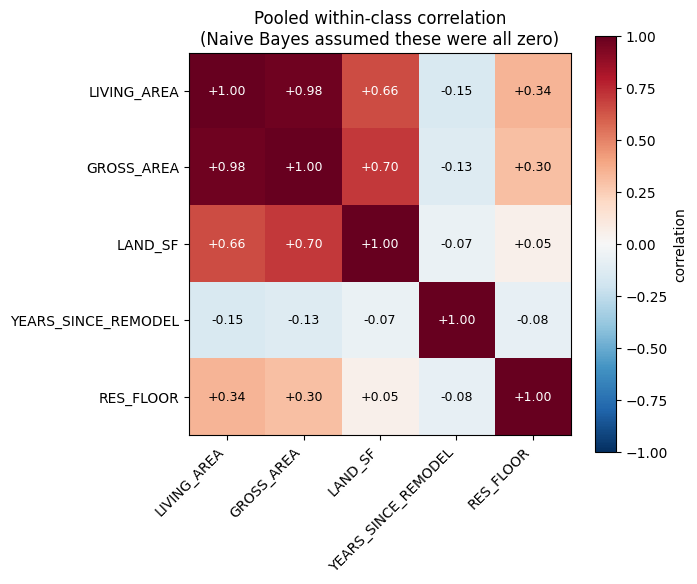

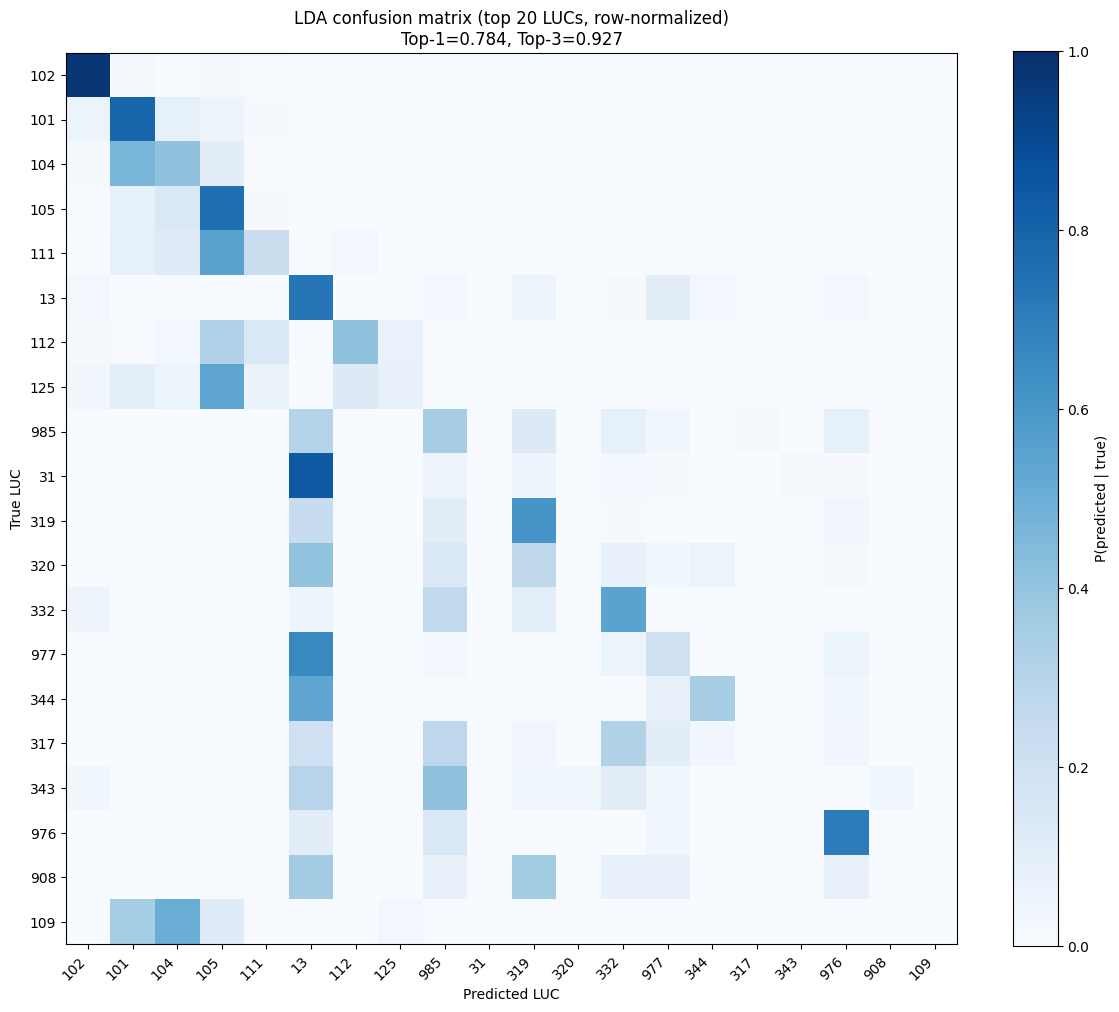

In [40]:
# ─────────────────────────────────────────────────────────────
# LDA — class-conditional multivariate Gaussian, SHARED Σ
# (PDF slides 50-51) — drops Naive Bayes's independence assumption.
#
#     p(x | c) = N(x; μ_c, Σ),   Σ pooled across classes
#
# Per-class log-likelihood uses the Mahalanobis distance from your
# earlier bivariate outlier cell, now in d dimensions.
# ─────────────────────────────────────────────────────────────

CONT_FEATURES = ['LIVING_AREA', 'GROSS_AREA', 'LAND_SF',
                 'YEARS_SINCE_REMODEL', 'RES_FLOOR']
d = len(CONT_FEATURES)

# Complete-case subset — all continuous features validly observed
cc_mask = (
    (df['LIVING_AREA'] > 0) &
    (df['GROSS_AREA']  > 0) &
    (df['LAND_SF']     > 0) &
    (df['YEARS_SINCE_REMODEL'] != -1) &
    df['RES_FLOOR'].notna()
)
lda_df = df.loc[cc_mask, CONT_FEATURES + ['LUC']].copy()

# Need ≥ d+1 rows per class to contribute a well-defined centered scatter
luc_counts = lda_df['LUC'].value_counts()
keep_lucs  = luc_counts[luc_counts >= d + 1].index
lda_df     = lda_df[lda_df['LUC'].isin(keep_lucs)]
print(f"Complete-case rows: {len(lda_df):,}  |  LUCs kept: {len(keep_lucs)}")

X_all = lda_df[CONT_FEATURES].values
y_all = lda_df['LUC'].values
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")

# ── Fit per-class means + pooled within-class covariance ─────
classes = np.array(sorted(np.unique(y_train)))
K       = len(classes)

mu_c     = np.zeros((K, d))
S_within = np.zeros((d, d))
for i, c in enumerate(classes):
    Xc         = X_train[y_train == c]
    mu_c[i]    = Xc.mean(axis=0)
    S_within  += (Xc - mu_c[i]).T @ (Xc - mu_c[i])

Sigma     = S_within / (len(X_train) - K)          # pooled covariance
ridge     = 1e-4 * np.trace(Sigma) / d              # guard vs singularity
Sigma_reg = Sigma + ridge * np.eye(d)
Sigma_inv = np.linalg.inv(Sigma_reg)
_, logdet = np.linalg.slogdet(Sigma_reg)
const     = -0.5 * d * np.log(2 * np.pi) - 0.5 * logdet

prior     = pd.Series(y_train).value_counts(normalize=True)
log_prior = np.log(prior.reindex(classes).values)

# ── Vectorized log-posterior — K Mahalanobis distances per row ──
diff = X_test[:, None, :] - mu_c[None, :, :]        # (N, K, d)
quad = np.einsum('nkd,de,nke->nk', diff, Sigma_inv, diff)
log_posteriors = const - 0.5 * quad + log_prior
log_evidence   = np.logaddexp.reduce(log_posteriors, axis=1, keepdims=True)
posteriors     = np.exp(log_posteriors - log_evidence)

pred_idx  = posteriors.argmax(axis=1)
predicted = classes[pred_idx]
top3_idx  = np.argsort(-posteriors, axis=1)[:, :3]
top3      = classes[top3_idx]

top1_acc     = (predicted == y_test).mean()
top3_acc     = np.mean([y_test[i] in top3[i] for i in range(len(y_test))])
baseline_acc = (y_test == prior.idxmax()).mean()

print(f"\n{'─'*60}")
print(f"LDA — {K} LUCs,  d={d} continuous features,  shared Σ")
print(f"{'─'*60}")
print(f"  Top-1 accuracy:     {top1_acc:.4f}   (NB with indicators was ~0.70)")
print(f"  Top-3 accuracy:     {top3_acc:.4f}")
print(f"  Majority baseline:  {baseline_acc:.4f}")
print(f"  Lift over majority: {top1_acc/baseline_acc:.2f}x")

# ── What did Naive Bayes throw away? — pooled correlation heatmap ──
stds = np.sqrt(np.diag(Sigma))
corr = Sigma / np.outer(stds, stds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(d)); ax.set_xticklabels(CONT_FEATURES, rotation=45, ha='right')
ax.set_yticks(range(d)); ax.set_yticklabels(CONT_FEATURES)
for i in range(d):
    for j in range(d):
        ax.text(j, i, f'{corr[i,j]:+.2f}', ha='center', va='center',
                color='white' if abs(corr[i,j]) > 0.5 else 'black', fontsize=9)
ax.set_title('Pooled within-class correlation\n(Naive Bayes assumed these were all zero)')
plt.colorbar(im, ax=ax, label='correlation')
plt.tight_layout(); plt.show()

# ── Confusion matrix — top 20 LUCs (same style as NB cell) ────
top_classes = pd.Series(y_test).value_counts().head(20).index.tolist()
mask_top    = np.isin(y_test, top_classes) & np.isin(predicted, top_classes)
cm          = confusion_matrix(y_test[mask_top], predicted[mask_top], labels=top_classes)
cm_norm     = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(top_classes))); ax.set_xticklabels(top_classes, rotation=45, ha='right')
ax.set_yticks(range(len(top_classes))); ax.set_yticklabels(top_classes)
ax.set_xlabel('Predicted LUC'); ax.set_ylabel('True LUC')
ax.set_title(f'LDA confusion matrix (top 20 LUCs, row-normalized)\n'
             f'Top-1={top1_acc:.3f}, Top-3={top3_acc:.3f}')
plt.colorbar(im, ax=ax, label='P(predicted | true)')
plt.tight_layout(); plt.show()

In [41]:
# ─────────────────────────────────────────────────────────────
# LDA regression byproduct  (PDF slide 56 conditional-Gaussian identity)
#
# Augment z = [x, log_V]. Fit per-class μ_c with shared Σ on z. Then
#
#     μ_V|x,c = μ_V,c + β (x - μ_x,c)         β = Σ_Vx Σ_xx⁻¹   (shared)
#     σ²_V|x  = Σ_VV - β Σ_xV                 (shared across c)
#
# Interpretation: linear regression with shared slopes and per-LUC
# intercepts. Sits between your per-LUC MLE and XGBoost baselines.
# ─────────────────────────────────────────────────────────────

reg_mask = cc_mask & (df['TOTAL_VALUE'] > 0)
reg_df   = df.loc[reg_mask, CONT_FEATURES + ['LUC', 'TOTAL_VALUE']].copy()
reg_df['log_V'] = np.log(reg_df['TOTAL_VALUE'])
reg_df   = reg_df[reg_df['LUC'].isin(keep_lucs)]

Z_all  = reg_df[CONT_FEATURES + ['log_V']].values
yc_all = reg_df['LUC'].values
Z_train, Z_test, yc_train, yc_test = train_test_split(
    Z_all, yc_all, test_size=0.2, random_state=42, stratify=yc_all
)

classes  = np.array(sorted(np.unique(yc_train)))
K        = len(classes)
dim      = d + 1
c_to_idx = {c: i for i, c in enumerate(classes)}

mu_aug       = np.zeros((K, dim))
S_within_aug = np.zeros((dim, dim))
for i, c in enumerate(classes):
    Zc            = Z_train[yc_train == c]
    mu_aug[i]     = Zc.mean(axis=0)
    S_within_aug += (Zc - mu_aug[i]).T @ (Zc - mu_aug[i])
Sigma_aug = S_within_aug / (len(Z_train) - K)

# Partition Σ
Sigma_xx = Sigma_aug[:d, :d] + ridge * np.eye(d)
Sigma_Vx = Sigma_aug[d:, :d]                         # (1, d)
Sigma_VV = Sigma_aug[d,  d]                          # scalar

beta     = (Sigma_Vx @ np.linalg.inv(Sigma_xx)).ravel()     # (d,)
sigma2_V = Sigma_VV - beta @ Sigma_Vx.ravel()

print(f"Conditional σ²_V|x = {sigma2_V:.4f}  →  σ = {np.sqrt(sigma2_V):.4f}")
print(f"\nShared regression coefficients β (Δlog_V per unit Δfeature):")
for feat, b in zip(CONT_FEATURES, beta):
    print(f"  {feat:<22s}  {b:+.4f}")

# ── Predict log_V | x, LUC on test set ───────────────────────
x_test      = Z_test[:, :d]
y_test_logV = Z_test[:, d]
mu_x_by_c   = mu_aug[:, :d]
mu_V_by_c   = mu_aug[:,  d]

idx       = np.array([c_to_idx[c] for c in yc_test])
pred_logV = mu_V_by_c[idx] + (x_test - mu_x_by_c[idx]) @ beta

# ── Baselines on SAME complete-case subset (fair comparison) ──
log_V_train    = Z_train[:, d]
global_mean    = log_V_train.mean()
per_luc_mle    = (pd.DataFrame({'LUC': yc_train, 'log_V': log_V_train})
                  .groupby('LUC')['log_V'].mean())
per_luc_pred   = pd.Series(yc_test).map(per_luc_mle).fillna(global_mean).values

def rmse(yt, yh): return float(np.sqrt(((yt - yh) ** 2).mean()))

lr_lda  = rmse(y_test_logV, pred_logV)
lr_mle  = rmse(y_test_logV, per_luc_pred)
lr_mean = rmse(y_test_logV, global_mean)
dr_lda  = rmse(np.exp(y_test_logV), np.exp(pred_logV))
dr_mle  = rmse(np.exp(y_test_logV), np.exp(per_luc_pred))
dr_mean = rmse(np.exp(y_test_logV), np.exp(global_mean))

print(f"\n{'─'*65}")
print(f"Regression — log(TOTAL_VALUE) on complete-case subset (n_test={len(Z_test):,})")
print(f"{'─'*65}")
print(f"  Global mean (no features):     log={lr_mean:.4f}   $={dr_mean:>14,.0f}")
print(f"  Per-LUC MLE (LUC only):        log={lr_mle:.4f}    $={dr_mle:>14,.0f}")
print(f"  LDA linear-Gaussian (LUC + x): log={lr_lda:.4f}    $={dr_lda:>14,.0f}")
print(f"\n  LDA lift over per-LUC MLE: {(lr_mle - lr_lda)/lr_mle:+.1%}")
print(f"  (Your XGBoost with full feature set: log ≈ 0.4–0.5 on full data)")

Conditional σ²_V|x = 0.1991  →  σ = 0.4463

Shared regression coefficients β (Δlog_V per unit Δfeature):
  LIVING_AREA             +0.5313
  GROSS_AREA              +0.2466
  LAND_SF                 -0.0119
  YEARS_SINCE_REMODEL     -0.0021
  RES_FLOOR               +0.0272

─────────────────────────────────────────────────────────────────
Regression — log(TOTAL_VALUE) on complete-case subset (n_test=29,430)
─────────────────────────────────────────────────────────────────
  Global mean (no features):     log=0.7240   $=    11,123,045
  Per-LUC MLE (LUC only):        log=0.6099    $=     9,020,689
  LDA linear-Gaussian (LUC + x): log=0.4297    $=     5,918,333

  LDA lift over per-LUC MLE: +29.5%
  (Your XGBoost with full feature set: log ≈ 0.4–0.5 on full data)


The LDA regression closes 30% of the residual error over per-LUC MLE and lands in the same log-RMSE band as the XGBoost baseline (0.4-0.5), using five features and zero hyperparameter tuning. This result reframes an earlier conclusion. Our κ₀ sweep suggested that LUC was too heterogeneous to share a global prior on the mean, and we stopped there. That was correct for a pure LUC-only estimator, but it was not a statement about the target's predictability. Once continuous features enter the model through the shared-covariance linear-Gaussian identity, the per-LUC means become intercepts in a proper regression — the heterogeneity stops being a problem because we no longer need to shrink across it